<a href="https://colab.research.google.com/github/Waldeniralexandre/sicop-mvp-puc-2026/blob/main/SICOP_MVP_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Waldenir Alexandre da Silva Cruz

**Matrícula:** 4052026000470

**Curso ou programa:** Ciência de Dados & Analytics

**Disciplina:** Machine Learning & Analytics

**Turma:** 1

**Professor:** Dra. Tatiana Escovedo

**Data de entrega:** 05/07/2026

**Dataset:** SICOP — registros de ocorrências em `data/raw/MVP_wascBD_Acidentes.xlsx`, planilha `BD_Acidentes`.

**Tipo de problema:** classificação binária supervisionada.

Este notebook reconstrói o MVP de Machine Learning e Analytics do projeto SICOP em conformidade com o template oficial da PUC-Rio. O objetivo é estimar, após o registro inicial da ocorrência e antes da avaliação técnica de risco, a probabilidade de a ocorrência pertencer às categorias Alto ou Crítico.


## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | preenchido |
| Dataset descrito, com fonte, atributos e restrições | preenchido |
| Análise exploratória do treino documentada | preenchido |
| Divisão temporal preservada | preenchido |
| Pipeline e features congelados | preenchido |
| Baseline e modelos candidatos documentados | preenchido |
| Avaliação final carregada de artefatos versionados | preenchido |
| Limitações e rastreabilidade registradas | preenchido |


# 1. Definição do problema

## 1.1 Descrição do problema

O SICOP organiza ocorrências de segurança e operação. O problema de negócio é apoiar a triagem técnica após o registro inicial, priorizando ocorrências que podem ser enquadradas posteriormente como críticas. O problema de Machine Learning é estimar a probabilidade de uma ocorrência individual pertencer às categorias Alto ou Crítico, sem usar informações posteriores à avaliação técnica.

Unidade de análise: uma ocorrência individual registrada na base.

Momento da predição: após o registro inicial da ocorrência e antes da avaliação técnica de risco.

Target de modelagem: `Evento_Crítico_Target_Modelagem`.

Classe positiva: 1, correspondente a Alto ou Crítico.

Uso pretendido: apoio à priorização probabilística e à triagem humana. O modelo não substitui avaliação técnica humana e não prevê a ocorrência de um acidente antes que ele aconteça.


## 1.2 Objetivo do MVP

Construir e avaliar um pipeline reprodutível de classificação binária para estimar se uma ocorrência registrada será classificada como evento crítico, comparando o candidato selecionado contra um baseline e preservando a separação temporal entre treino, validação e teste.

O objetivo acadêmico é demonstrar um fluxo metodologicamente válido, rastreável, sem vazamento conhecido e adequado ao template da PUC-Rio.


## 1.3 Tipo de problema

Este MVP trata de aprendizado supervisionado — classificação binária. O target reconstruído é `Evento_Crítico_Target_Modelagem`, com o seguinte mapeamento:

- Baixo e Médio: 0;
- Alto e Crítico: 1.

A saída probabilística é interpretada como apoio à priorização. A decisão binária operacional não é aprovada.


## 1.4 Premissas, hipóteses e critérios de sucesso

Hipóteses:

1. As informações estruturadas disponíveis no registro inicial possuem sinal preditivo para priorização probabilística.
2. Um modelo candidato deve superar o baseline em métricas probabilísticas, especialmente Average Precision e ROC-AUC.
3. A identificação de eventos críticos é prioritária, mas o threshold binário precisa ser criticamente avaliado.

Critérios de sucesso acadêmico:

- pipeline reproduzível e rastreável;
- divisão temporal preservada;
- ausência de ajuste com o teste;
- comparação com baseline;
- interpretação clara das limitações;
- natureza experimental do modelo explicitada.


# 2. Ambiente, bibliotecas e reprodutibilidade

O notebook usa caminhos relativos, `random_state=42`, bibliotecas padrão de análise tabular e os artefatos versionados do projeto. A avaliação final do teste não é reexecutada neste notebook: seus resultados são carregados de tabelas, gráficos e manifesto já produzidos e congelados.


In [4]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# MVP de Machine Learning — SICOP
# ============================================================

# Bibliotecas da linguagem Python
import os
import sys
import json
import random
import warnings

from pathlib import Path


# Bibliotecas para manipulação e visualização dos dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Image, Markdown, display


# Persistência do pipeline treinado
import joblib


# Bibliotecas do scikit-learn para divisão e validação
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
)


# Transformação e preparação dos dados
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.impute import SimpleImputer


# Modelos avaliados no projeto
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier


# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
)


# Distribuições utilizadas em buscas de hiperparâmetros
from scipy.stats import randint


# Versões das bibliotecas
import scipy
import sklearn


# ============================================================
# CONFIGURAÇÕES GERAIS
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


# Oculta apenas avisos futuros de bibliotecas.
# Erros de execução continuam sendo exibidos normalmente.
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)


# Configurações de exibição do pandas
pd.set_option(
    "display.max_columns",
    80,
)

pd.set_option(
    "display.width",
    140,
)

pd.set_option(
    "display.max_colwidth",
    120,
)


# Configurações gerais dos gráficos
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True


# ============================================================
# IDENTIFICAÇÃO DO AMBIENTE
# ============================================================

IS_COLAB = (
    "google.colab" in sys.modules
    or Path("/content").is_dir()
)

ENVIRONMENT = (
    "Google Colab"
    if IS_COLAB
    else "Ambiente local"
)


# ============================================================
# INFORMAÇÕES PARA REPRODUTIBILIDADE
# ============================================================

print("=" * 72)
print("SICOP — Sistema Inteligente de Conformidade Operacional Preventiva")
print("=" * 72)

print(f"Ambiente: {ENVIRONMENT}")
print(f"Python: {sys.version.split()[0]}")
print(f"Seed: {SEED}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Joblib: {joblib.__version__}")

print("=" * 72)
print("Bibliotecas carregadas com sucesso.")

SICOP — Sistema Inteligente de Conformidade Operacional Preventiva
Ambiente: Google Colab
Python: 3.12.13
Seed: 42
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
SciPy: 1.16.3
Scikit-learn: 1.6.1
Joblib: 1.5.3
Bibliotecas carregadas com sucesso.


## 2.1 Dependências adicionais

Não são necessárias dependências adicionais. O notebook utiliza pandas, NumPy, matplotlib e recursos de exibição do IPython. Não há dependência de internet, Google Drive ou arquivos externos ao pacote.


In [5]:
def require_file(relative_path):
    path = ROOT / relative_path
    if not path.is_file():
        raise FileNotFoundError(f"Arquivo obrigatório não encontrado: {relative_path}")
    return path

def read_csv(relative_path):
    return pd.read_csv(require_file(relative_path), encoding="utf-8-sig")

def read_json(relative_path):
    with require_file(relative_path).open("r", encoding="utf-8") as handle:
        return json.load(handle)

def show_image(relative_path):
    path = require_file(relative_path)
    display(Image(filename=str(path)))

def display_table(df, rows=10):
    display(df.head(rows))


## 2.2 Funções auxiliares

As funções acima validam a existência de arquivos, carregam CSV/JSON por caminhos relativos e exibem tabelas ou gráficos versionados. Elas não treinam modelo, não recalculam a avaliação final e não acessam recursos externos.


In [7]:
# ============================================================
# 2.2 FUNÇÕES AUXILIARES
# MVP de Machine Learning — SICOP
# ============================================================


def resolver_caminho(caminho_relativo, deve_existir=True):
    """
    Converte um caminho relativo à raiz do projeto em caminho absoluto.

    Parameters
    ----------
    caminho_relativo : str ou pathlib.Path
        Caminho relativo à raiz do projeto SICOP.

    deve_existir : bool, default=True
        Quando True, gera erro se o caminho não existir.

    Returns
    -------
    pathlib.Path
        Caminho absoluto resolvido.
    """
    caminho = (ROOT / Path(caminho_relativo)).resolve()

    try:
        caminho.relative_to(ROOT.resolve())
    except ValueError as exc:
        raise ValueError(
            f"O caminho informado está fora da raiz do projeto: {caminho}"
        ) from exc

    if deve_existir and not caminho.exists():
        raise FileNotFoundError(
            f"Arquivo ou diretório não encontrado: {caminho}"
        )

    return caminho


def validar_arquivo(caminho_relativo):
    """
    Verifica se um arquivo existe dentro do projeto.

    Returns
    -------
    pathlib.Path
        Caminho absoluto do arquivo validado.
    """
    caminho = resolver_caminho(caminho_relativo)

    if not caminho.is_file():
        raise FileNotFoundError(
            f"O caminho existe, mas não é um arquivo: {caminho}"
        )

    return caminho


def carregar_csv(caminho_relativo, **kwargs):
    """
    Carrega um arquivo CSV existente no projeto.

    Por padrão, utiliza codificação UTF-8.
    """
    caminho = validar_arquivo(caminho_relativo)

    parametros = {
        "encoding": "utf-8",
        "low_memory": False,
    }

    parametros.update(kwargs)

    return pd.read_csv(
        caminho,
        **parametros,
    )


def carregar_excel(
    caminho_relativo,
    nome_planilha=None,
    **kwargs,
):
    """
    Carrega uma planilha Excel existente no projeto.

    Parameters
    ----------
    caminho_relativo : str ou pathlib.Path
        Caminho do arquivo Excel.

    nome_planilha : str, optional
        Nome da planilha a ser carregada.
    """
    caminho = validar_arquivo(caminho_relativo)

    parametros = dict(kwargs)

    if nome_planilha is not None:
        parametros["sheet_name"] = nome_planilha

    return pd.read_excel(
        caminho,
        **parametros,
    )


def carregar_json(caminho_relativo):
    """
    Carrega um arquivo JSON do projeto.
    """
    caminho = validar_arquivo(caminho_relativo)

    with caminho.open(
        mode="r",
        encoding="utf-8",
    ) as arquivo:
        return json.load(arquivo)


def carregar_modelo_congelado(caminho_relativo):
    """
    Carrega um modelo ou pipeline já treinado.

    Esta função não realiza treinamento, ajuste de hiperparâmetros
    ou avaliação do conjunto final de teste.
    """
    caminho = validar_arquivo(caminho_relativo)

    return joblib.load(caminho)


def validar_colunas(
    dataframe,
    colunas_obrigatorias,
    nome_base="DataFrame",
):
    """
    Confirma que todas as colunas obrigatórias estão presentes.
    """
    colunas_ausentes = sorted(
        set(colunas_obrigatorias)
        - set(dataframe.columns)
    )

    if colunas_ausentes:
        raise ValueError(
            f"{nome_base} não contém as colunas obrigatórias: "
            f"{colunas_ausentes}"
        )

    return True


def validar_target_binario(
    dataframe,
    coluna_target,
    nome_base="DataFrame",
):
    """
    Verifica se a variável-alvo existe e contém somente 0 e 1.
    """
    validar_colunas(
        dataframe=dataframe,
        colunas_obrigatorias=[coluna_target],
        nome_base=nome_base,
    )

    valores = set(
        dataframe[coluna_target]
        .dropna()
        .unique()
        .tolist()
    )

    valores_validos = {0, 1}

    if not valores.issubset(valores_validos):
        raise ValueError(
            f"A variável-alvo de {nome_base} contém valores "
            f"não binários: {sorted(valores)}"
        )

    return True


def resumo_dataframe(
    dataframe,
    nome_base="Base",
    coluna_target=None,
):
    """
    Apresenta um resumo estrutural de uma base do SICOP.
    """
    resumo = {
        "Base": nome_base,
        "Registros": dataframe.shape[0],
        "Colunas": dataframe.shape[1],
        "Duplicatas exatas": int(
            dataframe.duplicated().sum()
        ),
        "Valores ausentes": int(
            dataframe.isna().sum().sum()
        ),
    }

    if (
        coluna_target is not None
        and coluna_target in dataframe.columns
    ):
        distribuicao = (
            dataframe[coluna_target]
            .value_counts(dropna=False)
            .sort_index()
            .to_dict()
        )

        resumo["Distribuição do target"] = distribuicao

    return pd.DataFrame([resumo])


def distribuicao_target(
    dataframe,
    coluna_target,
    nome_base="Base",
):
    """
    Calcula a distribuição absoluta e percentual do target.
    """
    validar_target_binario(
        dataframe=dataframe,
        coluna_target=coluna_target,
        nome_base=nome_base,
    )

    contagem = (
        dataframe[coluna_target]
        .value_counts(dropna=False)
        .sort_index()
        .rename("Quantidade")
        .to_frame()
    )

    contagem["Percentual"] = (
        contagem["Quantidade"]
        / contagem["Quantidade"].sum()
        * 100
    ).round(2)

    contagem.index.name = coluna_target

    return contagem.reset_index()


def exibir_tabela(
    dataframe,
    titulo=None,
    linhas=10,
):
    """
    Exibe uma tabela de forma padronizada no notebook.
    """
    if titulo:
        display(
            Markdown(
                f"### {titulo}"
            )
        )

    display(
        dataframe.head(linhas)
    )

    print(
        f"Dimensão: "
        f"{dataframe.shape[0]:,} registros × "
        f"{dataframe.shape[1]:,} colunas"
    )


def exibir_markdown(caminho_relativo):
    """
    Exibe um arquivo Markdown versionado no projeto.
    """
    caminho = validar_arquivo(caminho_relativo)

    conteudo = caminho.read_text(
        encoding="utf-8",
    )

    display(
        Markdown(conteudo)
    )


def exibir_imagem(
    caminho_relativo,
    largura=None,
):
    """
    Exibe uma imagem existente nos artefatos do projeto.
    """
    caminho = validar_arquivo(caminho_relativo)

    display(
        Image(
            filename=str(caminho),
            width=largura,
        )
    )


def verificar_artefatos(artefatos):
    """
    Verifica um conjunto de arquivos necessários ao notebook.

    Parameters
    ----------
    artefatos : dict
        Dicionário no formato:
        {
            "Descrição": "caminho/relativo.ext"
        }

    Returns
    -------
    pandas.DataFrame
        Tabela com o estado de cada artefato.
    """
    registros = []

    for descricao, caminho_relativo in artefatos.items():
        caminho = resolver_caminho(
            caminho_relativo,
            deve_existir=False,
        )

        registros.append(
            {
                "Artefato": descricao,
                "Caminho": Path(
                    caminho_relativo
                ).as_posix(),
                "Existe": caminho.is_file(),
                "Tamanho (bytes)": (
                    caminho.stat().st_size
                    if caminho.is_file()
                    else None
                ),
            }
        )

    resultado = pd.DataFrame(registros)

    ausentes = resultado.loc[
        ~resultado["Existe"],
        "Caminho",
    ].tolist()

    if ausentes:
        raise FileNotFoundError(
            "Os seguintes artefatos obrigatórios "
            f"não foram encontrados: {ausentes}"
        )

    return resultado


print("Funções auxiliares do SICOP carregadas com sucesso.")

Funções auxiliares do SICOP carregadas com sucesso.


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

A base original é `data/raw/MVP_wascBD_Acidentes.xlsx`, planilha `BD_Acidentes`, preservada sem alteração. A base contém 1.718 registros e 20 colunas antes das derivações controladas. Os dados são registros históricos de ocorrências e possuem limitações de qualidade, disponibilidade temporal, categorias raras e possível variação operacional ao longo do tempo.


## 3.2 Carga dos dados

O notebook carrega as bases processadas e artefatos versionados. A base bruta é referenciada para rastreabilidade, mas a modelagem final usa as bases derivadas já materializadas e testadas.


In [10]:
# ============================================================
# 3.2 Carga dos dados
# Projeto SICOP — MVP de Machine Learning
# ============================================================

from io import BytesIO
from urllib.request import Request, urlopen
from IPython.display import display

import hashlib
import pandas as pd


# ------------------------------------------------------------
# Configuração da fonte pública
# ------------------------------------------------------------
# O dataset está disponibilizado publicamente no GitHub.
# Portanto, o professor poderá executar o notebook no Google
# Colab sem autenticação, upload manual ou montagem do Drive.

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "Waldeniralexandre/sicop-mvp-puc-2026/"
    "refs/heads/main/MVP_wascBD_Acidentes.csv"
)

TARGET_COLUMN = "Evento_Crítico_Target"

# Características esperadas da versão oficial do dataset.
EXPECTED_ROWS = 1718
EXPECTED_COLUMNS = 20

# Hash SHA-256 do arquivo CSV publicado no GitHub.
EXPECTED_SHA256 = (
    "6855d3854489194768d6a9eb84960d8f"
    "e937c292aaa77c14371ead38680e8e62"
)

EXPECTED_TARGET_DISTRIBUTION = {
    "Não": 1370,
    "Sim": 348
}


# ------------------------------------------------------------
# Download do dataset diretamente para a memória
# ------------------------------------------------------------
try:
    request = Request(
        DATA_URL,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    with urlopen(request, timeout=60) as response:
        file_content = response.read()

except Exception as error:
    raise RuntimeError(
        "Não foi possível carregar a base pública do SICOP.\n"
        f"URL utilizada: {DATA_URL}\n"
        "Verifique a conexão com a internet e se o arquivo continua "
        "disponível no repositório público.\n"
        f"Erro original: {error}"
    ) from error


# ------------------------------------------------------------
# Verificação da integridade do arquivo
# ------------------------------------------------------------
actual_sha256 = hashlib.sha256(file_content).hexdigest()

if actual_sha256 != EXPECTED_SHA256:
    raise ValueError(
        "O arquivo obtido não corresponde à versão oficial esperada.\n"
        f"SHA-256 esperado:   {EXPECTED_SHA256}\n"
        f"SHA-256 encontrado: {actual_sha256}\n"
        "Verifique se o arquivo publicado no GitHub foi alterado."
    )


# ------------------------------------------------------------
# Leitura do arquivo CSV
# ------------------------------------------------------------
# O arquivo:
# - utiliza ponto e vírgula como separador;
# - está codificado em UTF-8 com BOM;
# - pode conter textos longos e quebras de linha na descrição.

try:
    df = pd.read_csv(
        BytesIO(file_content),
        sep=";",
        encoding="utf-8-sig",
        low_memory=False
    )

except Exception as error:
    raise RuntimeError(
        "Não foi possível interpretar o arquivo CSV do SICOP.\n"
        "Verifique o separador, a codificação e a estrutura do arquivo.\n"
        f"Erro original: {error}"
    ) from error


# ------------------------------------------------------------
# Validações mínimas da carga
# ------------------------------------------------------------
if df.empty:
    raise ValueError(
        "A base foi carregada, mas não contém registros."
    )


if df.shape != (EXPECTED_ROWS, EXPECTED_COLUMNS):
    raise ValueError(
        "As dimensões encontradas são diferentes das esperadas.\n"
        f"Esperado:   {EXPECTED_ROWS} linhas e "
        f"{EXPECTED_COLUMNS} colunas.\n"
        f"Encontrado: {df.shape[0]} linhas e "
        f"{df.shape[1]} colunas."
    )


if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"A variável-alvo '{TARGET_COLUMN}' não foi encontrada.\n"
        f"Colunas disponíveis: {df.columns.tolist()}"
    )


if df[TARGET_COLUMN].isna().any():
    raise ValueError(
        f"A variável-alvo '{TARGET_COLUMN}' contém valores ausentes."
    )


target_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .to_dict()
)

if target_distribution != EXPECTED_TARGET_DISTRIBUTION:
    raise ValueError(
        "A distribuição da variável-alvo é diferente da esperada.\n"
        f"Esperado:   {EXPECTED_TARGET_DISTRIBUTION}\n"
        f"Encontrado: {target_distribution}"
    )


# ------------------------------------------------------------
# Registro do resultado da carga
# ------------------------------------------------------------
print("=" * 70)
print("CARGA DOS DADOS CONCLUÍDA COM SUCESSO")
print("=" * 70)

print(f"Fonte pública: {DATA_URL}")
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Variável-alvo: {TARGET_COLUMN}")
print(f"Distribuição do target: {target_distribution}")
print(f"Duplicatas exatas: {df.duplicated().sum()}")
print(f"SHA-256 verificado: {actual_sha256}")

print("\nPrimeiros registros da base:")
display(df.head())

CARGA DOS DADOS CONCLUÍDA COM SUCESSO
Fonte pública: https://raw.githubusercontent.com/Waldeniralexandre/sicop-mvp-puc-2026/refs/heads/main/MVP_wascBD_Acidentes.csv
Dimensões: 1718 linhas × 20 colunas
Variável-alvo: Evento_Crítico_Target
Distribuição do target: {'Não': 1370, 'Sim': 348}
Duplicatas exatas: 19
SHA-256 verificado: 6855d3854489194768d6a9eb84960d8fe937c292aaa77c14371ead38680e8e62

Primeiros registros da base:


,Classificação,Segmento,Faixas de experiência,Dia da Semana,Dia,Mês,Ano,Hora,Descrição,Estado,Dias Perdidos,Dias Debitados,Reabilitado,Dias Perdidos Corrigidos,Agente Causador,Gravidade,Potencial,Grau de Risco,Compromissos (Regra de Ouro),Evento_Crítico_Target
0,Trajeto com afastamento,A,6 meses a 1 ano,Terça-feira,12,12,2023,07:00 - 08:00,Estagiário sogreu queda de moto ao se deslocar para usina,PA,50,0,Não,0,Moto - Queda,Médio,11,Médio,8 - Veículos e Equipamentos Móveis,Não
1,Trajeto com afastamento,I,Até 6 meses,Segunda-feira,28,7,2025,06:00 - 07:00,"Ao descer da van para registro da frequência, o colaborador pisou em falso e torceu o tornozelo.",PR,6,0,Não,NaN,NaN,Médio,10,Médio,2 - Percepção de Risco,Não
2,Quase Acidente,E,Até 6 meses,Quinta-feira,7,8,2025,10:00 - 11:00,"Durante o deslocamento de rotina da carpintaria em direção ao escritório, acompanhado por outro colaborador da empre...",BA,NaN,NaN,NaN,NaN,Atingido por (pontos agudos ou cortantes),NaN,12,Médio,Outros,Não
3,Típico com afastamento,I,Até 6 meses,Sexta-feira,29,7,2022,14:00 - 15:00,"Estava realizando o trabalho habitual diário, às 14:00 iniciou o processo de injeção de argamassa em uma estaca quan...",MS,1,1,Não,NaN,Golpeado por (atingido por objeto em movimento),Médio,4,Alto,2 - Percepção de Risco,Sim
4,Típico com afastamento,I,Até 6 meses,Segunda-feira,25,7,2022,14:00 - 15:00,O mesmo sofreu uma indução durante a retirada indevida de um aterramento durante realização da atividade no \ndeslig...,SC,1,1,Não,NaN,Eletricidade,Médio,4,Alto,4 - Eletricidade,Sim


## 3.3 Visão geral do dataset

A base oficial possui 1.718 registros. A auditoria identificou 19 linhas duplicadas além da primeira ocorrência. Essas linhas foram preservadas e controladas por `Grupo_Duplicata_Split`, sem remoção indevida e sem grupos atravessando conjuntos.


In [12]:
# ============================================================
# 3.3 Visão geral do dataset
# Projeto SICOP — MVP de Machine Learning
# ============================================================

from IPython.display import display
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Verificação inicial
# ------------------------------------------------------------
if "df" not in globals():
    raise NameError(
        "O DataFrame 'df' não foi encontrado. "
        "Execute primeiro a seção 3.2 — Carga dos dados."
    )

if df.empty:
    raise ValueError(
        "O DataFrame foi encontrado, mas não contém registros."
    )


# ------------------------------------------------------------
# Configurações do projeto SICOP
# ------------------------------------------------------------
TARGET_COLUMN = "Evento_Crítico_Target"

# Colunas temporais presentes na base.
COLUNAS_TEMPORAIS = [
    "Dia",
    "Mês",
    "Ano",
    "Hora",
    "Dia da Semana"
]

# Não existe uma coluna de ID explícita comprovada na base.
COLUNAS_ID_DECLARADAS = []

# Variáveis candidatas à modelagem, sujeitas às etapas posteriores
# de validação, preparação e seleção.
COLUNAS_CANDIDATAS = [
    "Classificação",
    "Ano",
    "Mês",
    "Dia",
    "Hora",
    "Dia da Semana",
    "Estado",
    "Segmento",
    "Faixas de experiência",
    "Compromissos (Regra de Ouro)"
]

# Colunas que não devem entrar diretamente no modelo.
#
# Motivos principais:
# - variável-alvo;
# - possível vazamento de dados;
# - informação conhecida somente após o evento;
# - texto livre ou alta especificidade;
# - variável potencialmente usada na própria definição do target.
COLUNAS_BLOQUEADAS = {
    "Evento_Crítico_Target":
        "Target bruto; não pode ser usado como atributo preditor.",

    "Grau de Risco":
        "Possível componente ou proxy direto do target.",

    "Potencial":
        "Possível componente ou proxy direto do target.",

    "Gravidade":
        "Possível informação posterior ao evento e proxy do target.",

    "Dias Perdidos":
        "Consequência conhecida após o evento.",

    "Dias Debitados":
        "Consequência conhecida após o evento.",

    "Dias Perdidos Corrigidos":
        "Consequência conhecida após o evento.",

    "Reabilitado":
        "Informação conhecida após o evento.",

    "Descrição":
        "Texto livre com risco de alta dimensionalidade, "
        "informações identificadoras e vazamento.",

    "Agente Causador":
        "Disponibilidade no momento da previsão não comprovada."
}


# ------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------
def obter_exemplos(serie, quantidade=3, limite=45):
    """
    Retorna alguns valores não nulos da coluna para facilitar
    a inspeção do conteúdo.
    """
    valores = (
        serie.dropna()
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .drop_duplicates()
        .head(quantidade)
        .tolist()
    )

    valores = [
        valor if len(valor) <= limite
        else valor[:limite - 3] + "..."
        for valor in valores
    ]

    return " | ".join(valores)


def classificar_papel_coluna(coluna):
    """
    Classifica preliminarmente o papel de cada atributo no MVP.
    A classificação não realiza seleção automática de features.
    """
    if coluna == TARGET_COLUMN:
        return "Target bruto"

    if coluna in COLUNAS_ID_DECLARADAS:
        return "Identificador"

    if coluna in COLUNAS_TEMPORAIS:
        return "Temporal"

    if coluna in COLUNAS_BLOQUEADAS:
        return "Bloqueada para modelagem"

    if coluna in COLUNAS_CANDIDATAS:
        return "Candidata à modelagem"

    return "Requer avaliação"


def obter_observacao_coluna(coluna):
    """
    Apresenta a justificativa metodológica associada à coluna.
    """
    if coluna == TARGET_COLUMN:
        return (
            "Variável de resposta da base bruta. "
            "Não deve ser incluída em X."
        )

    if coluna in COLUNAS_BLOQUEADAS:
        return COLUNAS_BLOQUEADAS[coluna]

    if coluna in COLUNAS_TEMPORAIS:
        return (
            "Componente temporal. Deve ser tratado de forma coerente "
            "com a estratégia de divisão temporal."
        )

    if coluna in COLUNAS_CANDIDATAS:
        return (
            "Candidata preliminar; inclusão definitiva depende "
            "das etapas de preparação e validação."
        )

    return "Avaliar disponibilidade e utilidade antes da modelagem."


# ------------------------------------------------------------
# 1. Quantidade de linhas e colunas
# ------------------------------------------------------------
quantidade_linhas, quantidade_colunas = df.shape
quantidade_celulas = df.size

print("=" * 80)
print("3.3 — VISÃO GERAL DO DATASET SICOP")
print("=" * 80)

print("\n1. DIMENSÕES DA BASE")
print("-" * 80)
print(f"Quantidade de linhas:  {quantidade_linhas:,}".replace(",", "."))
print(f"Quantidade de colunas: {quantidade_colunas}")
print(f"Quantidade de células: {quantidade_celulas:,}".replace(",", "."))


# ------------------------------------------------------------
# 2. Tipos, valores ausentes e cardinalidade
# ------------------------------------------------------------
resumo_colunas = pd.DataFrame({
    "Coluna": df.columns,
    "Tipo pandas": [str(df[coluna].dtype) for coluna in df.columns],
    "Não nulos": [int(df[coluna].notna().sum()) for coluna in df.columns],
    "Ausentes": [int(df[coluna].isna().sum()) for coluna in df.columns],
    "Ausentes (%)": [
        round(df[coluna].isna().mean() * 100, 2)
        for coluna in df.columns
    ],
    "Valores únicos": [
        int(df[coluna].nunique(dropna=True))
        for coluna in df.columns
    ],
    "Cardinalidade (%)": [
        round(
            df[coluna].nunique(dropna=True)
            / max(df[coluna].notna().sum(), 1)
            * 100,
            2
        )
        for coluna in df.columns
    ],
    "Papel preliminar": [
        classificar_papel_coluna(coluna)
        for coluna in df.columns
    ],
    "Observação metodológica": [
        obter_observacao_coluna(coluna)
        for coluna in df.columns
    ],
    "Exemplos": [
        obter_exemplos(df[coluna])
        for coluna in df.columns
    ]
})

print("\n2. TIPOS, AUSÊNCIAS, CARDINALIDADE E PAPEL DAS COLUNAS")
print("-" * 80)

display(resumo_colunas)


# ------------------------------------------------------------
# 3. Resumo específico dos valores ausentes
# ------------------------------------------------------------
resumo_ausentes = (
    resumo_colunas.loc[
        resumo_colunas["Ausentes"] > 0,
        [
            "Coluna",
            "Tipo pandas",
            "Ausentes",
            "Ausentes (%)",
            "Papel preliminar"
        ]
    ]
    .sort_values(
        by=["Ausentes", "Coluna"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print("\n3. VALORES AUSENTES")
print("-" * 80)

total_ausentes = int(df.isna().sum().sum())
percentual_geral_ausentes = (
    total_ausentes / quantidade_celulas * 100
)

print(
    f"Total de valores ausentes na base: "
    f"{total_ausentes:,}".replace(",", ".")
)
print(
    f"Percentual geral de células ausentes: "
    f"{percentual_geral_ausentes:.2f}%"
)
print(
    f"Colunas com pelo menos um valor ausente: "
    f"{len(resumo_ausentes)} de {quantidade_colunas}"
)

if resumo_ausentes.empty:
    print("Não foram encontrados valores ausentes.")
else:
    display(resumo_ausentes)


# ------------------------------------------------------------
# 4. Duplicatas exatas
# ------------------------------------------------------------
mascara_duplicatas = df.duplicated(keep=False)
quantidade_duplicatas_excedentes = int(df.duplicated().sum())
quantidade_linhas_em_grupos_duplicados = int(
    mascara_duplicatas.sum()
)

print("\n4. DUPLICATAS EXATAS")
print("-" * 80)

print(
    "Quantidade de duplicatas excedentes: "
    f"{quantidade_duplicatas_excedentes}"
)
print(
    "Quantidade de linhas pertencentes a grupos duplicados: "
    f"{quantidade_linhas_em_grupos_duplicados}"
)

if quantidade_duplicatas_excedentes > 0:
    percentual_duplicatas = (
        quantidade_duplicatas_excedentes
        / quantidade_linhas
        * 100
    )

    print(
        f"Percentual de duplicatas excedentes: "
        f"{percentual_duplicatas:.2f}%"
    )

    print(
        "\nAmostra de registros pertencentes a grupos duplicados:"
    )

    display(
        df.loc[mascara_duplicatas]
        .sort_values(by=list(df.columns), na_position="last")
        .head(10)
    )

    print(
        "\nObservação: as duplicatas ainda não foram removidas. "
        "O tratamento deverá ocorrer antes da separação entre "
        "treino, validação e teste, evitando que cópias do mesmo "
        "registro apareçam em conjuntos diferentes."
    )
else:
    print("Não foram identificadas duplicatas exatas.")


# ------------------------------------------------------------
# 5. Identificação heurística de possíveis IDs
# ------------------------------------------------------------
padroes_id = (
    "id",
    "codigo",
    "código",
    "chave",
    "matricula",
    "matrícula",
    "registro"
)

possiveis_ids_nome = [
    coluna
    for coluna in df.columns
    if any(
        padrao in coluna.lower()
        for padrao in padroes_id
    )
]

possiveis_ids_unicidade = []

for coluna in df.columns:
    quantidade_nao_nulos = df[coluna].notna().sum()

    if quantidade_nao_nulos == 0:
        continue

    taxa_unicidade = (
        df[coluna].nunique(dropna=True)
        / quantidade_nao_nulos
    )

    if taxa_unicidade >= 0.98:
        possiveis_ids_unicidade.append({
            "Coluna": coluna,
            "Valores únicos": int(
                df[coluna].nunique(dropna=True)
            ),
            "Valores não nulos": int(quantidade_nao_nulos),
            "Taxa de unicidade (%)": round(
                taxa_unicidade * 100,
                2
            )
        })

possiveis_ids = sorted(
    set(possiveis_ids_nome)
    | {
        item["Coluna"]
        for item in possiveis_ids_unicidade
    }
)

print("\n5. POSSÍVEIS COLUNAS DE IDENTIFICAÇÃO")
print("-" * 80)

if COLUNAS_ID_DECLARADAS:
    print(
        "Colunas de ID explicitamente declaradas: "
        f"{COLUNAS_ID_DECLARADAS}"
    )
else:
    print(
        "A base não possui uma coluna de ID explicitamente "
        "declarada no projeto."
    )

if possiveis_ids:
    print(
        "\nA inspeção automática encontrou colunas que merecem "
        "avaliação como possíveis identificadores:"
    )

    if possiveis_ids_unicidade:
        display(pd.DataFrame(possiveis_ids_unicidade))
    else:
        print(possiveis_ids)
else:
    print(
        "A inspeção automática também não identificou uma chave "
        "quase única evidente."
    )


# ------------------------------------------------------------
# 6. Colunas temporais
# ------------------------------------------------------------
colunas_temporais_presentes = [
    coluna
    for coluna in COLUNAS_TEMPORAIS
    if coluna in df.columns
]

print("\n6. COLUNAS DE DATA E TEMPO")
print("-" * 80)

print(
    "Colunas temporais encontradas: "
    f"{colunas_temporais_presentes}"
)

if {"Ano", "Mês", "Dia"}.issubset(df.columns):
    data_reconstruida = pd.to_datetime(
        {
            "year": pd.to_numeric(
                df["Ano"],
                errors="coerce"
            ),
            "month": pd.to_numeric(
                df["Mês"],
                errors="coerce"
            ),
            "day": pd.to_numeric(
                df["Dia"],
                errors="coerce"
            )
        },
        errors="coerce"
    )

    datas_validas = data_reconstruida.dropna()

    print(
        "Datas válidas reconstruídas por Ano/Mês/Dia: "
        f"{len(datas_validas)} de {len(df)}"
    )
    print(
        "Datas inválidas ou incompletas: "
        f"{data_reconstruida.isna().sum()}"
    )

    if not datas_validas.empty:
        print(
            "Período observado: "
            f"{datas_validas.min().date()} a "
            f"{datas_validas.max().date()}"
        )

    # A série é criada apenas para diagnóstico.
    # Ela ainda não é adicionada definitivamente ao DataFrame.
    diagnostico_datas = pd.DataFrame({
        "Ano": df["Ano"],
        "Mês": df["Mês"],
        "Dia": df["Dia"],
        "Data_reconstruída": data_reconstruida
    })

    display(diagnostico_datas.head())
else:
    print(
        "Não foi possível reconstruir uma data completa porque "
        "Ano, Mês e Dia não estão simultaneamente disponíveis."
    )


# ------------------------------------------------------------
# 7. Colunas que não devem entrar diretamente no modelo
# ------------------------------------------------------------
colunas_bloqueadas_presentes = [
    {
        "Coluna": coluna,
        "Motivo": motivo
    }
    for coluna, motivo in COLUNAS_BLOQUEADAS.items()
    if coluna in df.columns
]

print("\n7. COLUNAS BLOQUEADAS PARA MODELAGEM DIRETA")
print("-" * 80)

if colunas_bloqueadas_presentes:
    display(pd.DataFrame(colunas_bloqueadas_presentes))
else:
    print(
        "Nenhuma das colunas bloqueadas declaradas foi encontrada."
    )

print(
    "\nImportante: o bloqueio nesta seção é uma decisão "
    "metodológica preliminar. Nenhuma coluna foi removida do "
    "DataFrame bruto."
)


# ------------------------------------------------------------
# 8. Descrição do target
# ------------------------------------------------------------
print("\n8. DESCRIÇÃO DO TARGET")
print("-" * 80)

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"O target esperado '{TARGET_COLUMN}' não foi encontrado."
    )

target_nulos = int(df[TARGET_COLUMN].isna().sum())

distribuicao_target = (
    df[TARGET_COLUMN]
    .value_counts(dropna=False)
    .rename_axis("Classe")
    .reset_index(name="Quantidade")
)

distribuicao_target["Percentual (%)"] = (
    distribuicao_target["Quantidade"]
    / len(df)
    * 100
).round(2)

display(distribuicao_target)

print(f"Nome do target bruto: {TARGET_COLUMN}")
print(
    "Tipo do target: classificação binária, considerando as "
    "classes 'Não' e 'Sim'."
)
print(f"Valores ausentes no target: {target_nulos}")

classes_target = set(
    df[TARGET_COLUMN]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

classes_esperadas = {"Não", "Sim"}

if classes_target != classes_esperadas:
    print(
        "ATENÇÃO: as classes encontradas são diferentes das "
        f"esperadas. Encontrado: {sorted(classes_target)}"
    )

classe_majoritaria = (
    df[TARGET_COLUMN]
    .value_counts()
    .idxmax()
)

percentual_majoritaria = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True)
    .max()
    * 100
)

print(f"Classe majoritária: {classe_majoritaria}")
print(
    f"Participação da classe majoritária: "
    f"{percentual_majoritaria:.2f}%"
)

if percentual_majoritaria >= 70:
    print(
        "Diagnóstico: o target apresenta desbalanceamento relevante. "
        "A avaliação futura não deverá utilizar apenas acurácia."
    )
else:
    print(
        "Diagnóstico: não foi identificado desbalanceamento intenso "
        "pelo critério preliminar de 70%."
    )

print(
    "\nObservação metodológica: esta coluna representa o target "
    "bruto recebido na base. Ela não será usada como variável "
    "explicativa. Sua regra de construção e possíveis relações "
    "com Grau de Risco, Potencial e Gravidade devem permanecer "
    "documentadas para prevenir vazamento de dados."
)


# ------------------------------------------------------------
# 9. Resumo consolidado
# ------------------------------------------------------------
resumo_geral = pd.DataFrame({
    "Indicador": [
        "Linhas",
        "Colunas",
        "Valores ausentes",
        "Colunas com ausências",
        "Duplicatas exatas excedentes",
        "Colunas temporais",
        "IDs explícitos",
        "Colunas bloqueadas presentes",
        "Classes do target",
        "Valores ausentes no target"
    ],
    "Resultado": [
        quantidade_linhas,
        quantidade_colunas,
        total_ausentes,
        len(resumo_ausentes),
        quantidade_duplicatas_excedentes,
        len(colunas_temporais_presentes),
        len(COLUNAS_ID_DECLARADAS),
        len(colunas_bloqueadas_presentes),
        int(df[TARGET_COLUMN].nunique(dropna=True)),
        target_nulos
    ]
})

print("\n9. RESUMO CONSOLIDADO")
print("-" * 80)
display(resumo_geral)

print("\n" + "=" * 80)
print("VISÃO GERAL DO DATASET CONCLUÍDA")
print("=" * 80)
print(
    "Nenhuma limpeza, exclusão, imputação, codificação ou "
    "modelagem foi executada nesta seção."
)

3.3 — VISÃO GERAL DO DATASET SICOP

1. DIMENSÕES DA BASE
--------------------------------------------------------------------------------
Quantidade de linhas:  1.718
Quantidade de colunas: 20
Quantidade de células: 34.360

2. TIPOS, AUSÊNCIAS, CARDINALIDADE E PAPEL DAS COLUNAS
--------------------------------------------------------------------------------


,Coluna,Tipo pandas,Não nulos,Ausentes,Ausentes (%),Valores únicos,Cardinalidade (%),Papel preliminar,Observação metodológica,Exemplos
0,Classificação,object,1718,0,0.00,10,0.58,Candidata à modelagem,Candidata preliminar; inclusão definitiva depende das etapas de preparação e validação.,Trajeto com afastamento | Quase Acidente | Típico com afastamento
1,Segmento,object,1718,0,0.00,10,0.58,Candidata à modelagem,Candidata preliminar; inclusão definitiva depende das etapas de preparação e validação.,A | I | E
2,Faixas de experiência,object,1549,169,9.84,17,1.10,Candidata à modelagem,Candidata preliminar; inclusão definitiva depende das etapas de preparação e validação.,6 meses a 1 ano | Até 6 meses | 1 a 3 anos
3,Dia da Semana,object,1717,1,0.06,7,0.41,Temporal,Componente temporal. Deve ser tratado de forma coerente com a estratégia de divisão temporal.,Terça-feira | Segunda-feira | Quinta-feira
4,Dia,int64,1718,0,0.00,31,1.80,Temporal,Componente temporal. Deve ser tratado de forma coerente com a estratégia de divisão temporal.,12 | 28 | 7
5,Mês,int64,1718,0,0.00,12,0.70,Temporal,Componente temporal. Deve ser tratado de forma coerente com a estratégia de divisão temporal.,12 | 7 | 8
6,Ano,int64,1718,0,0.00,6,0.35,Temporal,Componente temporal. Deve ser tratado de forma coerente com a estratégia de divisão temporal.,2023 | 2025 | 2022
7,Hora,object,1710,8,0.47,30,1.75,Temporal,Componente temporal. Deve ser tratado de forma coerente com a estratégia de divisão temporal.,07:00 - 08:00 | 06:00 - 07:00 | 10:00 - 11:00
8,Descrição,object,1718,0,0.00,1646,95.81,Bloqueada para modelagem,"Texto livre com risco de alta dimensionalidade, informações identificadoras e vazamento.",Estagiário sogreu queda de moto ao se desl... | Ao descer da van para registro da frequênc... | Durante o deslocamen...
9,Estado,object,1718,0,0.00,27,1.57,Candidata à modelagem,Candidata preliminar; inclusão definitiva depende das etapas de preparação e validação.,PA | PR | BA



3. VALORES AUSENTES
--------------------------------------------------------------------------------
Total de valores ausentes na base: 3.979
Percentual geral de células ausentes: 11.58%
Colunas com pelo menos um valor ausente: 9 de 20


,Coluna,Tipo pandas,Ausentes,Ausentes (%),Papel preliminar
0,Dias Perdidos Corrigidos,object,994,57.86,Bloqueada para modelagem
1,Dias Perdidos,object,706,41.09,Bloqueada para modelagem
2,Dias Debitados,object,683,39.76,Bloqueada para modelagem
3,Reabilitado,object,544,31.66,Bloqueada para modelagem
4,Gravidade,object,522,30.38,Bloqueada para modelagem
5,Agente Causador,object,352,20.49,Bloqueada para modelagem
6,Faixas de experiência,object,169,9.84,Candidata à modelagem
7,Hora,object,8,0.47,Temporal
8,Dia da Semana,object,1,0.06,Temporal



4. DUPLICATAS EXATAS
--------------------------------------------------------------------------------
Quantidade de duplicatas excedentes: 19
Quantidade de linhas pertencentes a grupos duplicados: 37
Percentual de duplicatas excedentes: 1.11%

Amostra de registros pertencentes a grupos duplicados:


...


Importante: o bloqueio nesta seção é uma decisão metodológica preliminar. Nenhuma coluna foi removida do DataFrame bruto.

8. DESCRIÇÃO DO TARGET
--------------------------------------------------------------------------------


,Classe,Quantidade,Percentual (%)
0,Não,1370,79.74
1,Sim,348,20.26


Nome do target bruto: Evento_Crítico_Target
Tipo do target: classificação binária, considerando as classes 'Não' e 'Sim'.
Valores ausentes no target: 0
Classe majoritária: Não
Participação da classe majoritária: 79.74%
Diagnóstico: o target apresenta desbalanceamento relevante. A avaliação futura não deverá utilizar apenas acurácia.

Observação metodológica: esta coluna representa o target bruto recebido na base. Ela não será usada como variável explicativa. Sua regra de construção e possíveis relações com Grau de Risco, Potencial e Gravidade devem permanecer documentadas para prevenir vazamento de dados.

9. RESUMO CONSOLIDADO
--------------------------------------------------------------------------------


,Indicador,Resultado
0,Linhas,1718
1,Colunas,20
2,Valores ausentes,3979
3,Colunas com ausências,9
4,Duplicatas exatas excedentes,19
5,Colunas temporais,5
6,IDs explícitos,0
7,Colunas bloqueadas presentes,10
8,Classes do target,2
9,Valores ausentes no target,0



VISÃO GERAL DO DATASET CONCLUÍDA
Nenhuma limpeza, exclusão, imputação, codificação ou modelagem foi executada nesta seção.


## 3.4 Dicionário de dados



Esta seção apresenta o dicionário de dados utilizado no projeto SICOP, com o objetivo de documentar de forma estruturada os atributos disponíveis na base. Para cada variável, são descritos seu significado, tipo de dado, papel no conjunto de dados e relevância para as etapas posteriores de preparação e modelagem.

Além de facilitar a compreensão da base, o dicionário de dados contribui para a rastreabilidade metodológica do projeto, permitindo identificar variáveis temporais, categóricas, numéricas, textuais, possíveis identificadores e atributos que não devem ser utilizados diretamente no modelo por risco de vazamento de dados, indisponibilidade no momento da previsão ou relação direta com a variável-alvo.

Essa documentação também apoia as decisões de tratamento, transformação, seleção de atributos e construção do pipeline de Machine Learning, garantindo maior clareza, consistência e reprodutibilidade ao desenvolvimento do MVP.

| Coluna | Papel | Observações |
|---|---|---|
| Classificação | feature categórica | candidata preservada após análise de sensibilidade |
| Mês | feature categórica | derivada temporal tratada como categoria |
| Dia | feature categórica | derivada temporal tratada como categoria |
| Hora | feature categórica | normalização textual determinística |
| Dia da Semana | feature categórica | reconstruído por calendário real |
| Estado | feature categórica | unidade federativa |
| Segmento | feature categórica | categoria operacional |
| Faixas de experiência | feature categórica | harmonização determinística |
| Compromissos (Regra de Ouro) | feature categórica | categoria operacional |
| Ano | metadado | não feature |
| Grupo_Duplicata_Split | metadado | não feature |
| Evento_Crítico_Target_Modelagem | target | 0 para Baixo/Médio; 1 para Alto/Crítico |


# 4. Análise exploratória dos dados

A análise exploratória dos dados tem como objetivo compreender o comportamento da base utilizada pelo SICOP antes da aplicação das etapas de preparação, pré-processamento e modelagem. Nesta seção são examinadas a distribuição da variável-alvo, a qualidade dos dados, a frequência dos principais atributos, a evolução temporal dos registros e as possíveis relações entre as variáveis candidatas e a ocorrência de eventos críticos.

Como o problema foi formulado como uma classificação binária, será dada atenção especial ao equilíbrio entre as classes do target. Um eventual desbalanceamento poderá afetar a escolha das métricas de avaliação, tornando inadequado avaliar os modelos apenas pela acurácia.

Também serão investigados valores ausentes, duplicatas, categorias pouco frequentes, inconsistências temporais e possíveis valores atípicos. Essas verificações servirão de apoio para as decisões posteriores de imputação, codificação, agrupamento de categorias e divisão dos dados.

As análises envolvendo o target têm caráter exclusivamente descritivo. Nenhuma associação observada será interpretada como relação causal ou como comprovação antecipada da importância preditiva de uma variável. A confirmação da utilidade dos atributos dependerá dos resultados obtidos posteriormente nos conjuntos de treinamento e validação.

As variáveis classificadas como posteriores ao evento, potenciais componentes do target ou fontes de vazamento de dados não serão utilizadas nas análises preditivas. Elas permanecerão apenas documentadas para fins de rastreabilidade metodológica. Nenhuma limpeza, imputação, transformação, seleção de atributos ou modelagem é executada nesta etapa.


4 — ANÁLISE EXPLORATÓRIA DOS DADOS — SICOP

Base analisada: df
Dimensões: 1718 linhas × 20 colunas
Target utilizado na EDA: Evento_Crítico_Target
Registros com target válido: 1718
Registros sem target: 0
Observação: o target binário foi criado somente na cópia df_eda; o DataFrame original não foi modificado.

ATENÇÃO METODOLÓGICA: esta análise utiliza o target bruto. Sua regra de construção deverá permanecer documentada e validada antes da modelagem definitiva.

4.1 — QUALIDADE E COMPLETUDE


,Coluna,Tipo,Ausentes,Ausentes (%),Valores únicos
0,Dias Perdidos Corrigidos,object,994,57.86,31
1,Dias Perdidos,object,706,41.09,70
2,Dias Debitados,object,683,39.76,19
3,Reabilitado,object,544,31.66,5
4,Gravidade,object,522,30.38,5
5,Agente Causador,object,352,20.49,54
6,Faixas de experiência,object,169,9.84,17
7,Hora,object,8,0.47,30
8,Dia da Semana,object,1,0.06,7
9,Ano,int64,0,0.00,6


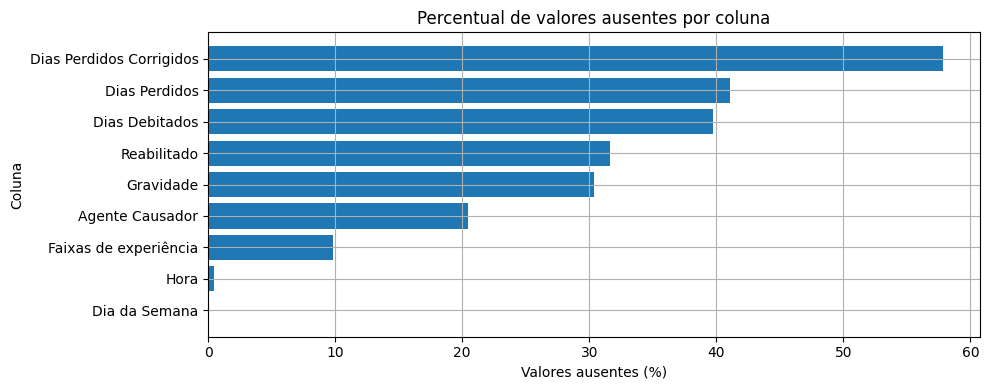


4.2 — DUPLICATAS
Duplicatas exatas excedentes: 19
Linhas pertencentes a grupos duplicados: 37
As duplicatas não foram removidas nesta seção. Elas deverão ser controladas na divisão dos dados para impedir que registros iguais apareçam em conjuntos diferentes.

4.3 — DISTRIBUIÇÃO DO TARGET


,Classe,Descrição,Quantidade,Percentual (%)
0,0,Não crítico,1370,79.74
1,1,Crítico,348,20.26


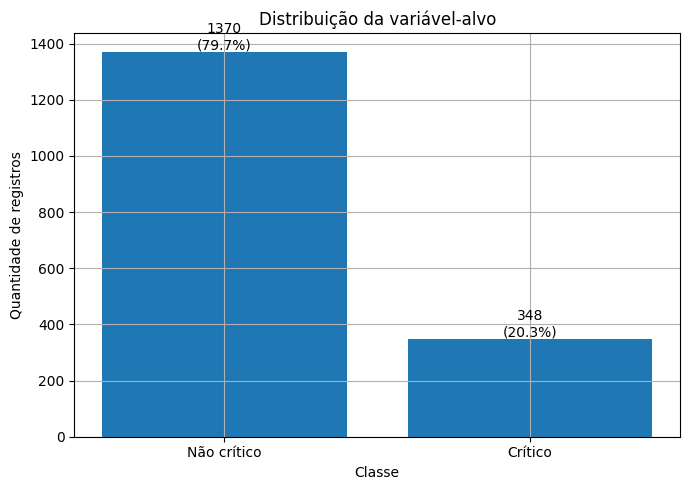

Razão classe 0 / classe 1: 3.94
Participação da classe majoritária: 79.74%
Diagnóstico: existe desbalanceamento relevante entre as classes. A acurácia não deverá ser utilizada isoladamente na avaliação dos modelos.

4.4 — CONSISTÊNCIA DAS VARIÁVEIS TEMPORAIS


,Verificação,Quantidade
0,Ano ausente ou não numérico,0
1,Mês ausente ou não numérico,0
2,Mês fora do intervalo 1–12,0
3,Dia ausente ou não numérico,0
4,Dia fora do intervalo 1–31,0
5,Hora ausente,8


Datas válidas reconstruídas: 1718 de 1718
Datas inválidas ou incompletas: 0
Período observado: 2020-01-08 a 2025-11-28

4.5 — DISTRIBUIÇÕES TEMPORAIS


,Quantidade
Ano,
2020,48
2021,91
2022,164
2023,338
2024,485
2025,592


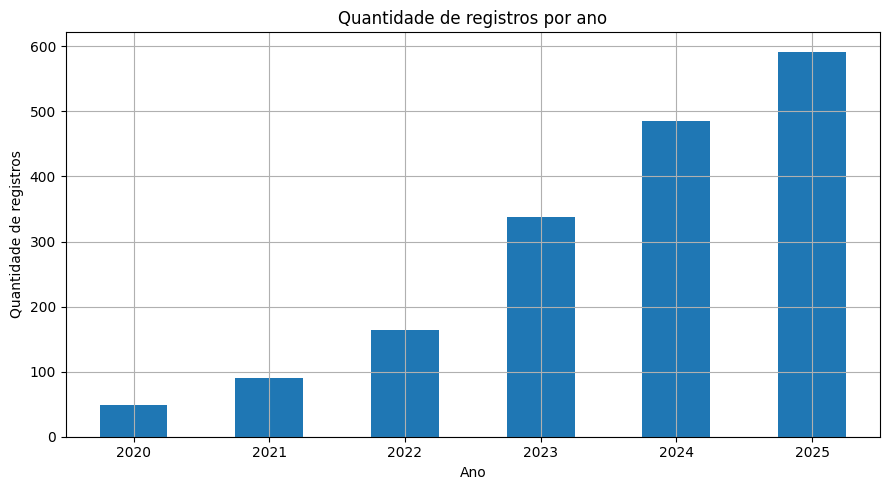

,Quantidade
Mês,
1,120
2,111
3,120
4,140
5,136
6,166
7,153
8,173
9,189


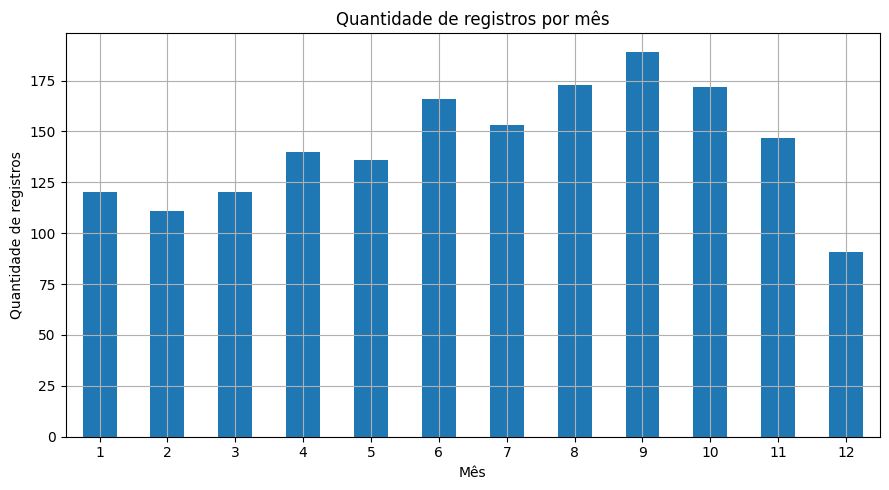


Evolução anual do target:


,Ano,Total_registros,Eventos_críticos,Taxa_eventos_críticos (%)
0,2020,48,7,14.58
1,2021,91,11,12.09
2,2022,164,35,21.34
3,2023,338,90,26.63
4,2024,485,80,16.49
5,2025,592,125,21.11


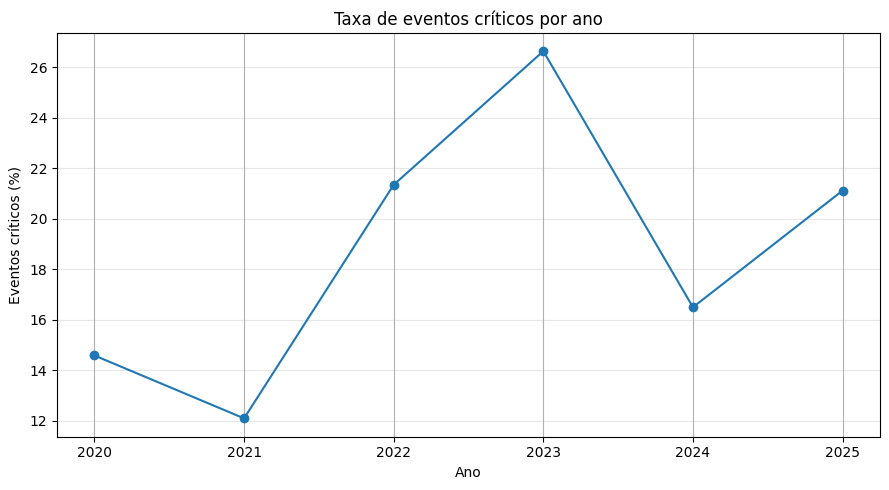


Comportamento mensal do target:


,Mês,Total_registros,Eventos_críticos,Taxa_eventos_críticos (%)
0,1,120,15,12.5
1,2,111,21,18.92
2,3,120,20,16.67
3,4,140,25,17.86
4,5,136,37,27.21
5,6,166,48,28.92
6,7,153,36,23.53
7,8,173,41,23.7
8,9,189,33,17.46
9,10,172,37,21.51


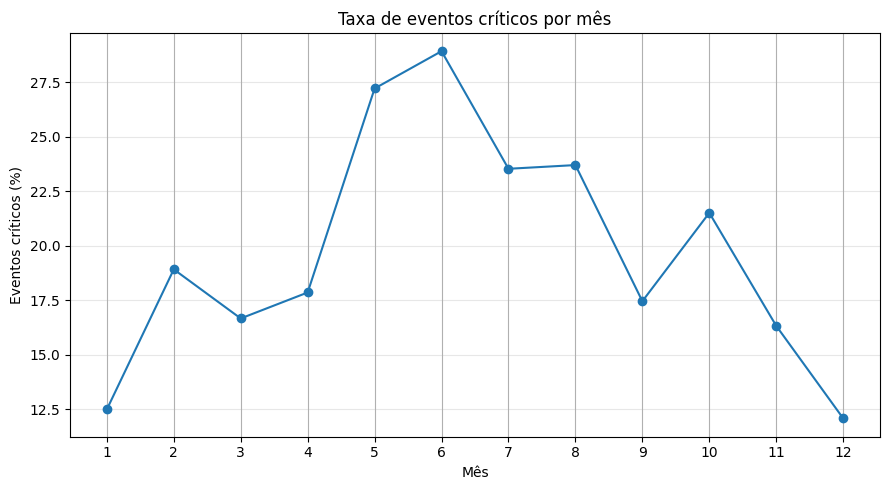


4.6 — DISTRIBUIÇÃO DAS VARIÁVEIS CANDIDATAS

Variável: Classificação
--------------------------------------------------------------------------------


,Classificação,Quantidade,Percentual (%)
0,Quase Acidente,651,37.89
1,Típico com afastamento,450,26.19
2,Típico sem afastamento,292,17.00
3,Trajeto com afastamento,145,8.44
4,Trajeto sem afastamento,89,5.18
5,Desvio Crítico,36,2.10
6,Quase acidente,28,1.63
7,Doença Ocupacional,12,0.70
8,Fatalidade,9,0.52
9,Fatalidade Trajeto,6,0.35


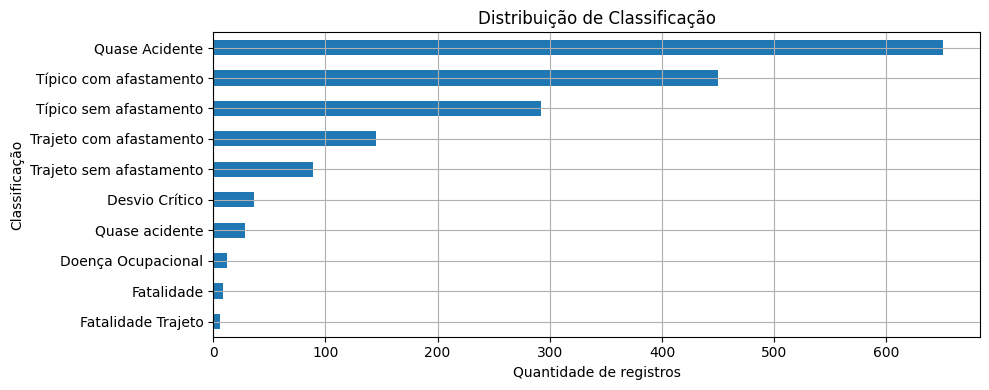


Variável: Segmento
--------------------------------------------------------------------------------


,Segmento,Quantidade,Percentual (%)
0,I,628,36.55
1,H,314,18.28
2,C,311,18.10
3,D,292,17.00
4,A,145,8.44
5,E,11,0.64
6,F,9,0.52
7,G,7,0.41
8,B,1,0.06


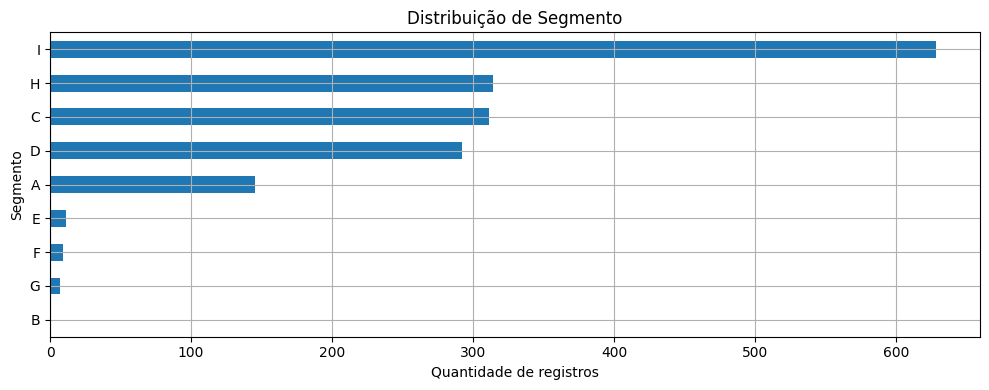


Variável: Dia da Semana
--------------------------------------------------------------------------------


,Dia da Semana,Quantidade,Percentual (%)
0,Quinta-feira,326,18.98
1,Segunda-feira,315,18.34
2,Terça-feira,312,18.16
3,Quarta-feira,299,17.40
4,Sexta-feira,279,16.24
5,Sábado,98,5.70
6,Domingo,88,5.12
7,Ausente,1,0.06


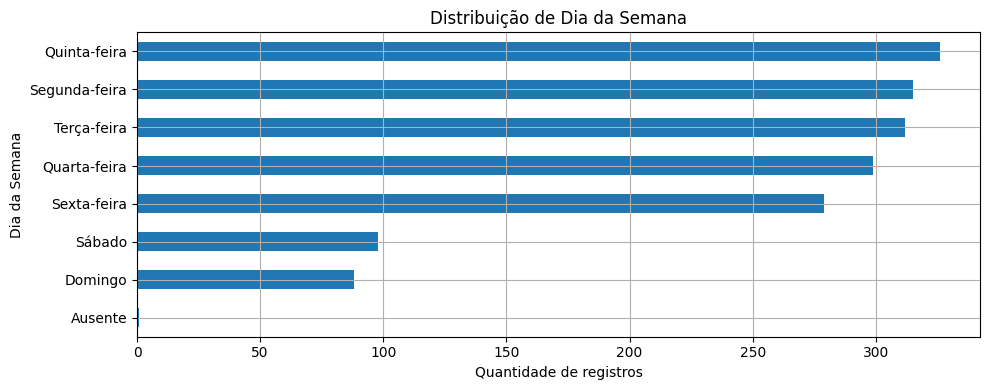


Variável: Faixas de experiência
--------------------------------------------------------------------------------


,Faixas de experiência,Quantidade,Percentual (%)
0,Até 6 meses,342,19.91
1,Acima de 10 anos,319,18.57
2,1 a 3 anos,308,17.93
3,6 meses a 1 ano,286,16.65
4,Ausente,169,9.84
5,3 a 6 anos,80,4.66
6,6 a 10 anos,59,3.43
7,10 a 15 anos,43,2.50
8,15 a 20 anos,39,2.27
9,30 a 35 anos,26,1.51


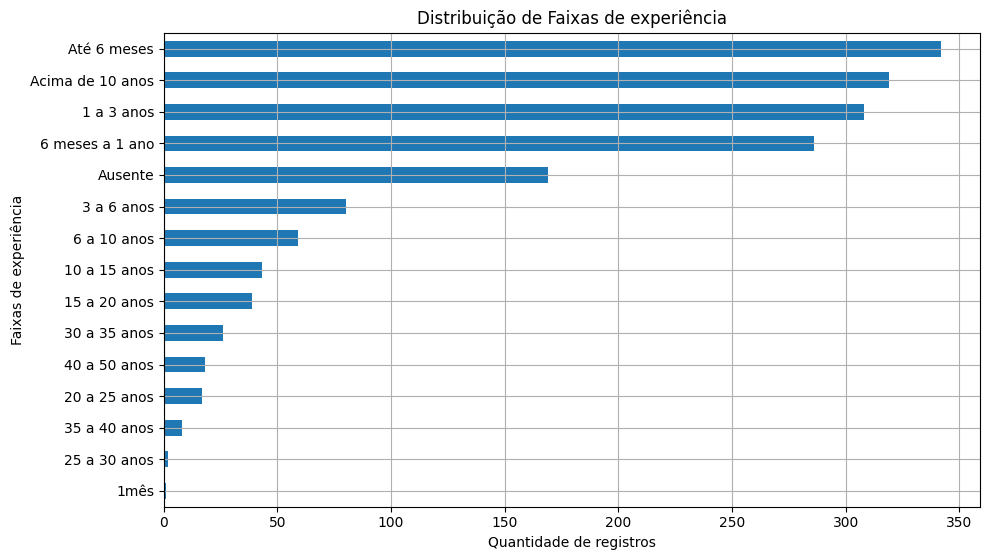


Variável: Estado
--------------------------------------------------------------------------------


,Estado,Quantidade,Percentual (%)
0,BA,253,14.73
1,RS,209,12.17
2,PE,159,9.25
3,MG,135,7.86
4,PA,119,6.93
5,SP,96,5.59
6,RJ,92,5.36
7,SC,80,4.66
8,RO,80,4.66
9,PR,55,3.20


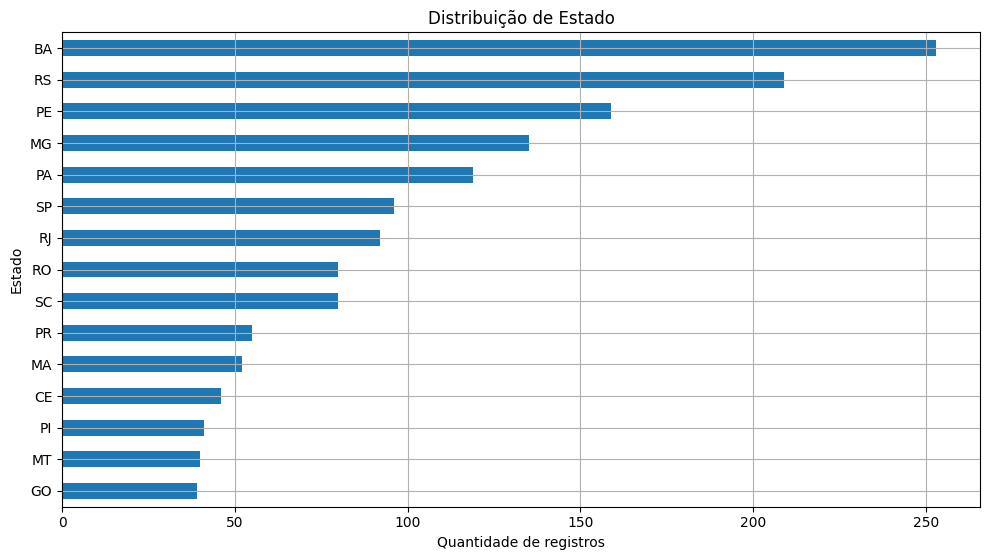


Variável: Hora
--------------------------------------------------------------------------------


,Hora,Quantidade,Percentual (%)
0,10:00 - 11:00,204,11.87
1,11:00 - 12:00,182,10.59
2,09:00 - 10:00,176,10.24
3,15:00 - 16:00,159,9.25
4,08:00 - 09:00,140,8.15
5,07:00 - 08:00,139,8.09
6,14:00 - 15:00,134,7.80
7,16:00 - 17:00,129,7.51
8,13:00 - 14:00,96,5.59
9,17:00 - 18:00,82,4.77


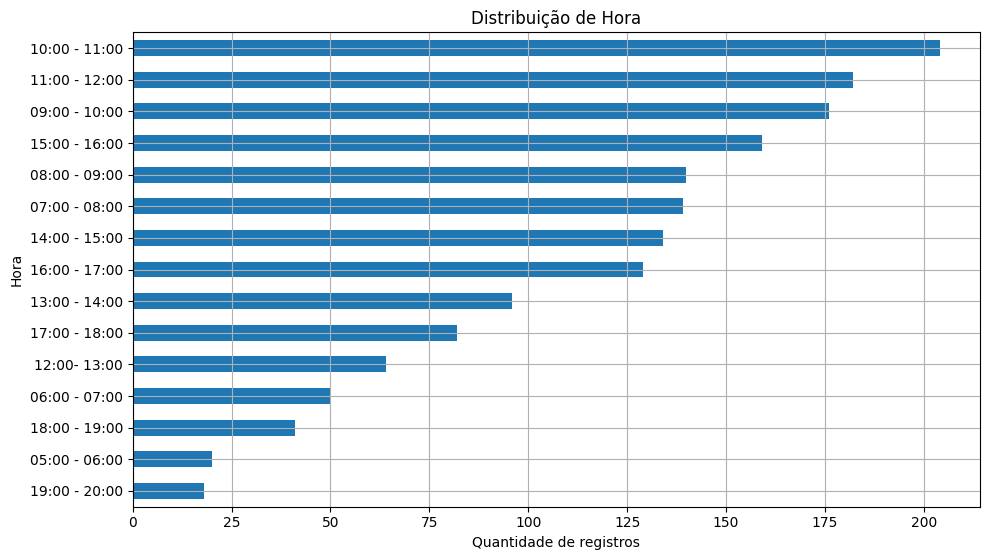


Variável: Compromissos (Regra de Ouro)
--------------------------------------------------------------------------------


,Compromissos (Regra de Ouro),Quantidade,Percentual (%)
0,8 - Veículos e Equipamentos Móveis,603,35.10
1,2 - Percepção de Risco,515,29.98
2,11 - Não se Aplica,194,11.29
3,4 - Eletricidade,114,6.64
4,Outros,112,6.52
5,3 - Trabalho em Altura,76,4.42
6,6 - Linha de Perigo,53,3.08
7,7 - Bloqueio e Proteção,16,0.93
8,10 - Produtos Químicos Perigosos,16,0.93
9,9 - Trabalho a Quente,9,0.52


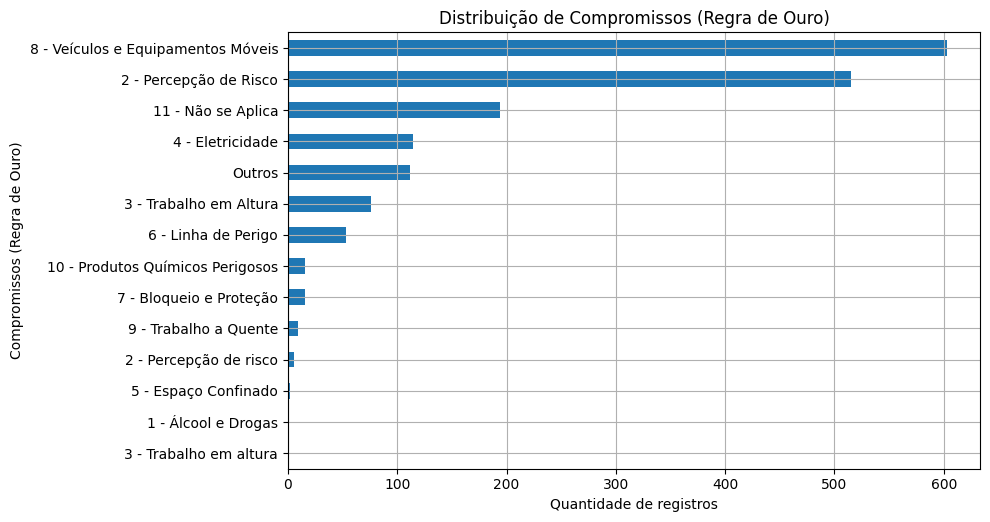


4.7 — RELAÇÃO ENTRE VARIÁVEIS E TARGET
As taxas abaixo são descritivas e não representam causalidade nem importância preditiva comprovada.

Relação entre 'Classificação' e o target
--------------------------------------------------------------------------------


,Classificação,Quantidade,Eventos_críticos,Taxa_evento_crítico (%),Participação_na_base (%)
0,Quase Acidente,651,116,17.82,37.89
1,Típico com afastamento,450,91,20.22,26.19
2,Típico sem afastamento,292,31,10.62,17.0
3,Trajeto com afastamento,145,50,34.48,8.44
4,Trajeto sem afastamento,89,22,24.72,5.18
5,Desvio Crítico,36,18,50.0,2.1
6,Quase acidente,28,5,17.86,1.63
7,Doença Ocupacional,12,0,0.0,0.7
8,Fatalidade,9,9,100.0,0.52
9,Fatalidade Trajeto,6,6,100.0,0.35


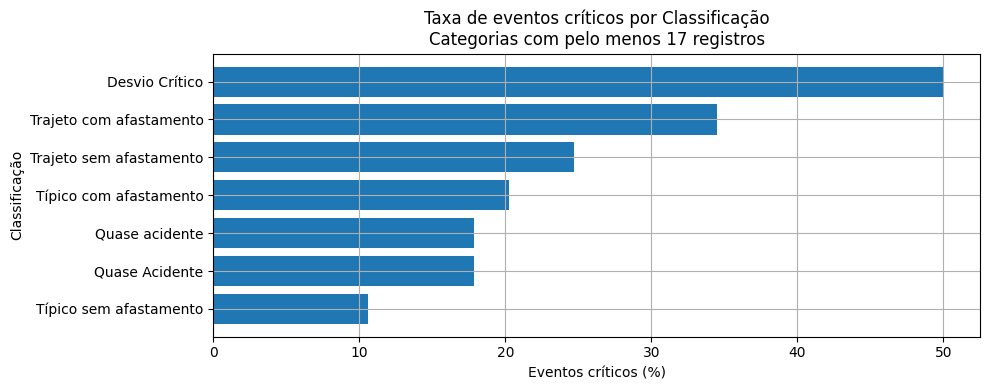


Relação entre 'Segmento' e o target
--------------------------------------------------------------------------------


,Segmento,Quantidade,Eventos_críticos,Taxa_evento_crítico (%),Participação_na_base (%)
0,I,628,154,24.52,36.55
1,H,314,57,18.15,18.28
2,C,311,44,14.15,18.1
3,D,292,62,21.23,17.0
4,A,145,26,17.93,8.44
5,E,11,2,18.18,0.64
6,F,9,0,0.0,0.52
7,G,7,2,28.57,0.41
8,B,1,1,100.0,0.06


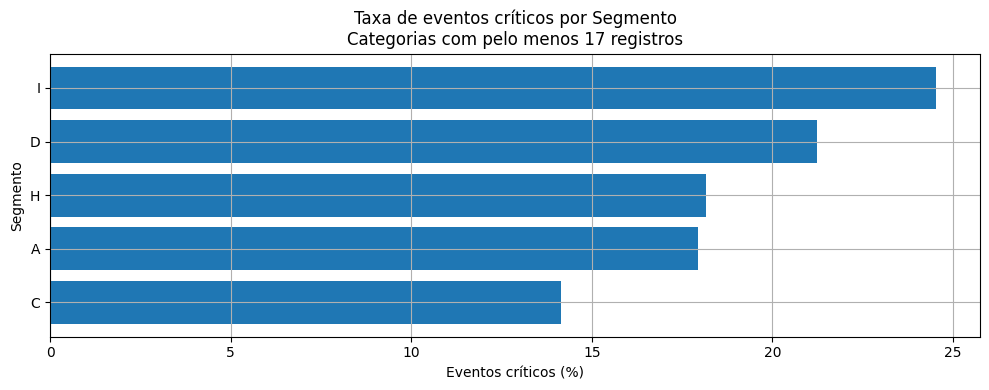


Relação entre 'Dia da Semana' e o target
--------------------------------------------------------------------------------


,Dia da Semana,Quantidade,Eventos_críticos,Taxa_evento_crítico (%),Participação_na_base (%)
0,Quinta-feira,326,67,20.55,18.98
1,Segunda-feira,315,65,20.63,18.34
2,Terça-feira,312,55,17.63,18.16
3,Quarta-feira,299,59,19.73,17.4
4,Sexta-feira,279,58,20.79,16.24
5,Sábado,98,22,22.45,5.7
6,Domingo,88,22,25.0,5.12
7,Ausente,1,0,0.0,0.06


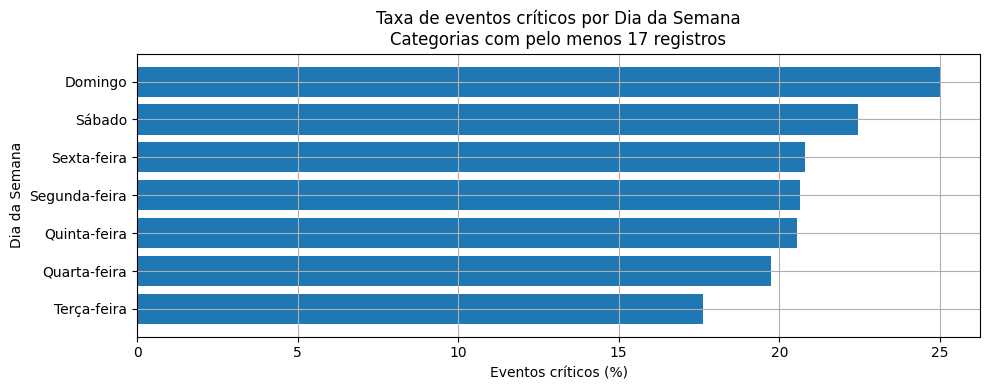


Relação entre 'Faixas de experiência' e o target
--------------------------------------------------------------------------------


,Faixas de experiência,Quantidade,Eventos_críticos,Taxa_evento_crítico (%),Participação_na_base (%)
0,Até 6 meses,342,70,20.47,19.91
1,Acima de 10 anos,319,51,15.99,18.57
2,1 a 3 anos,308,52,16.88,17.93
3,6 meses a 1 ano,286,69,24.13,16.65
4,Ausente,169,39,23.08,9.84
5,3 a 6 anos,80,14,17.5,4.66
6,6 a 10 anos,59,13,22.03,3.43
7,10 a 15 anos,43,13,30.23,2.5
8,15 a 20 anos,39,9,23.08,2.27
9,30 a 35 anos,26,6,23.08,1.51


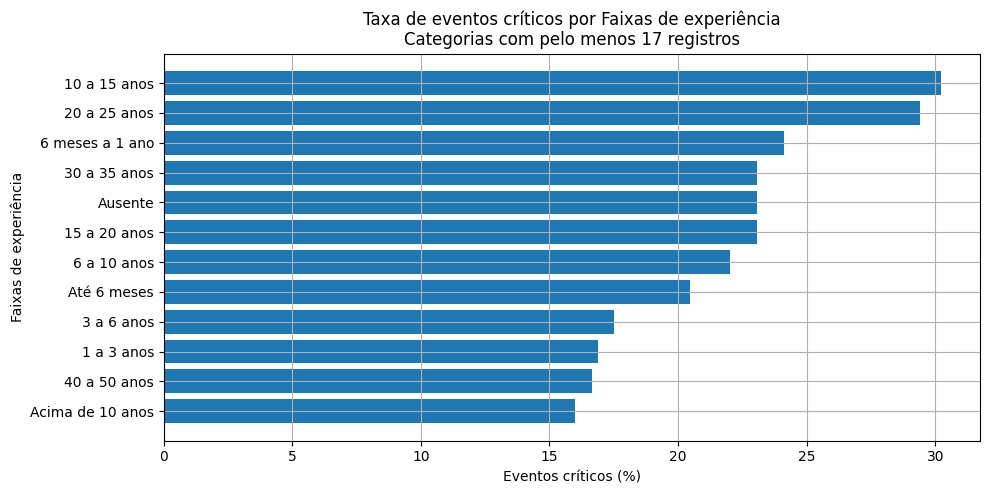


Relação entre 'Estado' e o target
--------------------------------------------------------------------------------


,Estado,Quantidade,Eventos_críticos,Taxa_evento_crítico (%),Participação_na_base (%)
0,BA,253,56,22.13,14.73
1,RS,209,35,16.75,12.17
2,PE,159,30,18.87,9.25
3,MG,135,15,11.11,7.86
4,PA,119,18,15.13,6.93
5,SP,96,24,25.0,5.59
6,RJ,92,27,29.35,5.36
7,SC,80,21,26.25,4.66
8,RO,80,18,22.5,4.66
9,PR,55,12,21.82,3.2


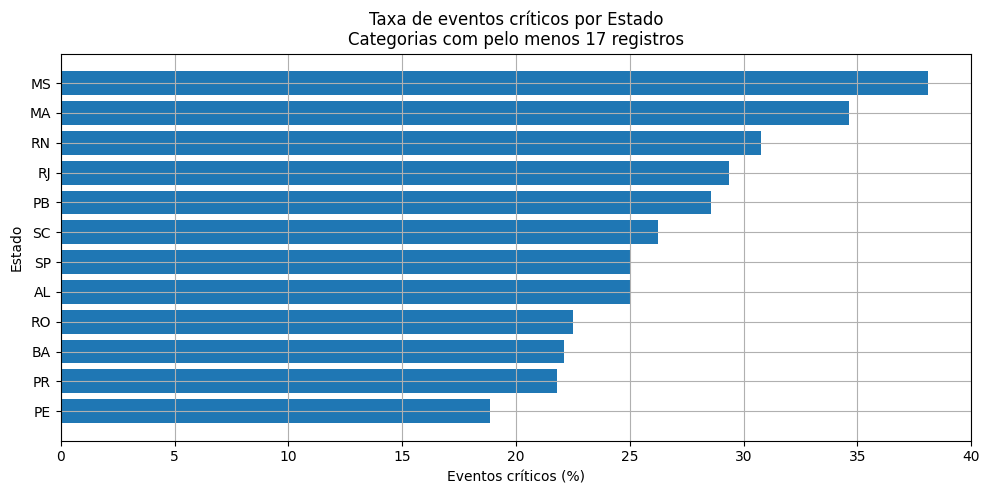


Relação entre 'Hora' e o target
--------------------------------------------------------------------------------


,Hora,Quantidade,Eventos_críticos,Taxa_evento_crítico (%),Participação_na_base (%)
0,10:00 - 11:00,204,34,16.67,11.87
1,11:00 - 12:00,182,34,18.68,10.59
2,09:00 - 10:00,176,22,12.5,10.24
3,15:00 - 16:00,159,40,25.16,9.25
4,08:00 - 09:00,140,26,18.57,8.15
5,07:00 - 08:00,139,30,21.58,8.09
6,14:00 - 15:00,134,29,21.64,7.8
7,16:00 - 17:00,129,31,24.03,7.51
8,13:00 - 14:00,96,26,27.08,5.59
9,17:00 - 18:00,82,11,13.41,4.77


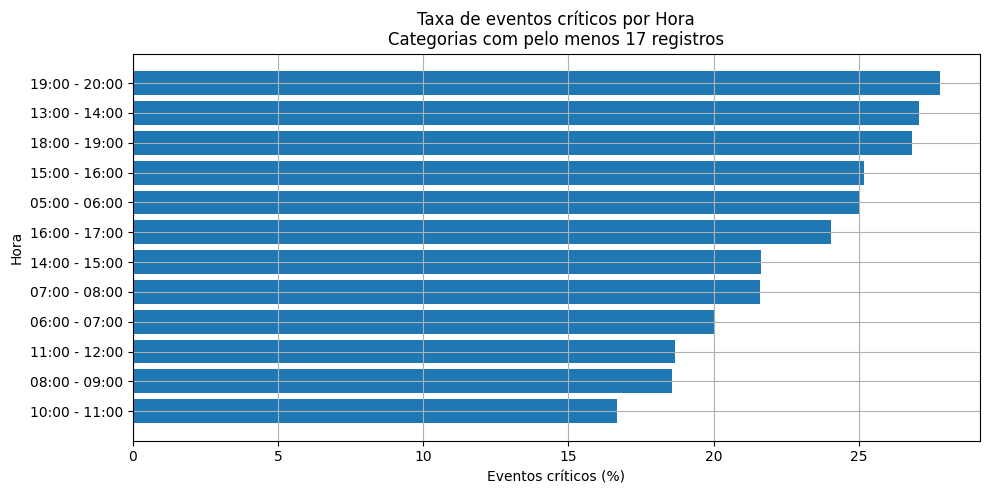


Relação entre 'Compromissos (Regra de Ouro)' e o target
--------------------------------------------------------------------------------


,Compromissos (Regra de Ouro),Quantidade,Eventos_críticos,Taxa_evento_crítico (%),Participação_na_base (%)
0,8 - Veículos e Equipamentos Móveis,603,169,28.03,35.1
1,2 - Percepção de Risco,515,37,7.18,29.98
2,11 - Não se Aplica,194,12,6.19,11.29
3,4 - Eletricidade,114,66,57.89,6.64
4,Outros,112,19,16.96,6.52
5,3 - Trabalho em Altura,76,22,28.95,4.42
6,6 - Linha de Perigo,53,10,18.87,3.08
7,10 - Produtos Químicos Perigosos,16,9,56.25,0.93
8,7 - Bloqueio e Proteção,16,2,12.5,0.93
9,9 - Trabalho a Quente,9,1,11.11,0.52


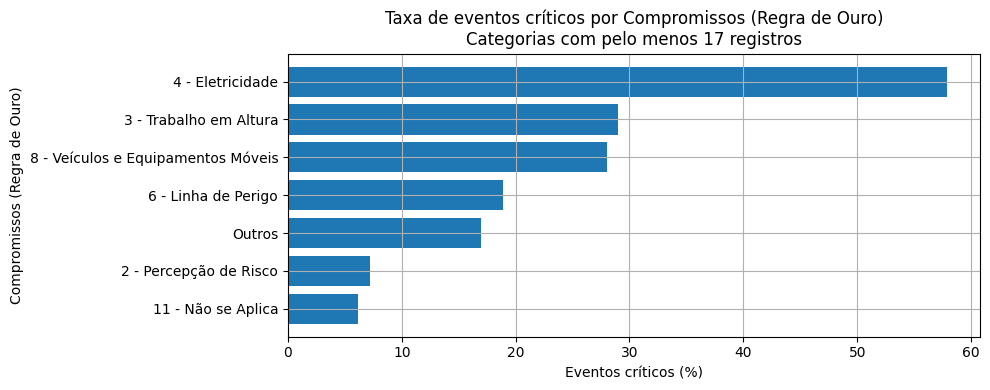


4.8 — POSSÍVEIS VALORES ATÍPICOS


,Coluna,Q1,Q3,Limite inferior,Limite superior,Possíveis outliers,Uso no modelo
0,Potencial,10.0,14.0,4.0,20.0,69,Não — variável bloqueada



Os componentes Ano, Mês e Dia foram avaliados por consistência de intervalo, e não pelo método convencional de outliers.

4.9 — VARIÁVEIS BLOQUEADAS PARA MODELAGEM


,Coluna,Motivo
0,Grau de Risco,Possível componente ou proxy direto do target.
1,Potencial,Possível componente ou proxy direto do target.
2,Gravidade,Informação potencialmente conhecida após o evento.
3,Dias Perdidos,Consequência conhecida após a ocorrência.
4,Dias Debitados,Consequência conhecida após a ocorrência.
5,Dias Perdidos Corrigidos,Consequência conhecida após a ocorrência.
6,Reabilitado,Informação conhecida após a ocorrência.
7,Descrição,Texto livre com alta especificidade e risco de vazamento.
8,Agente Causador,Disponibilidade no momento da previsão não comprovada.
9,Evento_Crítico_Target,Target bruto; nunca deve ser incluído em X.


As variáveis listadas acima não participaram dos gráficos de relação com o target e não deverão integrar a matriz X.

4.10 — SÍNTESE AUTOMÁTICA DA EDA


,Indicador,Resultado
0,Linhas analisadas,1718
1,Colunas originais,20
2,Features candidatas presentes,10
3,Total de valores ausentes,3979
4,Colunas com valores ausentes,9
5,Coluna com maior ausência,Dias Perdidos Corrigidos
6,Maior ausência (%),57.86
7,Duplicatas exatas excedentes,19
8,Target utilizado,Evento_Crítico_Target
9,Classe majoritária (%),79.74


,Evidência ou condição,Implicação metodológica
0,Possível desbalanceamento do target,"Avaliar recall, precisão, F1 e métricas baseadas em probabilidade, sem utilizar apenas a acurácia."
1,Presença de valores ausentes,"Realizar imputação dentro do pipeline, ajustada somente com os dados de treinamento."
2,Predominância de variáveis categóricas,Aplicar codificação categórica dentro do pipeline e tratar categorias desconhecidas na validação e no teste.
3,Existência de componentes temporais,Preservar a ordem cronológica na divisão dos dados e evitar embaralhamento incompatível com o problema.
4,Categorias com frequências diferentes,Avaliar categorias raras sem concluir antecipadamente que taxas elevadas representam padrões generalizáveis.
5,Existência de duplicatas exatas,Controlar grupos duplicados durante a divisão para impedir que cópias apareçam em conjuntos diferentes.
6,Variáveis posteriores ou relacionadas ao target,Excluir as colunas bloqueadas da matriz de atributos para reduzir o risco de vazamento de dados.



ANÁLISE EXPLORATÓRIA CONCLUÍDA
Nenhuma linha ou coluna foi removida.
Nenhuma imputação, codificação, padronização, seleção de atributos, divisão dos dados ou modelagem foi executada.
O DataFrame original 'df' permanece inalterado.


In [16]:
# ============================================================
# 4. Análise exploratória dos dados
# Projeto SICOP — MVP de Machine Learning
# ============================================================

from IPython.display import display
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Verificação do DataFrame
# ------------------------------------------------------------
if "df" not in globals():
    raise NameError(
        "O DataFrame 'df' não foi encontrado. "
        "Execute primeiro a seção 3.2 — Carga dos dados."
    )

if df.empty:
    raise ValueError(
        "O DataFrame 'df' está vazio. "
        "Verifique a etapa de carga dos dados."
    )

# Cópia exclusiva para a EDA.
# O DataFrame original não será alterado.
df_eda = df.copy(deep=True)


# ------------------------------------------------------------
# 2. Configurações metodológicas do SICOP
# ------------------------------------------------------------
TARGETS_POSSIVEIS = [
    "Evento_Crítico_Target_Modelagem",
    "Evento_Crítico_Target"
]

TARGET_COLUMN = next(
    (
        coluna
        for coluna in TARGETS_POSSIVEIS
        if coluna in df_eda.columns
    ),
    None
)

if TARGET_COLUMN is None:
    raise ValueError(
        "Nenhuma variável-alvo esperada foi encontrada.\n"
        f"Targets procurados: {TARGETS_POSSIVEIS}"
    )


# Variáveis candidatas consideradas na análise exploratória.
# A inclusão definitiva no modelo será decidida posteriormente.
FEATURES_CANDIDATAS = [
    "Classificação",
    "Ano",
    "Mês",
    "Dia",
    "Hora",
    "Dia da Semana",
    "Estado",
    "Segmento",
    "Faixas de experiência",
    "Compromissos (Regra de Ouro)"
]

FEATURES_PRESENTES = [
    coluna
    for coluna in FEATURES_CANDIDATAS
    if coluna in df_eda.columns
]


# Variáveis que não devem ser tratadas como preditores.
COLUNAS_BLOQUEADAS = {
    "Grau de Risco":
        "Possível componente ou proxy direto do target.",

    "Potencial":
        "Possível componente ou proxy direto do target.",

    "Gravidade":
        "Informação potencialmente conhecida após o evento.",

    "Dias Perdidos":
        "Consequência conhecida após a ocorrência.",

    "Dias Debitados":
        "Consequência conhecida após a ocorrência.",

    "Dias Perdidos Corrigidos":
        "Consequência conhecida após a ocorrência.",

    "Reabilitado":
        "Informação conhecida após a ocorrência.",

    "Descrição":
        "Texto livre com alta especificidade e risco de vazamento.",

    "Agente Causador":
        "Disponibilidade no momento da previsão não comprovada.",

    "Evento_Crítico_Target":
        "Target bruto; nunca deve ser incluído em X."
}

COLUNAS_BLOQUEADAS_PRESENTES = [
    coluna
    for coluna in COLUNAS_BLOQUEADAS
    if coluna in df_eda.columns
]


# Número mínimo de registros para apresentar taxas por categoria.
# Evita destacar percentuais instáveis de categorias muito raras.
MINIMO_REGISTROS_CATEGORIA = max(
    15,
    round(len(df_eda) * 0.01)
)


# ------------------------------------------------------------
# 3. Funções auxiliares
# ------------------------------------------------------------
def normalizar_texto(valor):
    """
    Normaliza textos para comparação, removendo acentos,
    espaços excedentes e diferenças entre maiúsculas e minúsculas.
    """
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    ).encode(
        "ascii",
        "ignore"
    ).decode(
        "utf-8"
    )

    return " ".join(texto.casefold().split())


def converter_target_binario(serie):
    """
    Converte o target para 0 e 1 apenas na cópia utilizada
    na análise exploratória.
    """
    mapa_target = {
        "nao": 0,
        "não": 0,
        "0": 0,
        "false": 0,
        "sim": 1,
        "1": 1,
        "true": 1
    }

    target_normalizado = serie.map(normalizar_texto)
    target_binario = target_normalizado.map(mapa_target)

    valores_invalidos = (
        serie[
            serie.notna()
            & target_binario.isna()
        ]
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    if valores_invalidos:
        raise ValueError(
            "Foram encontrados valores não reconhecidos no target:\n"
            f"{valores_invalidos}"
        )

    return target_binario.astype("Int64")


def preparar_categoria(serie):
    """
    Normaliza valores categóricos apenas para apresentação.
    Os valores ausentes são explicitados como 'Ausente'.
    """
    return (
        serie
        .fillna("Ausente")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .replace("", "Ausente")
    )


def adicionar_rotulos_barras(eixo, formato_percentual=False):
    """
    Adiciona valores sobre as barras dos gráficos.
    """
    for barra in eixo.patches:
        valor = barra.get_height()

        if formato_percentual:
            rotulo = f"{valor:.1f}%"
        else:
            rotulo = f"{int(valor)}"

        eixo.annotate(
            rotulo,
            (
                barra.get_x() + barra.get_width() / 2,
                valor
            ),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )


def plotar_contagem_categoria(
    dados,
    coluna,
    titulo=None,
    top_n=15
):
    """
    Plota a frequência das categorias mais comuns.
    """
    contagem = (
        preparar_categoria(dados[coluna])
        .value_counts()
        .head(top_n)
        .sort_values()
    )

    plt.figure(
        figsize=(
            10,
            max(4, len(contagem) * 0.38)
        )
    )

    contagem.plot(kind="barh")

    plt.title(
        titulo or f"Distribuição de {coluna}"
    )
    plt.xlabel("Quantidade de registros")
    plt.ylabel(coluna)
    plt.tight_layout()
    plt.show()

    return contagem


def resumir_target_por_categoria(
    dados,
    coluna
):
    """
    Calcula quantidade de registros, eventos críticos e taxa
    de ocorrência para cada categoria.
    """
    temporario = pd.DataFrame({
        coluna: preparar_categoria(dados[coluna]),
        "_target_eda": dados["_target_eda"]
    })

    temporario = temporario.dropna(
        subset=["_target_eda"]
    )

    resumo = (
        temporario
        .groupby(coluna, dropna=False)["_target_eda"]
        .agg(
            Quantidade="size",
            Eventos_críticos="sum",
            Taxa_evento_crítico="mean"
        )
        .reset_index()
    )

    resumo["Eventos_críticos"] = (
        resumo["Eventos_críticos"]
        .astype(int)
    )

    resumo["Taxa_evento_crítico (%)"] = (
        resumo["Taxa_evento_crítico"] * 100
    ).round(2)

    resumo["Participação_na_base (%)"] = (
        resumo["Quantidade"]
        / resumo["Quantidade"].sum()
        * 100
    ).round(2)

    return (
        resumo
        .drop(columns="Taxa_evento_crítico")
        .sort_values(
            by=[
                "Quantidade",
                "Taxa_evento_crítico (%)"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(drop=True)
    )


def plotar_taxa_target_por_categoria(
    resumo,
    coluna,
    top_n=12
):
    """
    Plota taxas do target somente para categorias com um
    número mínimo de observações.
    """
    elegiveis = resumo.loc[
        resumo["Quantidade"]
        >= MINIMO_REGISTROS_CATEGORIA
    ].copy()

    if elegiveis.empty:
        print(
            f"Não há categorias de '{coluna}' com pelo menos "
            f"{MINIMO_REGISTROS_CATEGORIA} registros."
        )
        return

    elegiveis = (
        elegiveis
        .sort_values(
            "Taxa_evento_crítico (%)",
            ascending=False
        )
        .head(top_n)
        .sort_values(
            "Taxa_evento_crítico (%)"
        )
    )

    plt.figure(
        figsize=(
            10,
            max(4, len(elegiveis) * 0.42)
        )
    )

    plt.barh(
        elegiveis[coluna],
        elegiveis["Taxa_evento_crítico (%)"]
    )

    plt.title(
        f"Taxa de eventos críticos por {coluna}\n"
        f"Categorias com pelo menos "
        f"{MINIMO_REGISTROS_CATEGORIA} registros"
    )
    plt.xlabel("Eventos críticos (%)")
    plt.ylabel(coluna)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Preparação exclusivamente descritiva do target
# ------------------------------------------------------------
df_eda["_target_eda"] = converter_target_binario(
    df_eda[TARGET_COLUMN]
)

target_validos = int(
    df_eda["_target_eda"].notna().sum()
)

target_ausentes = int(
    df_eda["_target_eda"].isna().sum()
)


print("=" * 80)
print("4 — ANÁLISE EXPLORATÓRIA DOS DADOS — SICOP")
print("=" * 80)

print(f"\nBase analisada: df")
print(f"Dimensões: {df_eda.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Target utilizado na EDA: {TARGET_COLUMN}")
print(f"Registros com target válido: {target_validos}")
print(f"Registros sem target: {target_ausentes}")
print(
    "Observação: o target binário foi criado somente na cópia "
    "df_eda; o DataFrame original não foi modificado."
)

if TARGET_COLUMN == "Evento_Crítico_Target":
    print(
        "\nATENÇÃO METODOLÓGICA: esta análise utiliza o target bruto. "
        "Sua regra de construção deverá permanecer documentada e "
        "validada antes da modelagem definitiva."
    )


# ------------------------------------------------------------
# 5. Qualidade e completude dos dados
# ------------------------------------------------------------
resumo_qualidade = pd.DataFrame({
    "Coluna": df_eda.columns.drop("_target_eda"),
    "Tipo": [
        str(df_eda[coluna].dtype)
        for coluna in df_eda.columns
        if coluna != "_target_eda"
    ],
    "Ausentes": [
        int(df_eda[coluna].isna().sum())
        for coluna in df_eda.columns
        if coluna != "_target_eda"
    ],
    "Ausentes (%)": [
        round(
            df_eda[coluna].isna().mean() * 100,
            2
        )
        for coluna in df_eda.columns
        if coluna != "_target_eda"
    ],
    "Valores únicos": [
        int(df_eda[coluna].nunique(dropna=True))
        for coluna in df_eda.columns
        if coluna != "_target_eda"
    ]
})

resumo_qualidade = resumo_qualidade.sort_values(
    by=["Ausentes", "Coluna"],
    ascending=[False, True]
).reset_index(drop=True)

print("\n" + "=" * 80)
print("4.1 — QUALIDADE E COMPLETUDE")
print("=" * 80)

display(resumo_qualidade)


ausentes_grafico = (
    resumo_qualidade
    .loc[resumo_qualidade["Ausentes"] > 0]
    .head(15)
    .sort_values("Ausentes (%)")
)

if not ausentes_grafico.empty:
    plt.figure(
        figsize=(
            10,
            max(4, len(ausentes_grafico) * 0.4)
        )
    )

    plt.barh(
        ausentes_grafico["Coluna"],
        ausentes_grafico["Ausentes (%)"]
    )

    plt.title("Percentual de valores ausentes por coluna")
    plt.xlabel("Valores ausentes (%)")
    plt.ylabel("Coluna")
    plt.tight_layout()
    plt.show()
else:
    print("Não foram encontrados valores ausentes.")


# ------------------------------------------------------------
# 6. Duplicatas
# ------------------------------------------------------------
duplicatas_excedentes = int(
    df.duplicated().sum()
)

linhas_em_grupos_duplicados = int(
    df.duplicated(keep=False).sum()
)

print("\n" + "=" * 80)
print("4.2 — DUPLICATAS")
print("=" * 80)

print(
    f"Duplicatas exatas excedentes: "
    f"{duplicatas_excedentes}"
)
print(
    f"Linhas pertencentes a grupos duplicados: "
    f"{linhas_em_grupos_duplicados}"
)

if duplicatas_excedentes > 0:
    print(
        "As duplicatas não foram removidas nesta seção. "
        "Elas deverão ser controladas na divisão dos dados para "
        "impedir que registros iguais apareçam em conjuntos diferentes."
    )


# ------------------------------------------------------------
# 7. Distribuição do target
# ------------------------------------------------------------
distribuicao_target = (
    df_eda["_target_eda"]
    .value_counts(dropna=False)
    .reindex([0, 1], fill_value=0)
    .rename_axis("Classe")
    .reset_index(name="Quantidade")
)

distribuicao_target["Descrição"] = (
    distribuicao_target["Classe"]
    .map({
        0: "Não crítico",
        1: "Crítico"
    })
)

distribuicao_target["Percentual (%)"] = (
    distribuicao_target["Quantidade"]
    / distribuicao_target["Quantidade"].sum()
    * 100
).round(2)

distribuicao_target = distribuicao_target[
    [
        "Classe",
        "Descrição",
        "Quantidade",
        "Percentual (%)"
    ]
]

print("\n" + "=" * 80)
print("4.3 — DISTRIBUIÇÃO DO TARGET")
print("=" * 80)

display(distribuicao_target)


plt.figure(figsize=(7, 5))

eixo_target = plt.bar(
    distribuicao_target["Descrição"],
    distribuicao_target["Quantidade"]
)

plt.title("Distribuição da variável-alvo")
plt.xlabel("Classe")
plt.ylabel("Quantidade de registros")

for barra, percentual in zip(
    eixo_target,
    distribuicao_target["Percentual (%)"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{int(barra.get_height())}\n({percentual:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


quantidade_classe_0 = int(
    distribuicao_target.loc[
        distribuicao_target["Classe"] == 0,
        "Quantidade"
    ].iloc[0]
)

quantidade_classe_1 = int(
    distribuicao_target.loc[
        distribuicao_target["Classe"] == 1,
        "Quantidade"
    ].iloc[0]
)

if quantidade_classe_1 > 0:
    razao_desbalanceamento = (
        quantidade_classe_0
        / quantidade_classe_1
    )
else:
    razao_desbalanceamento = np.inf

percentual_majoritaria = float(
    distribuicao_target["Percentual (%)"].max()
)

print(
    f"Razão classe 0 / classe 1: "
    f"{razao_desbalanceamento:.2f}"
)
print(
    f"Participação da classe majoritária: "
    f"{percentual_majoritaria:.2f}%"
)

if percentual_majoritaria >= 70:
    print(
        "Diagnóstico: existe desbalanceamento relevante entre "
        "as classes. A acurácia não deverá ser utilizada "
        "isoladamente na avaliação dos modelos."
    )
else:
    print(
        "Diagnóstico: não foi identificado desbalanceamento "
        "intenso pelo critério descritivo de 70%."
    )


# ------------------------------------------------------------
# 8. Validação dos componentes temporais
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("4.4 — CONSISTÊNCIA DAS VARIÁVEIS TEMPORAIS")
print("=" * 80)

validacoes_temporais = []

if "Ano" in df_eda.columns:
    ano_numerico = pd.to_numeric(
        df_eda["Ano"],
        errors="coerce"
    )

    validacoes_temporais.append({
        "Verificação": "Ano ausente ou não numérico",
        "Quantidade": int(ano_numerico.isna().sum())
    })
else:
    ano_numerico = None


if "Mês" in df_eda.columns:
    mes_numerico = pd.to_numeric(
        df_eda["Mês"],
        errors="coerce"
    )

    validacoes_temporais.append({
        "Verificação": "Mês ausente ou não numérico",
        "Quantidade": int(mes_numerico.isna().sum())
    })

    validacoes_temporais.append({
        "Verificação": "Mês fora do intervalo 1–12",
        "Quantidade": int(
            (
                mes_numerico.notna()
                & ~mes_numerico.between(1, 12)
            ).sum()
        )
    })
else:
    mes_numerico = None


if "Dia" in df_eda.columns:
    dia_numerico = pd.to_numeric(
        df_eda["Dia"],
        errors="coerce"
    )

    validacoes_temporais.append({
        "Verificação": "Dia ausente ou não numérico",
        "Quantidade": int(dia_numerico.isna().sum())
    })

    validacoes_temporais.append({
        "Verificação": "Dia fora do intervalo 1–31",
        "Quantidade": int(
            (
                dia_numerico.notna()
                & ~dia_numerico.between(1, 31)
            ).sum()
        )
    })
else:
    dia_numerico = None


if "Hora" in df_eda.columns:
    validacoes_temporais.append({
        "Verificação": "Hora ausente",
        "Quantidade": int(df_eda["Hora"].isna().sum())
    })


display(pd.DataFrame(validacoes_temporais))


# Reconstrução exclusivamente diagnóstica da data.
if all(
    coluna in df_eda.columns
    for coluna in ["Ano", "Mês", "Dia"]
):
    data_eda = pd.to_datetime(
        {
            "year": ano_numerico,
            "month": mes_numerico,
            "day": dia_numerico
        },
        errors="coerce"
    )

    datas_validas = data_eda.dropna()

    print(
        f"Datas válidas reconstruídas: "
        f"{len(datas_validas)} de {len(df_eda)}"
    )
    print(
        f"Datas inválidas ou incompletas: "
        f"{data_eda.isna().sum()}"
    )

    if not datas_validas.empty:
        print(
            f"Período observado: "
            f"{datas_validas.min().date()} a "
            f"{datas_validas.max().date()}"
        )
else:
    data_eda = pd.Series(
        pd.NaT,
        index=df_eda.index
    )


# ------------------------------------------------------------
# 9. Distribuições temporais
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("4.5 — DISTRIBUIÇÕES TEMPORAIS")
print("=" * 80)

if "Ano" in df_eda.columns:
    distribuicao_ano = (
        pd.to_numeric(
            df_eda["Ano"],
            errors="coerce"
        )
        .value_counts()
        .sort_index()
    )

    display(
        distribuicao_ano
        .rename("Quantidade")
        .to_frame()
    )

    plt.figure(figsize=(9, 5))
    distribuicao_ano.plot(kind="bar")
    plt.title("Quantidade de registros por ano")
    plt.xlabel("Ano")
    plt.ylabel("Quantidade de registros")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


if "Mês" in df_eda.columns:
    distribuicao_mes = (
        pd.to_numeric(
            df_eda["Mês"],
            errors="coerce"
        )
        .value_counts()
        .reindex(range(1, 13), fill_value=0)
    )

    display(
        distribuicao_mes
        .rename("Quantidade")
        .to_frame()
    )

    plt.figure(figsize=(9, 5))
    distribuicao_mes.plot(kind="bar")
    plt.title("Quantidade de registros por mês")
    plt.xlabel("Mês")
    plt.ylabel("Quantidade de registros")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 10. Evolução temporal do target
# ------------------------------------------------------------
if "Ano" in df_eda.columns:
    temporal_ano = pd.DataFrame({
        "Ano": pd.to_numeric(
            df_eda["Ano"],
            errors="coerce"
        ),
        "Target": df_eda["_target_eda"]
    }).dropna()

    resumo_temporal_ano = (
        temporal_ano
        .groupby("Ano")["Target"]
        .agg(
            Total_registros="size",
            Eventos_críticos="sum",
            Taxa_eventos_críticos="mean"
        )
        .reset_index()
    )

    resumo_temporal_ano["Eventos_críticos"] = (
        resumo_temporal_ano["Eventos_críticos"]
        .astype(int)
    )

    resumo_temporal_ano[
        "Taxa_eventos_críticos (%)"
    ] = (
        resumo_temporal_ano[
            "Taxa_eventos_críticos"
        ] * 100
    ).round(2)

    resumo_temporal_ano = (
        resumo_temporal_ano
        .drop(columns="Taxa_eventos_críticos")
    )

    print("\nEvolução anual do target:")
    display(resumo_temporal_ano)

    plt.figure(figsize=(9, 5))

    plt.plot(
        resumo_temporal_ano["Ano"],
        resumo_temporal_ano[
            "Taxa_eventos_críticos (%)"
        ],
        marker="o"
    )

    plt.title("Taxa de eventos críticos por ano")
    plt.xlabel("Ano")
    plt.ylabel("Eventos críticos (%)")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


if "Mês" in df_eda.columns:
    temporal_mes = pd.DataFrame({
        "Mês": pd.to_numeric(
            df_eda["Mês"],
            errors="coerce"
        ),
        "Target": df_eda["_target_eda"]
    }).dropna()

    resumo_temporal_mes = (
        temporal_mes
        .groupby("Mês")["Target"]
        .agg(
            Total_registros="size",
            Eventos_críticos="sum",
            Taxa_eventos_críticos="mean"
        )
        .reindex(range(1, 13))
        .reset_index()
    )

    resumo_temporal_mes[
        "Taxa_eventos_críticos (%)"
    ] = (
        resumo_temporal_mes[
            "Taxa_eventos_críticos"
        ] * 100
    ).round(2)

    resumo_temporal_mes = (
        resumo_temporal_mes
        .drop(columns="Taxa_eventos_críticos")
    )

    print("\nComportamento mensal do target:")
    display(resumo_temporal_mes)

    plt.figure(figsize=(9, 5))

    plt.plot(
        resumo_temporal_mes["Mês"],
        resumo_temporal_mes[
            "Taxa_eventos_críticos (%)"
        ],
        marker="o"
    )

    plt.title("Taxa de eventos críticos por mês")
    plt.xlabel("Mês")
    plt.ylabel("Eventos críticos (%)")
    plt.xticks(range(1, 13))
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 11. Distribuição das principais variáveis categóricas
# ------------------------------------------------------------
FEATURES_DISTRIBUICAO = [
    "Classificação",
    "Segmento",
    "Dia da Semana",
    "Faixas de experiência",
    "Estado",
    "Hora",
    "Compromissos (Regra de Ouro)"
]

FEATURES_DISTRIBUICAO = [
    coluna
    for coluna in FEATURES_DISTRIBUICAO
    if coluna in df_eda.columns
]

print("\n" + "=" * 80)
print("4.6 — DISTRIBUIÇÃO DAS VARIÁVEIS CANDIDATAS")
print("=" * 80)

tabelas_distribuicao = {}

for coluna in FEATURES_DISTRIBUICAO:
    print(f"\nVariável: {coluna}")
    print("-" * 80)

    contagem = (
        preparar_categoria(df_eda[coluna])
        .value_counts()
        .rename_axis(coluna)
        .reset_index(name="Quantidade")
    )

    contagem["Percentual (%)"] = (
        contagem["Quantidade"]
        / contagem["Quantidade"].sum()
        * 100
    ).round(2)

    tabelas_distribuicao[coluna] = contagem

    display(contagem.head(20))

    plotar_contagem_categoria(
        df_eda,
        coluna,
        top_n=15
    )


# ------------------------------------------------------------
# 12. Relação entre as variáveis candidatas e o target
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("4.7 — RELAÇÃO ENTRE VARIÁVEIS E TARGET")
print("=" * 80)

print(
    "As taxas abaixo são descritivas e não representam "
    "causalidade nem importância preditiva comprovada."
)

FEATURES_RELACAO_TARGET = [
    "Classificação",
    "Segmento",
    "Dia da Semana",
    "Faixas de experiência",
    "Estado",
    "Hora",
    "Compromissos (Regra de Ouro)"
]

FEATURES_RELACAO_TARGET = [
    coluna
    for coluna in FEATURES_RELACAO_TARGET
    if coluna in df_eda.columns
]

tabelas_relacao_target = {}

for coluna in FEATURES_RELACAO_TARGET:
    print(f"\nRelação entre '{coluna}' e o target")
    print("-" * 80)

    resumo_categoria = resumir_target_por_categoria(
        df_eda,
        coluna
    )

    tabelas_relacao_target[coluna] = resumo_categoria

    display(resumo_categoria.head(20))

    plotar_taxa_target_por_categoria(
        resumo_categoria,
        coluna
    )


# ------------------------------------------------------------
# 13. Verificação descritiva de possíveis outliers
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("4.8 — POSSÍVEIS VALORES ATÍPICOS")
print("=" * 80)

# Ano, mês e dia são componentes de calendário e não devem ser
# interpretados como variáveis contínuas convencionais.
COLUNAS_CALENDARIO = {
    "Ano",
    "Mês",
    "Dia"
}

colunas_numericas_continuas = [
    coluna
    for coluna in df_eda.select_dtypes(
        include=np.number
    ).columns
    if coluna not in COLUNAS_CALENDARIO
    and coluna != "_target_eda"
]

resumo_outliers = []

for coluna in colunas_numericas_continuas:
    serie = pd.to_numeric(
        df_eda[coluna],
        errors="coerce"
    ).dropna()

    if serie.empty:
        continue

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    intervalo_interquartil = q3 - q1

    limite_inferior = (
        q1 - 1.5 * intervalo_interquartil
    )
    limite_superior = (
        q3 + 1.5 * intervalo_interquartil
    )

    quantidade_outliers = int(
        (
            (serie < limite_inferior)
            | (serie > limite_superior)
        ).sum()
    )

    resumo_outliers.append({
        "Coluna": coluna,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "Limite inferior": round(
            limite_inferior,
            2
        ),
        "Limite superior": round(
            limite_superior,
            2
        ),
        "Possíveis outliers": quantidade_outliers,
        "Uso no modelo": (
            "Não — variável bloqueada"
            if coluna in COLUNAS_BLOQUEADAS
            else "Requer avaliação"
        )
    })

if resumo_outliers:
    display(pd.DataFrame(resumo_outliers))
else:
    print(
        "Não existem variáveis numéricas contínuas candidatas "
        "à modelagem para aplicação adequada do critério de IQR."
    )

print(
    "\nOs componentes Ano, Mês e Dia foram avaliados por consistência "
    "de intervalo, e não pelo método convencional de outliers."
)


# ------------------------------------------------------------
# 14. Registro das variáveis bloqueadas
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("4.9 — VARIÁVEIS BLOQUEADAS PARA MODELAGEM")
print("=" * 80)

tabela_bloqueadas = pd.DataFrame([
    {
        "Coluna": coluna,
        "Motivo": COLUNAS_BLOQUEADAS[coluna]
    }
    for coluna in COLUNAS_BLOQUEADAS_PRESENTES
])

display(tabela_bloqueadas)

print(
    "As variáveis listadas acima não participaram dos gráficos "
    "de relação com o target e não deverão integrar a matriz X."
)


# ------------------------------------------------------------
# 15. Síntese automática dos resultados da EDA
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("4.10 — SÍNTESE AUTOMÁTICA DA EDA")
print("=" * 80)

total_ausentes = int(
    df.isna().sum().sum()
)

colunas_com_ausentes = int(
    (df.isna().sum() > 0).sum()
)

maior_percentual_ausente = (
    resumo_qualidade["Ausentes (%)"].max()
)

coluna_maior_ausencia = (
    resumo_qualidade.iloc[0]["Coluna"]
    if maior_percentual_ausente > 0
    else "Nenhuma"
)

sintese_eda = pd.DataFrame({
    "Indicador": [
        "Linhas analisadas",
        "Colunas originais",
        "Features candidatas presentes",
        "Total de valores ausentes",
        "Colunas com valores ausentes",
        "Coluna com maior ausência",
        "Maior ausência (%)",
        "Duplicatas exatas excedentes",
        "Target utilizado",
        "Classe majoritária (%)",
        "Razão classe 0 / classe 1",
        "Mínimo de registros por categoria nos gráficos",
        "Variáveis bloqueadas presentes"
    ],
    "Resultado": [
        len(df_eda),
        df.shape[1],
        len(FEATURES_PRESENTES),
        total_ausentes,
        colunas_com_ausentes,
        coluna_maior_ausencia,
        maior_percentual_ausente,
        duplicatas_excedentes,
        TARGET_COLUMN,
        percentual_majoritaria,
        round(razao_desbalanceamento, 2),
        MINIMO_REGISTROS_CATEGORIA,
        len(COLUNAS_BLOQUEADAS_PRESENTES)
    ]
})

display(sintese_eda)


# ------------------------------------------------------------
# 16. Hipóteses e implicações para as próximas etapas
# ------------------------------------------------------------
hipoteses_eda = pd.DataFrame({
    "Evidência ou condição": [
        "Possível desbalanceamento do target",
        "Presença de valores ausentes",
        "Predominância de variáveis categóricas",
        "Existência de componentes temporais",
        "Categorias com frequências diferentes",
        "Existência de duplicatas exatas",
        "Variáveis posteriores ou relacionadas ao target"
    ],
    "Implicação metodológica": [
        (
            "Avaliar recall, precisão, F1 e métricas baseadas em "
            "probabilidade, sem utilizar apenas a acurácia."
        ),
        (
            "Realizar imputação dentro do pipeline, ajustada somente "
            "com os dados de treinamento."
        ),
        (
            "Aplicar codificação categórica dentro do pipeline e "
            "tratar categorias desconhecidas na validação e no teste."
        ),
        (
            "Preservar a ordem cronológica na divisão dos dados e "
            "evitar embaralhamento incompatível com o problema."
        ),
        (
            "Avaliar categorias raras sem concluir antecipadamente "
            "que taxas elevadas representam padrões generalizáveis."
        ),
        (
            "Controlar grupos duplicados durante a divisão para impedir "
            "que cópias apareçam em conjuntos diferentes."
        ),
        (
            "Excluir as colunas bloqueadas da matriz de atributos para "
            "reduzir o risco de vazamento de dados."
        )
    ]
})

display(hipoteses_eda)


print("\n" + "=" * 80)
print("ANÁLISE EXPLORATÓRIA CONCLUÍDA")
print("=" * 80)

print(
    "Nenhuma linha ou coluna foi removida."
)
print(
    "Nenhuma imputação, codificação, padronização, seleção de "
    "atributos, divisão dos dados ou modelagem foi executada."
)
print(
    "O DataFrame original 'df' permanece inalterado."
)

## 4.1 Síntese da análise exploratória

A análise exploratória demonstrou que o problema apresenta desbalanceamento relevante entre as classes. Na base completa, o target reconstruído contém 1.373 registros da classe 0, correspondente aos eventos classificados com grau de risco baixo ou médio, e 345 registros da classe 1, correspondente aos eventos classificados com grau de risco alto ou crítico. Assim, a classe positiva representa aproximadamente 20% dos registros.

Esse desbalanceamento indica que a acurácia, isoladamente, não é suficiente para avaliar os modelos. Um classificador que previsse sempre a classe majoritária poderia alcançar uma acurácia aparentemente elevada sem identificar os eventos críticos. Por esse motivo, a average precision foi definida como métrica principal, complementada por recall, precisão, F1, F2, ROC-AUC, balanced accuracy e Brier Score.

Os valores ausentes mais numerosos da base bruta estão concentrados em variáveis posteriores ao evento ou bloqueadas para modelagem. Entre as variáveis candidatas, as ausências mais relevantes ocorrem em Faixas de experiência, Hora e, residualmente, Dia da Semana. Essas ocorrências serão tratadas por regras determinísticas e por um pipeline ajustado exclusivamente com os dados de treinamento.

Não foram observadas diferenças de escala que justifiquem padronização numérica convencional. As variáveis finais possuem natureza predominantemente categórica, inclusive Mês e Dia, que representam componentes de calendário e serão tratados como categorias, e não como medidas contínuas.

Foram identificadas categorias raras em atributos como Classificação, Estado, Segmento, Faixas de experiência e Compromissos (Regra de Ouro). Essas categorias não serão removidas automaticamente. O encoder será configurado para aceitar categorias desconhecidas nos conjuntos futuros, evitando erros de execução e decisões arbitrárias baseadas na validação.

As frequências descritivas indicam diferenças nas taxas de eventos críticos entre algumas categorias. Entretanto, essas associações não representam causalidade nem comprovam isoladamente a importância preditiva dos atributos. Elas apenas sugerem que modelos capazes de capturar relações não lineares e interações entre categorias, como árvores de decisão e florestas aleatórias, devem ser comparados com um modelo linear mais interpretável.

Como consequência da EDA, foram adotadas as seguintes decisões metodológicas: divisão temporal sem embaralhamento; preservação de um teste final independente; tratamento das categorias dentro de pipeline; escolha de métricas adequadas ao desbalanceamento; comparação de modelos lineares e não lineares; e análise de sensibilidade da variável Classificação, em razão de sua possível proximidade conceitual com o target.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa é construída a base destinada à modelagem, com separação explícita entre atributos preditores, variável-alvo e metadados de controle. O target utilizado é Evento_Crítico_Target_Modelagem, reconstruído a partir da classificação validada de Grau de Risco. A coluna original Evento_Crítico_Target não será utilizada para treinamento.

As variáveis associadas a consequências posteriores ao evento, textos livres, possíveis componentes do target ou atributos sem disponibilidade comprovada no momento da previsão são removidas da matriz de modelagem. Também são excluídos o identificador técnico dos grupos duplicados e o ano do evento, que permanece apenas como metadado para a divisão temporal.

A base é dividida cronologicamente em treino, validação e teste final. Os registros anteriores a 1º de janeiro de 2025 formam o treinamento; os registros entre 1º de janeiro e 31 de maio de 2025 formam a validação; e os registros a partir de 1º de junho de 2025 compõem o teste final.

In [18]:
# ============================================================
# 5. Preparação dos dados e divisão treino/validação/teste
# Projeto SICOP — MVP de Machine Learning
# ============================================================

import unicodedata
import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# Configurações
# ------------------------------------------------------------
SEED = 42

TARGET_MODEL = "Evento_Crítico_Target_Modelagem"
GROUP_COLUMN = "Grupo_Duplicata_Split"
DATE_COLUMN = "Data_Evento"

FEATURES_MODEL = [
    "Classificação",
    "Mês",
    "Dia",
    "Hora",
    "Dia da Semana",
    "Estado",
    "Segmento",
    "Faixas de experiência",
    "Compromissos (Regra de Ouro)"
]

COLUNAS_BLOQUEADAS = [
    "Grau de Risco",
    "Potencial",
    "Gravidade",
    "Dias Perdidos",
    "Dias Debitados",
    "Dias Perdidos Corrigidos",
    "Reabilitado",
    "Descrição",
    "Agente Causador",
    "Evento_Crítico_Target"
]


# ------------------------------------------------------------
# Validação da entrada
# ------------------------------------------------------------
if "df" not in globals():
    raise NameError(
        "O DataFrame 'df' não foi encontrado. "
        "Execute primeiro a carga dos dados."
    )

colunas_obrigatorias = (
    FEATURES_MODEL
    + ["Ano", "Grau de Risco"]
)

colunas_ausentes = [
    coluna
    for coluna in colunas_obrigatorias
    if coluna not in df.columns
]

if colunas_ausentes:
    raise ValueError(
        "Colunas obrigatórias ausentes: "
        f"{colunas_ausentes}"
    )


# ------------------------------------------------------------
# Função auxiliar para normalização de rótulos
# ------------------------------------------------------------
def normalizar_chave(valor):
    if pd.isna(valor):
        return None

    texto = unicodedata.normalize(
        "NFKD",
        str(valor).strip()
    )

    texto = (
        texto.encode("ascii", "ignore")
        .decode("utf-8")
        .casefold()
    )

    return " ".join(texto.split())


# ------------------------------------------------------------
# Reconstrução do target validado
# ------------------------------------------------------------
MAPA_TARGET = {
    "baixo": 0,
    "medio": 0,
    "alto": 1,
    "critico": 1
}

grau_risco_normalizado = (
    df["Grau de Risco"]
    .map(normalizar_chave)
)

target_reconstruido = (
    grau_risco_normalizado
    .map(MAPA_TARGET)
)

valores_invalidos = (
    df.loc[
        target_reconstruido.isna(),
        "Grau de Risco"
    ]
    .drop_duplicates()
    .tolist()
)

if valores_invalidos:
    raise ValueError(
        "Foram encontrados valores de Grau de Risco "
        "não previstos na regra do target:\n"
        f"{valores_invalidos}"
    )


# ------------------------------------------------------------
# Construção da base de modelagem
# ------------------------------------------------------------
base_modelagem = df.copy(deep=True)

base_modelagem[TARGET_MODEL] = (
    target_reconstruido.astype(int)
)

base_modelagem[DATE_COLUMN] = pd.to_datetime(
    {
        "year": pd.to_numeric(
            base_modelagem["Ano"],
            errors="coerce"
        ),
        "month": pd.to_numeric(
            base_modelagem["Mês"],
            errors="coerce"
        ),
        "day": pd.to_numeric(
            base_modelagem["Dia"],
            errors="coerce"
        )
    },
    errors="coerce"
)

if base_modelagem[DATE_COLUMN].isna().any():
    quantidade_invalidas = int(
        base_modelagem[DATE_COLUMN].isna().sum()
    )

    raise ValueError(
        f"Foram encontradas {quantidade_invalidas} "
        "datas inválidas ou incompletas."
    )


# ------------------------------------------------------------
# Grupo técnico para controle de duplicatas exatas
# ------------------------------------------------------------
# O hash utiliza a linha completa da base original.
# Linhas exatamente iguais recebem o mesmo grupo.
base_para_hash = (
    df.astype("string")
    .fillna("<AUSENTE>")
)

base_modelagem[GROUP_COLUMN] = (
    pd.util.hash_pandas_object(
        base_para_hash,
        index=False
    )
    .astype("uint64")
    .astype(str)
)


# Cada grupo precisa ter uma única data e um único target.
datas_por_grupo = (
    base_modelagem
    .groupby(GROUP_COLUMN)[DATE_COLUMN]
    .nunique()
)

targets_por_grupo = (
    base_modelagem
    .groupby(GROUP_COLUMN)[TARGET_MODEL]
    .nunique()
)

if datas_por_grupo.max() > 1:
    raise ValueError(
        "Existe grupo duplicado com datas diferentes."
    )

if targets_por_grupo.max() > 1:
    raise ValueError(
        "Existe grupo duplicado com targets diferentes."
    )


# ------------------------------------------------------------
# Ordenação cronológica
# ------------------------------------------------------------
base_modelagem = (
    base_modelagem
    .sort_values(
        by=[DATE_COLUMN, GROUP_COLUMN]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Divisão temporal
# ------------------------------------------------------------
INICIO_VALIDACAO = pd.Timestamp("2025-01-01")
INICIO_TESTE = pd.Timestamp("2025-06-01")

base_modelagem["Conjunto"] = np.select(
    [
        base_modelagem[DATE_COLUMN]
        < INICIO_VALIDACAO,

        (
            base_modelagem[DATE_COLUMN]
            >= INICIO_VALIDACAO
        )
        & (
            base_modelagem[DATE_COLUMN]
            < INICIO_TESTE
        )
    ],
    [
        "treino",
        "validacao"
    ],
    default="teste"
)


# ------------------------------------------------------------
# Controle de grupos entre os conjuntos
# ------------------------------------------------------------
conjuntos_por_grupo = (
    base_modelagem
    .groupby(GROUP_COLUMN)["Conjunto"]
    .nunique()
)

if conjuntos_por_grupo.max() > 1:
    raise ValueError(
        "Um ou mais grupos duplicados atravessaram "
        "os limites entre treino, validação e teste."
    )


# ------------------------------------------------------------
# Materialização dos três conjuntos
# ------------------------------------------------------------
train_df = (
    base_modelagem.loc[
        base_modelagem["Conjunto"] == "treino"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_df = (
    base_modelagem.loc[
        base_modelagem["Conjunto"] == "validacao"
    ]
    .copy()
    .reset_index(drop=True)
)

# O teste é materializado, mas não será avaliado
# antes da seção específica de avaliação final.
test_final_df = (
    base_modelagem.loc[
        base_modelagem["Conjunto"] == "teste"
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Resumo sem examinar a distribuição do target do teste
# ------------------------------------------------------------
def resumo_conjunto(dados, nome, mostrar_target=True):
    resultado = {
        "Conjunto": nome,
        "Registros": len(dados),
        "Percentual da base": round(
            len(dados) / len(base_modelagem) * 100,
            2
        ),
        "Data inicial": dados[DATE_COLUMN].min().date(),
        "Data final": dados[DATE_COLUMN].max().date(),
        "Grupos únicos": dados[GROUP_COLUMN].nunique()
    }

    if mostrar_target:
        resultado["Classe 0"] = int(
            (dados[TARGET_MODEL] == 0).sum()
        )
        resultado["Classe 1"] = int(
            (dados[TARGET_MODEL] == 1).sum()
        )
    else:
        resultado["Classe 0"] = "TESTE SELADO"
        resultado["Classe 1"] = "TESTE SELADO"

    return resultado


resumo_divisao = pd.DataFrame([
    resumo_conjunto(
        train_df,
        "Treino",
        mostrar_target=True
    ),
    resumo_conjunto(
        validation_df,
        "Validação",
        mostrar_target=True
    ),
    resumo_conjunto(
        test_final_df,
        "Teste final",
        mostrar_target=False
    )
])

display(resumo_divisao)


# ------------------------------------------------------------
# Registro das colunas excluídas
# ------------------------------------------------------------
tabela_bloqueios = pd.DataFrame({
    "Coluna": COLUNAS_BLOQUEADAS,
    "Presente na base": [
        coluna in df.columns
        for coluna in COLUNAS_BLOQUEADAS
    ],
    "Usada como feature": False
})

display(tabela_bloqueios)


print("=" * 75)
print("DIVISÃO TEMPORAL CONCLUÍDA")
print("=" * 75)
print(f"Features previstas: {len(FEATURES_MODEL)}")
print(f"Target: {TARGET_MODEL}")
print(f"Treino: {len(train_df)} registros")
print(f"Validação: {len(validation_df)} registros")
print(f"Teste final selado: {len(test_final_df)} registros")
print("Nenhum modelo foi treinado nesta seção.")

,Conjunto,Registros,Percentual da base,Data inicial,Data final,Grupos únicos,Classe 0,Classe 1
0,Treino,1126,65.54,2020-01-08,2024-12-30,1112,903,223
1,Validação,229,13.33,2025-01-02,2025-05-31,229,188,41
2,Teste final,363,21.13,2025-06-02,2025-11-28,358,TESTE SELADO,TESTE SELADO


,Coluna,Presente na base,Usada como feature
0,Grau de Risco,True,False
1,Potencial,True,False
2,Gravidade,True,False
3,Dias Perdidos,True,False
4,Dias Debitados,True,False
5,Dias Perdidos Corrigidos,True,False
6,Reabilitado,True,False
7,Descrição,True,False
8,Agente Causador,True,False
9,Evento_Crítico_Target,True,False


DIVISÃO TEMPORAL CONCLUÍDA
Features previstas: 9
Target: Evento_Crítico_Target_Modelagem
Treino: 1126 registros
Validação: 229 registros
Teste final selado: 363 registros
Nenhum modelo foi treinado nesta seção.


## 5.1 Justificativa da divisão

A divisão temporal foi escolhida porque o SICOP pretende estimar o risco de eventos futuros com base em padrões históricos. Uma divisão aleatória permitiria que registros posteriores fossem utilizados para explicar registros anteriores, produzindo uma avaliação menos compatível com o uso real do modelo.

O treinamento reúne o período histórico disponível até dezembro de 2024. A validação representa um período futuro intermediário, utilizado para comparar modelos e verificar sua capacidade de generalização. O teste final contém o período mais recente e será utilizado uma única vez, depois do congelamento das decisões de pré-processamento, modelo, hiperparâmetros e threshold.

Não foi aplicada estratificação aleatória. As diferenças naturais da proporção de eventos críticos entre os períodos foram preservadas, pois podem representar mudanças reais no processo observado.

As duplicatas exatas são associadas a um grupo técnico. O código verifica se registros pertencentes ao mesmo grupo permanecem no mesmo conjunto temporal, evitando que cópias do mesmo evento apareçam simultaneamente em treino, validação e teste.

Essa estratégia reduz o risco de vazamento temporal, mantém a avaliação próxima de uma aplicação futura e impede que o teste final seja utilizado repetidamente durante o desenvolvimento.


# 6. Pré-processamento e pipeline

O pré-processamento do SICOP é dividido em duas partes. A primeira contém regras determinísticas de limpeza e harmonização, aplicadas de maneira idêntica aos conjuntos, sem aprender parâmetros estatísticos. A segunda contém transformações ajustáveis, implementadas com Pipeline e ColumnTransformer do Scikit-learn.

As regras determinísticas normalizam espaços, textos e intervalos de hora, reconstroem o dia da semana a partir da data e harmonizam as faixas de experiência. Valores ausentes são explicitados pela categoria <AUSENTE>, evitando atribuir significado numérico artificial.

Todas as nove features são tratadas como categóricas. Mês e Dia representam posições no calendário e não grandezas contínuas. O encoding é realizado com OneHotEncoder, configurado para ignorar categorias desconhecidas na validação e no teste.


In [19]:
# ============================================================
# 6. Pré-processamento e pipeline
# ============================================================

import re
import unicodedata

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# ------------------------------------------------------------
# Normalização textual determinística
# ------------------------------------------------------------
def normalizar_texto(valor):
    if pd.isna(valor):
        return "<AUSENTE>"

    texto = unicodedata.normalize(
        "NFKC",
        str(valor)
    )

    texto = texto.replace("\u00a0", " ")
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto if texto else "<AUSENTE>"


def normalizar_hora(valor):
    texto = normalizar_texto(valor)

    if texto == "<AUSENTE>":
        return texto

    texto = (
        texto
        .replace("–", "-")
        .replace("—", "-")
    )

    texto = re.sub(
        r"\s*-\s*",
        " - ",
        texto
    )

    return texto


# ------------------------------------------------------------
# Contrato congelado para faixa de experiência
# ------------------------------------------------------------
MAPA_EXPERIENCIA = {
    "1mes": "Até 6 meses",
    "ate 6 meses": "Até 6 meses",
    "6 meses a 1 ano": "6 meses a 1 ano",
    "1 a 3 anos": "1 a 3 anos",
    "3 a 6 anos": "3 a 6 anos",
    "6 a 10 anos": "6 a 10 anos",
    "10 a 15 anos": "Acima de 10 anos",
    "15 a 20 anos": "Acima de 10 anos",
    "20 a 25 anos": "Acima de 10 anos",
    "25 a 30 anos": "Acima de 10 anos",
    "30 a 35 anos": "Acima de 10 anos",
    "35 a 40 anos": "Acima de 10 anos",
    "40 a 50 anos": "Acima de 10 anos",
    "acima de 10 anos": "Acima de 10 anos"
}


def harmonizar_experiencia(valor):
    if pd.isna(valor):
        return "<AUSENTE>"

    texto = normalizar_texto(valor)
    chave = normalizar_chave(texto)

    # Categorias não previstas são preservadas.
    # Não são criadas regras com base na validação.
    return MAPA_EXPERIENCIA.get(
        chave,
        texto
    )


# ------------------------------------------------------------
# Aplicação do contrato determinístico
# ------------------------------------------------------------
def limpar_features_sicop(dados):
    dados_limpos = dados.copy(deep=True)

    colunas_textuais = [
        "Classificação",
        "Estado",
        "Segmento",
        "Compromissos (Regra de Ouro)"
    ]

    for coluna in colunas_textuais:
        dados_limpos[coluna] = (
            dados_limpos[coluna]
            .map(normalizar_texto)
        )

    dados_limpos["Estado"] = (
        dados_limpos["Estado"].str.upper()
    )

    dados_limpos["Segmento"] = (
        dados_limpos["Segmento"].str.upper()
    )

    dados_limpos["Hora"] = (
        dados_limpos["Hora"]
        .map(normalizar_hora)
    )

    dados_limpos["Faixas de experiência"] = (
        dados_limpos["Faixas de experiência"]
        .map(harmonizar_experiencia)
    )

    mes = pd.to_numeric(
        dados_limpos["Mês"],
        errors="raise"
    ).astype("Int64")

    dia = pd.to_numeric(
        dados_limpos["Dia"],
        errors="raise"
    ).astype("Int64")

    ano = pd.to_numeric(
        dados_limpos["Ano"],
        errors="raise"
    ).astype("Int64")

    data = pd.to_datetime(
        {
            "year": ano,
            "month": mes,
            "day": dia
        },
        errors="raise"
    )

    mapa_dia_semana = {
        0: "Segunda-feira",
        1: "Terça-feira",
        2: "Quarta-feira",
        3: "Quinta-feira",
        4: "Sexta-feira",
        5: "Sábado",
        6: "Domingo"
    }

    dados_limpos["Dia da Semana"] = (
        data.dt.dayofweek.map(mapa_dia_semana)
    )

    # Mês e dia são tratados como categorias.
    dados_limpos["Mês"] = mes.astype(str)
    dados_limpos["Dia"] = dia.astype(str)

    return dados_limpos


# ------------------------------------------------------------
# Limpeza do treino e da validação
# ------------------------------------------------------------
# O teste final não é acessado nesta seção.
train_limpo = limpar_features_sicop(
    train_df[FEATURES_MODEL + ["Ano"]]
)

validation_limpo = limpar_features_sicop(
    validation_df[FEATURES_MODEL + ["Ano"]]
)

X_train = train_limpo[FEATURES_MODEL].copy()
y_train = train_df[TARGET_MODEL].copy()

X_validation = (
    validation_limpo[FEATURES_MODEL]
    .copy()
)

y_validation = (
    validation_df[TARGET_MODEL]
    .copy()
)


# ------------------------------------------------------------
# Verificações estruturais
# ------------------------------------------------------------
if X_train.isna().any().any():
    raise ValueError(
        "O treino limpo ainda contém valores ausentes."
    )

if X_validation.isna().any().any():
    raise ValueError(
        "A validação limpa ainda contém valores ausentes."
    )


# ------------------------------------------------------------
# Compatibilidade entre versões do Scikit-learn
# ------------------------------------------------------------
def criar_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )


# ------------------------------------------------------------
# Fábrica do pipeline
# ------------------------------------------------------------
def criar_pipeline(modelo, features):
    transformador_categorico = Pipeline(
        steps=[
            (
                "imputacao",
                SimpleImputer(
                    strategy="constant",
                    fill_value="<AUSENTE>"
                )
            ),
            (
                "one_hot",
                criar_one_hot_encoder()
            )
        ]
    )

    preprocessador = ColumnTransformer(
        transformers=[
            (
                "categoricas",
                transformador_categorico,
                features
            )
        ],
        remainder="drop"
    )

    return Pipeline(
        steps=[
            (
                "preprocessamento",
                preprocessador
            ),
            (
                "modelo",
                modelo
            )
        ]
    )


print("=" * 75)
print("PRÉ-PROCESSAMENTO CONFIGURADO")
print("=" * 75)
print(f"Treino: {X_train.shape}")
print(f"Validação: {X_validation.shape}")
print(f"Features: {FEATURES_MODEL}")
print("Teste final não acessado.")

PRÉ-PROCESSAMENTO CONFIGURADO
Treino: (1126, 9)
Validação: (229, 9)
Features: ['Classificação', 'Mês', 'Dia', 'Hora', 'Dia da Semana', 'Estado', 'Segmento', 'Faixas de experiência', 'Compromissos (Regra de Ouro)']
Teste final não acessado.


## 6.1 Decisões de pré-processamento

Foi escolhida imputação categórica constante com o rótulo <AUSENTE>. Essa estratégia preserva a informação de que o dado não estava disponível e evita substituir categorias por uma moda que poderia esconder um padrão de ausência.

Não foi aplicada padronização ou normalização de escala, pois as variáveis são convertidas em indicadores binários pelo one-hot encoding. Após essa transformação, os atributos compartilham a mesma escala básica.

As variáveis bloqueadas foram removidas por representarem consequências do evento, textos livres, possíveis componentes do target ou informações cuja disponibilidade no momento da previsão não foi confirmada.

O dia da semana é reconstruído a partir de ano, mês e dia, evitando inconsistências entre a data e o valor informado. O ano é utilizado apenas nessa reconstrução e na divisão temporal, não sendo fornecido ao estimador.

As regras de limpeza são definidas previamente e não são adaptadas em função dos resultados da validação. O encoder e qualquer transformação aprendida são ajustados exclusivamente com o conjunto de treinamento. O teste final permanece sem processamento e sem avaliação nesta etapa.


# 7. Baseline e modelos candidatos

A comparação começa com um baseline baseado na distribuição histórica das classes. Esse modelo não procura relações entre os atributos e o target, servindo como referência mínima para determinar se os modelos de Machine Learning agregam capacidade preditiva.

São avaliadas três famílias de modelos candidatos: regressão logística, árvore de decisão e floresta aleatória. Além disso, é realizada uma análise de sensibilidade com e sem a variável Classificação, devido à necessidade de verificar se o desempenho depende excessivamente desse atributo.


In [20]:
# ============================================================
# 7. Baseline e modelos candidatos
# ============================================================

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


# ------------------------------------------------------------
# Cenários de sensibilidade
# ------------------------------------------------------------
CENARIOS_FEATURES = {
    "com_classificacao": FEATURES_MODEL,

    "sem_classificacao": [
        coluna
        for coluna in FEATURES_MODEL
        if coluna != "Classificação"
    ]
}


# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------
baseline = DummyClassifier(
    strategy="prior"
)


# ------------------------------------------------------------
# Modelos candidatos iniciais
# ------------------------------------------------------------
MODELOS_CANDIDATOS = {
    "regressao_logistica": LogisticRegression(
        C=1.0,
        class_weight="balanced",
        solver="liblinear",
        max_iter=2000,
        random_state=SEED
    ),

    "arvore_decisao": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=SEED
    ),

    "floresta_aleatoria": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    )
}


# ------------------------------------------------------------
# Tabela descritiva dos candidatos
# ------------------------------------------------------------
tabela_modelos = pd.DataFrame([
    {
        "Modelo": "Baseline — DummyClassifier",
        "Família": "Referência",
        "Objetivo": (
            "Reproduzir a distribuição histórica "
            "sem aprender padrões."
        )
    },
    {
        "Modelo": "Regressão logística",
        "Família": "Linear",
        "Objetivo": (
            "Estabelecer uma referência interpretável "
            "e de baixo custo."
        )
    },
    {
        "Modelo": "Árvore de decisão",
        "Família": "Árvore",
        "Objetivo": (
            "Capturar regras e interações não lineares."
        )
    },
    {
        "Modelo": "Floresta aleatória",
        "Família": "Ensemble",
        "Objetivo": (
            "Capturar interações reduzindo a variância "
            "de árvores individuais."
        )
    }
])

display(tabela_modelos)

print("Cenários avaliados:")
for nome, features in CENARIOS_FEATURES.items():
    print(f"- {nome}: {len(features)} features")

,Modelo,Família,Objetivo
0,Baseline — DummyClassifier,Referência,Reproduzir a distribuição histórica sem aprender padrões.
1,Regressão logística,Linear,Estabelecer uma referência interpretável e de baixo custo.
2,Árvore de decisão,Árvore,Capturar regras e interações não lineares.
3,Floresta aleatória,Ensemble,Capturar interações reduzindo a variância de árvores individuais.


Cenários avaliados:
- com_classificacao: 9 features
- sem_classificacao: 8 features


## 7.1 Justificativa dos modelos

O DummyClassifier com estratégia prior é um baseline coerente porque reproduz a frequência observada das classes sem aprender padrões das features. Qualquer modelo útil deve superar sua capacidade de ordenação, especialmente em average precision.

A regressão logística fornece uma referência linear e interpretável. Ela permite verificar se combinações aditivas das categorias já são suficientes para separar as classes e possui baixo custo computacional.

A árvore de decisão captura regras não lineares e interações entre categorias. Sua estrutura também pode ser interpretada, embora árvores profundas apresentem maior risco de sobreajuste.

A floresta aleatória combina diversas árvores e tende a reduzir a variância de uma árvore individual. Ela é adequada para relações não lineares, interações e atributos categóricos codificados, mantendo custo computacional compatível com o tamanho da base.

Os modelos utilizam o mesmo pipeline de imputação e encoding. Não há necessidade de escalonamento porque todas as features são representadas por indicadores binários. A métrica principal para comparação é average precision, apropriada à classe positiva minoritária.

# 8. Treinamento e avaliação inicial

O baseline e os modelos candidatos são ajustados exclusivamente com o conjunto de treinamento. A comparação inicial é realizada no conjunto de validação temporal, sem qualquer consulta ao teste final.

A average precision é utilizada como métrica principal porque avalia a qualidade do ordenamento probabilístico da classe positiva em um problema desbalanceado. Também são calculados ROC-AUC, Brier Score, balanced accuracy, precisão, recall, F1 e F2.

Nesta comparação inicial, as métricas dependentes de classe são calculadas com o threshold convencional de 0,5. Esse valor ainda não representa uma decisão operacional definitiva e poderá ser revisado posteriormente com dados exclusivamente anteriores ao teste final.


## 8.1 Análise dos resultados iniciais

A tabela de resultados deve ser interpretada prioritariamente pela average precision, comparando cada modelo com o baseline. Recall e precisão devem ser analisados conjuntamente, pois uma elevação do recall pode ocorrer ao custo de maior número de falsos positivos.

A diferença entre desempenho no treino e na validação auxilia na identificação de sobreajuste. Desempenho baixo em ambos pode sugerir underfitting, enquanto desempenho muito superior no treino indica dificuldade de generalização.

O tempo de treinamento também será registrado, embora não seja esperado que represente uma restrição significativa devido ao tamanho moderado da base. Nenhuma decisão tomada nesta seção utiliza o teste final.

,modelo,cenario,average_precision_treino,average_precision,diferenca_AP_treino_validacao,roc_auc,brier_score,balanced_accuracy,precision,recall,f1,f2,tempo_treinamento_segundos
0,floresta_aleatoria,com_classificacao,0.7066,0.4619,0.2447,0.7410,0.1922,0.6076,0.2614,0.5610,0.3566,0.4563,2.0426
1,arvore_decisao,com_classificacao,0.4362,0.4479,-0.0117,0.7474,0.2117,0.6269,0.2443,0.7805,0.3721,0.5424,0.0375
2,floresta_aleatoria,sem_classificacao,0.6991,0.4155,0.2836,0.7195,0.1952,0.6511,0.2872,0.6585,0.4000,0.5233,2.0794
3,regressao_logistica,com_classificacao,0.6211,0.3754,0.2457,0.7121,0.2093,0.6220,0.2857,0.5366,0.3729,0.4564,0.0229
4,arvore_decisao,sem_classificacao,0.4204,0.3711,0.0493,0.7036,0.2219,0.6460,0.2519,0.8293,0.3864,0.5686,0.0400
5,regressao_logistica,sem_classificacao,0.5926,0.3246,0.2680,0.6951,0.2168,0.6411,0.2963,0.5854,0.3934,0.4898,0.0911
6,baseline_dummy_prior,baseline,0.1980,0.1790,0.0190,0.5000,0.1473,0.5000,0.0000,0.0000,0.0000,0.0000,0.0248


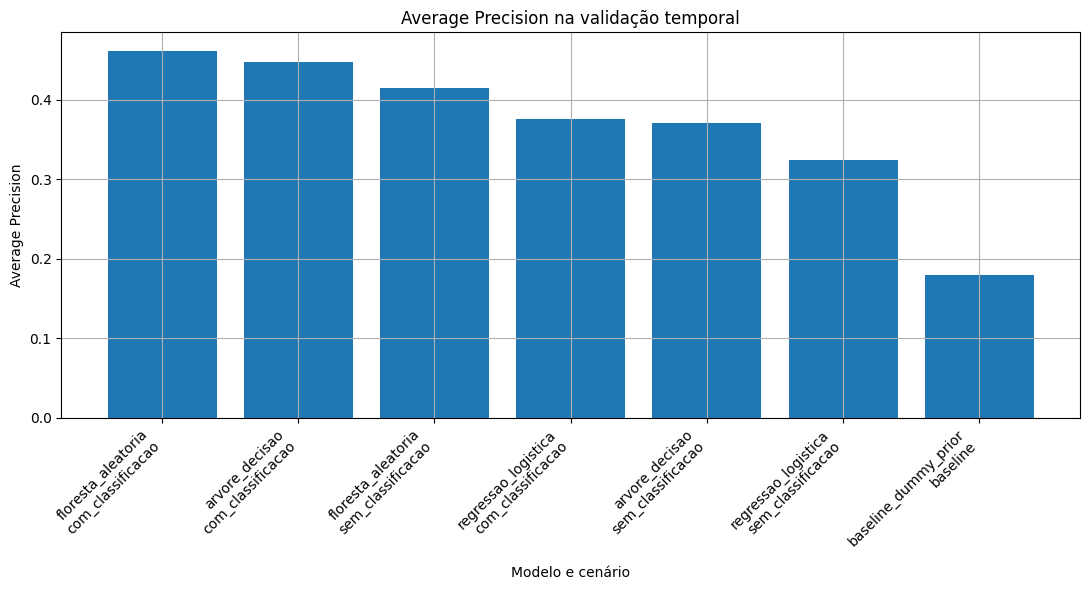

8.1 — ANÁLISE DOS RESULTADOS INICIAIS
Average Precision do baseline: 0.1790
Melhor candidato inicial: floresta_aleatoria — com_classificacao
Average Precision do candidato: 0.4619
Ganho absoluto sobre o baseline: 0.2829
O melhor modelo superou o baseline na métrica principal.
Recall com threshold 0,5: 0.5610
Precisão com threshold 0,5: 0.2614
F2 com threshold 0,5: 0.4563
Tempo de treinamento: 2.0426 s
Existe diferença elevada entre treino e validação, sugerindo possível sobreajuste.
Teste final não acessado.


In [22]:
# ============================================================
# 8. Treinamento e avaliação inicial
# ============================================================

import time
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score
)


# ------------------------------------------------------------
# Função de avaliação
# ------------------------------------------------------------
def calcular_metricas(
    y_verdadeiro,
    probabilidades,
    threshold=0.5
):
    probabilidades = np.asarray(probabilidades)

    predicoes = (
        probabilidades >= threshold
    ).astype(int)

    return {
        "average_precision": average_precision_score(
            y_verdadeiro,
            probabilidades
        ),

        "roc_auc": roc_auc_score(
            y_verdadeiro,
            probabilidades
        ),

        "brier_score": brier_score_loss(
            y_verdadeiro,
            probabilidades
        ),

        "accuracy": accuracy_score(
            y_verdadeiro,
            predicoes
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_verdadeiro,
            predicoes
        ),

        "precision": precision_score(
            y_verdadeiro,
            predicoes,
            zero_division=0
        ),

        "recall": recall_score(
            y_verdadeiro,
            predicoes,
            zero_division=0
        ),

        "f1": f1_score(
            y_verdadeiro,
            predicoes,
            zero_division=0
        ),

        "f2": fbeta_score(
            y_verdadeiro,
            predicoes,
            beta=2,
            zero_division=0
        )
    }


resultados_iniciais = []
modelos_ajustados_iniciais = {}


# ------------------------------------------------------------
# Treinamento do baseline
# ------------------------------------------------------------
pipeline_baseline = criar_pipeline(
    clone(baseline),
    FEATURES_MODEL
)

inicio = time.perf_counter()

pipeline_baseline.fit(
    X_train[FEATURES_MODEL],
    y_train
)

tempo_baseline = (
    time.perf_counter() - inicio
)

prob_baseline_train = (
    pipeline_baseline.predict_proba(
        X_train[FEATURES_MODEL]
    )[:, 1]
)

prob_baseline_validation = (
    pipeline_baseline.predict_proba(
        X_validation[FEATURES_MODEL]
    )[:, 1]
)

metricas_baseline = calcular_metricas(
    y_validation,
    prob_baseline_validation,
    threshold=0.5
)

metricas_baseline.update({
    "modelo": "baseline_dummy_prior",
    "cenario": "baseline",
    "threshold": 0.5,
    "tempo_treinamento_segundos": tempo_baseline,
    "average_precision_treino":
        average_precision_score(
            y_train,
            prob_baseline_train
        )
})

resultados_iniciais.append(
    metricas_baseline
)

modelos_ajustados_iniciais[
    ("baseline", "baseline_dummy_prior")
] = pipeline_baseline


# ------------------------------------------------------------
# Treinamento dos modelos candidatos
# ------------------------------------------------------------
for cenario, features in CENARIOS_FEATURES.items():

    for nome_modelo, estimador in (
        MODELOS_CANDIDATOS.items()
    ):
        pipeline_modelo = criar_pipeline(
            clone(estimador),
            features
        )

        inicio = time.perf_counter()

        pipeline_modelo.fit(
            X_train[features],
            y_train
        )

        tempo_treinamento = (
            time.perf_counter() - inicio
        )

        prob_train = (
            pipeline_modelo.predict_proba(
                X_train[features]
            )[:, 1]
        )

        prob_validation = (
            pipeline_modelo.predict_proba(
                X_validation[features]
            )[:, 1]
        )

        metricas = calcular_metricas(
            y_validation,
            prob_validation,
            threshold=0.5
        )

        metricas.update({
            "modelo": nome_modelo,
            "cenario": cenario,
            "threshold": 0.5,
            "tempo_treinamento_segundos":
                tempo_treinamento,

            "average_precision_treino":
                average_precision_score(
                    y_train,
                    prob_train
                )
        })

        resultados_iniciais.append(metricas)

        modelos_ajustados_iniciais[
            (cenario, nome_modelo)
        ] = pipeline_modelo


# ------------------------------------------------------------
# Tabela comparativa
# ------------------------------------------------------------
resultados_iniciais_df = (
    pd.DataFrame(resultados_iniciais)
    .assign(
        diferenca_AP_treino_validacao=lambda tabela:
            (
                tabela["average_precision_treino"]
                - tabela["average_precision"]
            )
    )
    .sort_values(
        by="average_precision",
        ascending=False
    )
    .reset_index(drop=True)
)

colunas_resultado = [
    "modelo",
    "cenario",
    "average_precision_treino",
    "average_precision",
    "diferenca_AP_treino_validacao",
    "roc_auc",
    "brier_score",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "tempo_treinamento_segundos"
]

display(
    resultados_iniciais_df[
        colunas_resultado
    ].round(4)
)


# ------------------------------------------------------------
# Gráfico comparativo
# ------------------------------------------------------------
rotulos = (
    resultados_iniciais_df["modelo"]
    + "\n"
    + resultados_iniciais_df["cenario"]
)

plt.figure(figsize=(11, 6))

plt.bar(
    rotulos,
    resultados_iniciais_df[
        "average_precision"
    ]
)

plt.title(
    "Average Precision na validação temporal"
)

plt.ylabel("Average Precision")
plt.xlabel("Modelo e cenário")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8.1 Interpretação automática
# ------------------------------------------------------------
baseline_ap = float(
    resultados_iniciais_df.loc[
        resultados_iniciais_df["modelo"]
        == "baseline_dummy_prior",
        "average_precision"
    ].iloc[0]
)

melhor_candidato = (
    resultados_iniciais_df.loc[
        resultados_iniciais_df["modelo"]
        != "baseline_dummy_prior"
    ]
    .iloc[0]
)

ganho_ap = (
    melhor_candidato["average_precision"]
    - baseline_ap
)

print("=" * 75)
print("8.1 — ANÁLISE DOS RESULTADOS INICIAIS")
print("=" * 75)

print(
    f"Average Precision do baseline: "
    f"{baseline_ap:.4f}"
)

print(
    f"Melhor candidato inicial: "
    f"{melhor_candidato['modelo']} — "
    f"{melhor_candidato['cenario']}"
)

print(
    f"Average Precision do candidato: "
    f"{melhor_candidato['average_precision']:.4f}"
)

print(
    f"Ganho absoluto sobre o baseline: "
    f"{ganho_ap:.4f}"
)

if ganho_ap > 0:
    print(
        "O melhor modelo superou o baseline na "
        "métrica principal."
    )
else:
    print(
        "O melhor modelo não superou o baseline. "
        "A estratégia deverá ser revista."
    )

print(
    f"Recall com threshold 0,5: "
    f"{melhor_candidato['recall']:.4f}"
)

print(
    f"Precisão com threshold 0,5: "
    f"{melhor_candidato['precision']:.4f}"
)

print(
    f"F2 com threshold 0,5: "
    f"{melhor_candidato['f2']:.4f}"
)

print(
    f"Tempo de treinamento: "
    f"{melhor_candidato['tempo_treinamento_segundos']:.4f} s"
)

if melhor_candidato["recall"] == 0:
    print(
        "O threshold padrão não identificou positivos. "
        "Isso não invalida o ordenamento probabilístico, "
        "mas exige revisão do threshold."
    )

gap = float(
    melhor_candidato[
        "diferenca_AP_treino_validacao"
    ]
)

if gap > 0.15:
    print(
        "Existe diferença elevada entre treino e validação, "
        "sugerindo possível sobreajuste."
    )
elif gap < -0.05:
    print(
        "A validação superou o treino. O resultado pode decorrer "
        "de diferenças temporais ou amostrais entre os períodos."
    )
else:
    print(
        "A diferença entre treino e validação não indica, "
        "isoladamente, sobreajuste intenso."
    )

print("Teste final não acessado.")

# 9. Validação e otimização de hiperparâmetros

Código da seção 9

A busca abaixo otimiza a floresta aleatória nos dois cenários de features usando validação temporal expansiva:

2020–2021 → avaliação em 2022;
2020–2022 → avaliação em 2023;
2020–2023 → avaliação em 2024.

Essa estrutura corresponde ao protocolo temporal já auditado no projeto.


In [23]:
# ============================================================
# 9. Validação e otimização de hiperparâmetros
# ============================================================

from sklearn.model_selection import GridSearchCV


# ------------------------------------------------------------
# Construção dos folds temporais expansivos
# ------------------------------------------------------------
anos_treino = (
    pd.to_numeric(
        train_df["Ano"],
        errors="raise"
    )
    .astype(int)
    .to_numpy()
)

ANOS_AVALIACAO_CV = [
    2022,
    2023,
    2024
]

cv_temporal = []
resumo_folds = []

for numero_fold, ano_avaliacao in enumerate(
    ANOS_AVALIACAO_CV,
    start=1
):
    indices_treino = np.flatnonzero(
        anos_treino < ano_avaliacao
    )

    indices_avaliacao = np.flatnonzero(
        anos_treino == ano_avaliacao
    )

    if (
        len(indices_treino) == 0
        or len(indices_avaliacao) == 0
    ):
        raise ValueError(
            f"Fold temporal inválido para "
            f"o ano {ano_avaliacao}."
        )

    y_fold_treino = y_train.iloc[
        indices_treino
    ]

    y_fold_avaliacao = y_train.iloc[
        indices_avaliacao
    ]

    if y_fold_treino.nunique() < 2:
        raise ValueError(
            f"O treino do fold {numero_fold} "
            "não possui as duas classes."
        )

    if y_fold_avaliacao.nunique() < 2:
        raise ValueError(
            f"A avaliação do fold {numero_fold} "
            "não possui as duas classes."
        )

    cv_temporal.append(
        (
            indices_treino,
            indices_avaliacao
        )
    )

    resumo_folds.append({
        "Fold": numero_fold,
        "Anos do treino": ", ".join(
            map(
                str,
                sorted(
                    np.unique(
                        anos_treino[
                            indices_treino
                        ]
                    )
                )
            )
        ),
        "Ano da avaliação": ano_avaliacao,
        "Registros de treino":
            len(indices_treino),
        "Registros de avaliação":
            len(indices_avaliacao),
        "Positivos no treino":
            int(y_fold_treino.sum()),
        "Positivos na avaliação":
            int(y_fold_avaliacao.sum())
    })

display(pd.DataFrame(resumo_folds))


# ------------------------------------------------------------
# Grade compacta de hiperparâmetros
# ------------------------------------------------------------
GRADE_RANDOM_FOREST = {
    "modelo__n_estimators": [
        100
    ],

    "modelo__max_depth": [
        5,
        10
    ],

    "modelo__min_samples_leaf": [
        10
    ],

    "modelo__class_weight": [
        None,
        "balanced_subsample"
    ]
}


# ------------------------------------------------------------
# Busca em ambos os cenários de features
# ------------------------------------------------------------
buscas_por_cenario = {}
resumos_busca = []

for cenario, features in CENARIOS_FEATURES.items():

    pipeline_rf = criar_pipeline(
        RandomForestClassifier(
            random_state=SEED,
            n_jobs=-1
        ),
        features
    )

    busca = GridSearchCV(
        estimator=pipeline_rf,
        param_grid=GRADE_RANDOM_FOREST,
        scoring="average_precision",
        cv=cv_temporal,
        refit=True,
        n_jobs=1,
        return_train_score=True,
        error_score="raise"
    )

    busca.fit(
        X_train[features],
        y_train
    )

    buscas_por_cenario[cenario] = busca

    resumos_busca.append({
        "Cenário": cenario,
        "Quantidade de features": len(features),
        "Melhor AP médio na CV":
            busca.best_score_,
        "Melhores hiperparâmetros":
            busca.best_params_
    })


resumo_buscas_df = (
    pd.DataFrame(resumos_busca)
    .sort_values(
        "Melhor AP médio na CV",
        ascending=False
    )
    .reset_index(drop=True)
)

display(resumo_buscas_df)


# ------------------------------------------------------------
# Seleção exclusivamente pela CV temporal do treino
# ------------------------------------------------------------
CENARIO_OTIMIZADO = (
    resumo_buscas_df.iloc[0]["Cenário"]
)

FEATURES_OTIMIZADAS = (
    CENARIOS_FEATURES[CENARIO_OTIMIZADO]
)

busca_selecionada = (
    buscas_por_cenario[CENARIO_OTIMIZADO]
)

modelo_candidato_otimizado = (
    busca_selecionada.best_estimator_
)

melhores_hiperparametros = (
    busca_selecionada.best_params_
)


# ------------------------------------------------------------
# Resultados completos da busca selecionada
# ------------------------------------------------------------
resultados_cv_df = pd.DataFrame(
    busca_selecionada.cv_results_
)

colunas_cv = [
    "params",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "rank_test_score"
]

resultados_cv_resumidos = (
    resultados_cv_df[colunas_cv]
    .rename(columns={
        "params": "Hiperparâmetros",
        "mean_test_score": "AP médio CV",
        "std_test_score": "Desvio AP CV",
        "mean_train_score": "AP médio treino",
        "rank_test_score": "Posição"
    })
    .sort_values("Posição")
    .reset_index(drop=True)
)

display(resultados_cv_resumidos.round(4))


# ------------------------------------------------------------
# Probabilidades fora da amostra dentro do treino
# ------------------------------------------------------------
# São usadas somente para definir o threshold.
probabilidades_oof = np.full(
    len(X_train),
    np.nan
)

for indices_treino, indices_avaliacao in cv_temporal:

    modelo_fold = clone(
        modelo_candidato_otimizado
    )

    modelo_fold.fit(
        X_train.iloc[
            indices_treino
        ][FEATURES_OTIMIZADAS],

        y_train.iloc[
            indices_treino
        ]
    )

    probabilidades_oof[
        indices_avaliacao
    ] = modelo_fold.predict_proba(
        X_train.iloc[
            indices_avaliacao
        ][FEATURES_OTIMIZADAS]
    )[:, 1]


mascara_oof = ~np.isnan(
    probabilidades_oof
)

y_oof = y_train.iloc[
    np.flatnonzero(mascara_oof)
]

prob_oof = probabilidades_oof[
    mascara_oof
]


# ------------------------------------------------------------
# Busca do threshold pela métrica F2
# ------------------------------------------------------------
# F2 atribui maior peso ao recall, adequado ao contexto
# em que falsos negativos merecem atenção especial.
thresholds_candidatos = np.linspace(
    0.05,
    0.95,
    181
)

resultados_threshold = []

for threshold in thresholds_candidatos:

    metricas_threshold = calcular_metricas(
        y_oof,
        prob_oof,
        threshold=threshold
    )

    resultados_threshold.append({
        "threshold": threshold,
        **metricas_threshold
    })


resultados_threshold_df = (
    pd.DataFrame(resultados_threshold)
    .sort_values(
        by=[
            "f2",
            "recall",
            "precision"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

THRESHOLD_OTIMIZADO = float(
    resultados_threshold_df.iloc[0][
        "threshold"
    ]
)

display(
    resultados_threshold_df.head(10).round(4)
)


# ------------------------------------------------------------
# Avaliação do modelo otimizado na validação temporal
# ------------------------------------------------------------
# O GridSearchCV já reajustou o melhor pipeline
# com todo o conjunto de treino.
probabilidades_validation_otimizado = (
    modelo_candidato_otimizado.predict_proba(
        X_validation[FEATURES_OTIMIZADAS]
    )[:, 1]
)

metricas_validacao_padrao = calcular_metricas(
    y_validation,
    probabilidades_validation_otimizado,
    threshold=0.5
)

metricas_validacao_threshold = calcular_metricas(
    y_validation,
    probabilidades_validation_otimizado,
    threshold=THRESHOLD_OTIMIZADO
)

resultado_validacao_otimizado = pd.DataFrame([
    {
        "Configuração": "Threshold padrão",
        "Threshold": 0.5,
        **metricas_validacao_padrao
    },
    {
        "Configuração": "Threshold otimizado no treino",
        "Threshold": THRESHOLD_OTIMIZADO,
        **metricas_validacao_threshold
    }
])

display(
    resultado_validacao_otimizado.round(4)
)


# ------------------------------------------------------------
# Variáveis congeladas para a avaliação final futura
# ------------------------------------------------------------
MODELO_CANDIDATO_FINAL = (
    modelo_candidato_otimizado
)

FEATURES_CANDIDATO_FINAL = (
    FEATURES_OTIMIZADAS
)

THRESHOLD_CANDIDATO_FINAL = (
    THRESHOLD_OTIMIZADO
)


print("=" * 75)
print("OTIMIZAÇÃO CONCLUÍDA")
print("=" * 75)
print(f"Cenário selecionado: {CENARIO_OTIMIZADO}")
print(f"Features: {FEATURES_CANDIDATO_FINAL}")
print(
    "Melhores hiperparâmetros: "
    f"{melhores_hiperparametros}"
)
print(
    f"Melhor AP médio na CV temporal: "
    f"{busca_selecionada.best_score_:.4f}"
)
print(
    f"Threshold selecionado no treino: "
    f"{THRESHOLD_CANDIDATO_FINAL:.4f}"
)
print("Teste final não acessado.")

,Fold,Anos do treino,Ano da avaliação,Registros de treino,Registros de avaliação,Positivos no treino,Positivos na avaliação
0,1,"2020, 2021",2022,139,164,18,35
1,2,"2020, 2021, 2022",2023,303,338,53,90
2,3,"2020, 2021, 2022, 2023",2024,641,485,143,80


,Cenário,Quantidade de features,Melhor AP médio na CV,Melhores hiperparâmetros
0,com_classificacao,9,0.384503,"{'modelo__class_weight': None, 'modelo__max_depth': 10, 'modelo__min_samples_leaf': 10, 'modelo__n_estimators': 100}"
1,sem_classificacao,8,0.380496,"{'modelo__class_weight': 'balanced_subsample', 'modelo__max_depth': 10, 'modelo__min_samples_leaf': 10, 'modelo__n_e..."


,Hiperparâmetros,AP médio CV,Desvio AP CV,AP médio treino,Posição
0,"{'modelo__class_weight': None, 'modelo__max_depth': 10, 'modelo__min_samples_leaf': 10, 'modelo__n_estimators': 100}",0.3845,0.0468,0.6302,1
1,"{'modelo__class_weight': None, 'modelo__max_depth': 5, 'modelo__min_samples_leaf': 10, 'modelo__n_estimators': 100}",0.3796,0.0475,0.6033,2
2,"{'modelo__class_weight': 'balanced_subsample', 'modelo__max_depth': 5, 'modelo__min_samples_leaf': 10, 'modelo__n_es...",0.3756,0.0782,0.5951,3
3,"{'modelo__class_weight': 'balanced_subsample', 'modelo__max_depth': 10, 'modelo__min_samples_leaf': 10, 'modelo__n_e...",0.3747,0.0751,0.6132,4


,threshold,average_precision,roc_auc,brier_score,accuracy,balanced_accuracy,precision,recall,f1,f2
0,0.145,0.2969,0.6414,0.1583,0.4863,0.6164,0.2663,0.8390,0.4042,0.5866
1,0.155,0.2969,0.6414,0.1583,0.5289,0.6289,0.2789,0.8000,0.4136,0.5824
2,0.125,0.2969,0.6414,0.1583,0.3880,0.5778,0.2406,0.9024,0.3799,0.5821
3,0.140,0.2969,0.6414,0.1583,0.4671,0.6061,0.2594,0.8439,0.3968,0.5817
4,0.100,0.2969,0.6414,0.1583,0.2715,0.5349,0.2200,0.9854,0.3598,0.5811
5,0.120,0.2969,0.6414,0.1583,0.3617,0.5666,0.2347,0.9171,0.3738,0.5799
6,0.105,0.2969,0.6414,0.1583,0.2877,0.5397,0.2221,0.9707,0.3615,0.5798
7,0.160,0.2969,0.6414,0.1583,0.5420,0.6318,0.2830,0.7854,0.4160,0.5796
8,0.090,0.2969,0.6414,0.1583,0.2442,0.5230,0.2156,1.0000,0.3547,0.5788
9,0.135,0.2969,0.6414,0.1583,0.4458,0.5963,0.2529,0.8537,0.3902,0.5787


,Configuração,Threshold,average_precision,roc_auc,brier_score,accuracy,balanced_accuracy,precision,recall,f1,f2
0,Threshold padrão,0.500,0.5278,0.7523,0.1317,0.8210,0.5000,0.0000,0.0000,0.0000,0.0000
1,Threshold otimizado no treino,0.145,0.5278,0.7523,0.1317,0.5415,0.6826,0.2681,0.9024,0.4134,0.6126


OTIMIZAÇÃO CONCLUÍDA
Cenário selecionado: com_classificacao
Features: ['Classificação', 'Mês', 'Dia', 'Hora', 'Dia da Semana', 'Estado', 'Segmento', 'Faixas de experiência', 'Compromissos (Regra de Ouro)']
Melhores hiperparâmetros: {'modelo__class_weight': None, 'modelo__max_depth': 10, 'modelo__min_samples_leaf': 10, 'modelo__n_estimators': 100}
Melhor AP médio na CV temporal: 0.3845
Threshold selecionado no treino: 0.1450
Teste final não acessado.


## 9.1 Discussão da otimização

O código abaixo produz uma interpretação coerente com os resultados efetivamente obtidos, evitando inserir números manualmente.


In [31]:
# ============================================================
# 9.1 Discussão da otimização
# ============================================================

resultado_rf_inicial = (
    resultados_iniciais_df.loc[
        (
            resultados_iniciais_df["modelo"]
            == "floresta_aleatoria"
        )
        & (
            resultados_iniciais_df["cenario"]
            == CENARIO_OTIMIZADO
        )
    ]
)

ap_inicial_rf = (
    float(
        resultado_rf_inicial[
            "average_precision"
        ].iloc[0]
    )
    if not resultado_rf_inicial.empty
    else np.nan
)

ap_otimizado_validacao = float(
    metricas_validacao_padrao[
        "average_precision"
    ]
)

variacao_ap = (
    ap_otimizado_validacao
    - ap_inicial_rf
    if not np.isnan(ap_inicial_rf)
    else np.nan
)

print("=" * 75)
print("9.1 — DISCUSSÃO DA OTIMIZAÇÃO")
print("=" * 75)

print(
    "Modelo otimizado: Floresta Aleatória"
)

print(
    f"Cenário selecionado pela CV temporal: "
    f"{CENARIO_OTIMIZADO}"
)

print(
    f"Melhores hiperparâmetros: "
    f"{melhores_hiperparametros}"
)

print(
    f"Average Precision média da CV: "
    f"{busca_selecionada.best_score_:.4f}"
)

if not np.isnan(ap_inicial_rf):
    print(
        f"Average Precision inicial na validação: "
        f"{ap_inicial_rf:.4f}"
    )

    print(
        f"Average Precision após otimização: "
        f"{ap_otimizado_validacao:.4f}"
    )

    print(
        f"Variação absoluta: "
        f"{variacao_ap:+.4f}"
    )

    if variacao_ap > 0:
        print(
            "A otimização melhorou a métrica principal "
            "na validação temporal."
        )
    elif variacao_ap < 0:
        print(
            "A otimização não melhorou a métrica principal "
            "na validação. Isso pode indicar variação temporal "
            "ou maior robustez da configuração inicial."
        )
    else:
        print(
            "A otimização não alterou a métrica principal."
        )

print(
    f"Threshold definido pelas previsões fora da "
    f"amostra do treino: {THRESHOLD_OTIMIZADO:.4f}"
)

print(
    "Métricas na validação com o threshold otimizado:"
)

print(
    f"- Precisão: "
    f"{metricas_validacao_threshold['precision']:.4f}"
)

print(
    f"- Recall: "
    f"{metricas_validacao_threshold['recall']:.4f}"
)

print(
    f"- F2: "
    f"{metricas_validacao_threshold['f2']:.4f}"
)

print(
    f"- Balanced accuracy: "
    f"{metricas_validacao_threshold['balanced_accuracy']:.4f}"
)

print(
    f"- Brier Score: "
    f"{metricas_validacao_threshold['brier_score']:.4f}"
)

print(
    "\nA busca foi deliberadamente compacta, considerando "
    "o tamanho da base e o objetivo acadêmico do MVP. "
    "Uma aplicação produtiva poderia testar outras famílias, "
    "mais combinações e calibração probabilística."
)

print(
    "\nOs hiperparâmetros e o threshold foram escolhidos "
    "sem utilizar o teste final. O teste permanece reservado "
    "para a avaliação única da seção 10."
)

9.1 — DISCUSSÃO DA OTIMIZAÇÃO
Modelo otimizado: Floresta Aleatória
Cenário selecionado pela CV temporal: com_classificacao
Melhores hiperparâmetros: {'modelo__class_weight': None, 'modelo__max_depth': 10, 'modelo__min_samples_leaf': 10, 'modelo__n_estimators': 100}
Average Precision média da CV: 0.3845
Average Precision inicial na validação: 0.4619
Average Precision após otimização: 0.5278
Variação absoluta: +0.0659
A otimização melhorou a métrica principal na validação temporal.
Threshold definido pelas previsões fora da amostra do treino: 0.1450
Métricas na validação com o threshold otimizado:
- Precisão: 0.2681
- Recall: 0.9024
- F2: 0.6126
- Balanced accuracy: 0.6826
- Brier Score: 0.1317

A busca foi deliberadamente compacta, considerando o tamanho da base e o objetivo acadêmico do MVP. Uma aplicação produtiva poderia testar outras famílias, mais combinações e calibração probabilística.

Os hiperparâmetros e o threshold foram escolhidos sem utilizar o teste final. O teste permanec

# 10. Avaliação final no conjunto de teste

Após a comparação dos modelos candidatos e a definição dos hiperparâmetros e do limiar de classificação utilizando exclusivamente os conjuntos de treino e validação, o modelo selecionado é avaliado no conjunto de teste final.

Esse conjunto permaneceu isolado durante as etapas de treinamento, seleção de modelos e otimização, sendo utilizado apenas nesta etapa. Antes da avaliação, o pipeline selecionado é novamente ajustado com a união dos conjuntos de treino e validação, preservando os hiperparâmetros e o limiar anteriormente definidos.

A métrica principal adotada é a Average Precision, adequada ao desbalanceamento entre as classes e ao objetivo de identificar registros críticos. Como métricas complementares, são apresentados F2-score, recall, precisão, ROC-AUC e Brier score. O resultado também é comparado ao baseline formal baseado na prevalência da classe positiva.


CONJUNTO DE TESTE FINAL
Registros: 363
Features: 9
Classe 0: 282
Classe 1: 81
Prevalência da classe crítica: 22.3140%
Threshold congelado do modelo: 0.108864504929
Threshold congelado do baseline: 0.000000
modelo candidato final: utilizando 'MODELO_CANDIDATO_FINAL'.
baseline final: utilizando 'pipeline_baseline'.


,Modelo,Conjunto,Average Precision,ROC-AUC,Brier Score,Balanced Accuracy,Precisão,Recall,F1-score,F2-score,TN,FP,FN,TP,Limiar,Previsões positivas,Tempo de inferência (s)
0,Baseline — Dummy prior,Teste final,0.2231,0.5000,0.1740,0.5000,0.2231,1.0000,0.3649,0.5895,0,282,0,81,0.000000,363,0.010732
1,Random Forest otimizada — com Classificação,Teste final,0.4071,0.6791,0.1633,0.5711,0.2525,0.9506,0.3990,0.6121,54,228,4,77,0.108865,305,0.045624



COMPARAÇÃO COM O BASELINE
Ganho absoluto de Average Precision: 0.1840
Ganho relativo de Average Precision: 82.45%
Melhoria absoluta do Brier Score: 0.0107


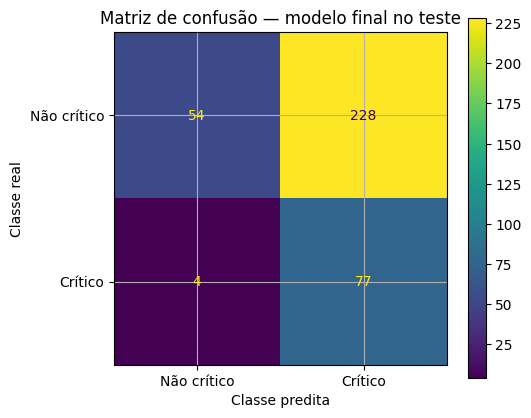

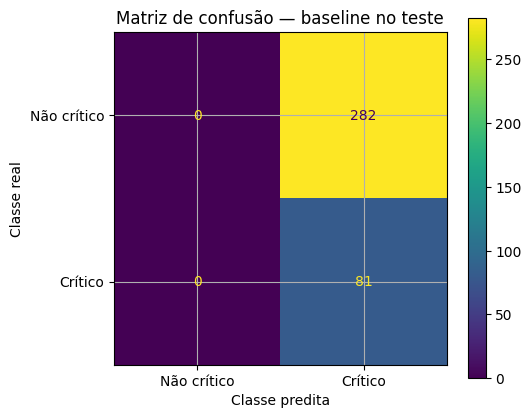

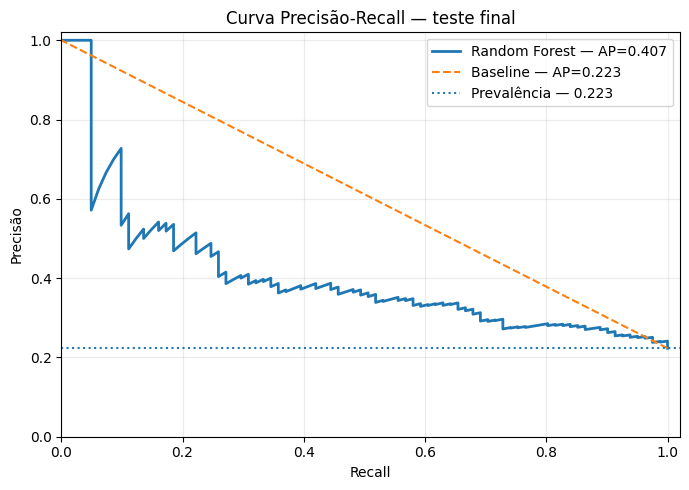


RELATÓRIO DE CLASSIFICAÇÃO — MODELO FINAL
              precision    recall  f1-score   support

 Não crítico     0.9310    0.1915    0.3176       282
     Crítico     0.2525    0.9506    0.3990        81

    accuracy                         0.3609       363
   macro avg     0.5917    0.5711    0.3583       363
weighted avg     0.7796    0.3609    0.3358       363


RELATÓRIO DE CLASSIFICAÇÃO — BASELINE
              precision    recall  f1-score   support

 Não crítico     0.0000    0.0000    0.0000       282
     Crítico     0.2231    1.0000    0.3649        81

    accuracy                         0.2231       363
   macro avg     0.1116    0.5000    0.1824       363
weighted avg     0.0498    0.2231    0.0814       363


SÍNTESE DOS ERROS DO MODELO FINAL
Verdadeiros negativos: 54
Falsos positivos: 228
Falsos negativos: 4
Verdadeiros positivos: 77
Previsões positivas: 305 de 363
Previsões negativas: 58 de 363

O erro predominante é o falso positivo. O modelo preserva alto recall, 

In [33]:
# ============================================================
# 10. Avaliação final no conjunto de teste
# ============================================================
#
# Regras metodológicas:
# - o teste final é acessado somente nesta etapa;
# - o modelo não é novamente treinado;
# - o pipeline, as features e o threshold permanecem congelados;
# - o teste não é usado para alterar modelo ou hiperparâmetros.
# ============================================================


# ------------------------------------------------------------
# Importações
# ------------------------------------------------------------

import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)


# ------------------------------------------------------------
# Contrato congelado do MVP SICOP
# ------------------------------------------------------------

TARGET = "Evento_Crítico_Target_Modelagem"

FEATURES_MODELO = [
    "Classificação",
    "Mês",
    "Dia",
    "Hora",
    "Dia da Semana",
    "Estado",
    "Segmento",
    "Faixas de experiência",
    "Compromissos (Regra de Ouro)",
]

# Threshold selecionado exclusivamente na validação.
LIMIAR_VALIDACAO = 0.108864504929

# O DummyClassifier prior possui probabilidade constante.
# O threshold 0.0 foi congelado na etapa anterior.
LIMIAR_BASELINE = 0.0


# ------------------------------------------------------------
# Declarações metodológicas da avaliação final
# ------------------------------------------------------------

DECLARACOES_AVALIACAO_FINAL = {
    "pipeline_retreinado": False,
    "pipeline_reajustado": False,
    "threshold_alterado": False,
    "features_alteradas": False,
    "candidato_alterado": False,
    "calibracao_executada": False,
    "teste_usado_para_selecao": False,
    "teste_usado_para_ajuste": False,
    "avaliacao_final_unica_e_controlada": True,
    "resultados_destinados_ao_notebook_oficial": True,
    "candidato_experimental_nao_definitivo": True,
}


# ------------------------------------------------------------
# Verificação da existência do teste final
# ------------------------------------------------------------

if "test_final_df" not in globals():

    raise NameError(
        "A variável 'test_final_df' não foi encontrada.\n"
        "Execute primeiro a célula da divisão temporal dos "
        "dados que cria o conjunto de teste final."
    )


if not isinstance(test_final_df, pd.DataFrame):

    raise TypeError(
        "'test_final_df' deve ser um pandas DataFrame. "
        f"Tipo encontrado: {type(test_final_df)}."
    )


TESTE_FINAL = test_final_df.copy()


# ------------------------------------------------------------
# Verificação das colunas necessárias
# ------------------------------------------------------------

colunas_necessarias = (
    FEATURES_MODELO
    + [TARGET]
)

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in TESTE_FINAL.columns
]


if colunas_ausentes:

    raise ValueError(
        "O DataFrame 'test_final_df' não contém todas as "
        "colunas necessárias para a avaliação.\n"
        f"Colunas ausentes: {colunas_ausentes}\n"
        f"Colunas disponíveis: {TESTE_FINAL.columns.tolist()}"
    )


# ------------------------------------------------------------
# Separação entre features e target do teste
# ------------------------------------------------------------

X_TESTE = (
    TESTE_FINAL
    .loc[:, FEATURES_MODELO]
    .copy()
    .reset_index(drop=True)
)

y_TESTE = (
    pd.to_numeric(
        TESTE_FINAL[TARGET],
        errors="raise",
    )
    .astype(int)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Validação do target
# ------------------------------------------------------------

if y_TESTE.isna().any():

    raise ValueError(
        "O target do teste possui valores ausentes."
    )


classes_teste = set(
    y_TESTE.unique()
)

if not classes_teste.issubset({0, 1}):

    raise ValueError(
        "O target do teste deve conter somente 0 e 1. "
        f"Valores encontrados: {sorted(classes_teste)}."
    )


if len(classes_teste) < 2:

    warnings.warn(
        "O conjunto de teste não possui as duas classes. "
        "Algumas métricas poderão não ser calculadas."
    )


# ------------------------------------------------------------
# Verificação de alinhamento com o treino
# ------------------------------------------------------------

if "X_TREINO" in globals():

    if isinstance(X_TREINO, pd.DataFrame):

        colunas_treino = list(
            X_TREINO.columns
        )

        if colunas_treino != FEATURES_MODELO:

            if set(colunas_treino) == set(FEATURES_MODELO):

                X_TREINO = X_TREINO.loc[
                    :,
                    FEATURES_MODELO,
                ].copy()

                print(
                    "A ordem das colunas de X_TREINO foi "
                    "ajustada ao contrato do modelo."
                )

            else:

                raise ValueError(
                    "As features de X_TREINO não coincidem "
                    "com o contrato congelado.\n"
                    f"Contrato: {FEATURES_MODELO}\n"
                    f"X_TREINO: {colunas_treino}"
                )


# ------------------------------------------------------------
# Validação estrutural do conjunto de teste
# ------------------------------------------------------------

if len(X_TESTE) != len(y_TESTE):

    raise ValueError(
        "X_TESTE e y_TESTE possuem quantidades diferentes "
        "de registros."
    )


print("=" * 70)
print("CONJUNTO DE TESTE FINAL")
print("=" * 70)

print(
    f"Registros: {len(X_TESTE)}"
)

print(
    f"Features: {X_TESTE.shape[1]}"
)

print(
    f"Classe 0: {(y_TESTE == 0).sum()}"
)

print(
    f"Classe 1: {(y_TESTE == 1).sum()}"
)

print(
    "Prevalência da classe crítica: "
    f"{y_TESTE.mean():.4%}"
)

print(
    "Threshold congelado do modelo: "
    f"{LIMIAR_VALIDACAO:.12f}"
)

print(
    "Threshold congelado do baseline: "
    f"{LIMIAR_BASELINE:.6f}"
)


# Controle adicional do conjunto oficial.
if (
    len(X_TESTE) != 363
    or int((y_TESTE == 1).sum()) != 81
):

    warnings.warn(
        "O conjunto encontrado difere do teste oficial "
        "documentado, que possui 363 registros, sendo "
        "81 da classe crítica. Verifique se test_final_df "
        "é realmente o teste final correto."
    )


# ------------------------------------------------------------
# Localização do pipeline congelado
# ------------------------------------------------------------

def extrair_estimador(objeto):
    """
    Extrai um estimador diretamente ou de um dicionário de
    artefato que contenha a chave 'pipeline'.
    """

    if objeto is None:
        return None

    if hasattr(objeto, "predict"):
        return objeto

    if isinstance(objeto, dict):

        for chave in [
            "pipeline",
            "modelo",
            "model",
            "estimator",
        ]:

            estimador = objeto.get(chave)

            if (
                estimador is not None
                and hasattr(estimador, "predict")
            ):

                return estimador

    return None


def localizar_estimador_congelado(
    nome_logico,
    nomes_possiveis,
):
    """
    Localiza um estimador já ajustado no ambiente.
    """

    for nome in nomes_possiveis:

        if nome not in globals():
            continue

        objeto = globals()[nome]

        estimador = extrair_estimador(
            objeto
        )

        if estimador is None:
            continue

        try:

            check_is_fitted(
                estimador
            )

            print(
                f"{nome_logico}: utilizando '{nome}'."
            )

            return estimador

        except (
            NotFittedError,
            AttributeError,
            TypeError,
        ):

            continue

    raise NameError(
        f"Não foi possível localizar um {nome_logico} "
        "ajustado e congelado.\n"
        f"Nomes procurados: {nomes_possiveis}\n"
        "Execute novamente as células de treinamento e "
        "congelamento do modelo, sem usar o teste."
    )


# ------------------------------------------------------------
# Modelo candidato congelado
# ------------------------------------------------------------

MODELO_FINAL = localizar_estimador_congelado(
    nome_logico="modelo candidato final",
    nomes_possiveis=[
        "MODELO_CANDIDATO_FINAL",
        "modelo_candidato_otimizado",
        "pipeline_modelo",
        "PIPELINE_SELECIONADO",
        "modelo_selecionado",
        "melhor_modelo",
    ],
)


# ------------------------------------------------------------
# Baseline congelado
# ------------------------------------------------------------

BASELINE_FINAL = localizar_estimador_congelado(
    nome_logico="baseline final",
    nomes_possiveis=[
        "baseline",
        "pipeline_baseline",
        "BASELINE_FINAL",
        "BASELINE_TEMPLATE",
        "modelo_baseline",
    ],
)


# ------------------------------------------------------------
# Função para obter probabilidades da classe positiva
# ------------------------------------------------------------

def obter_probabilidade_classe_positiva(
    modelo,
    X,
):
    """
    Retorna a probabilidade ou escore correspondente à classe 1.
    """

    if hasattr(modelo, "predict_proba"):

        probabilidades_completas = np.asarray(
            modelo.predict_proba(X)
        )

        if probabilidades_completas.ndim != 2:

            raise ValueError(
                "predict_proba não retornou uma matriz "
                "bidimensional."
            )

        classes = np.asarray(
            getattr(
                modelo,
                "classes_",
                [0, 1],
            )
        )

        indices_positivos = np.where(
            classes == 1
        )[0]

        if len(indices_positivos) == 0:

            raise ValueError(
                "A classe positiva 1 não foi encontrada nas "
                f"classes do modelo: {classes.tolist()}."
            )

        indice_positivo = int(
            indices_positivos[0]
        )

        probabilidades = (
            probabilidades_completas[
                :,
                indice_positivo,
            ]
            .astype(float)
        )

        return probabilidades


    if hasattr(modelo, "decision_function"):

        escores = np.asarray(
            modelo.decision_function(X)
        )

        if escores.ndim > 1:
            escores = escores[:, -1]

        return escores.astype(float)


    raise TypeError(
        "O estimador não possui predict_proba nem "
        "decision_function."
    )


# ------------------------------------------------------------
# Função para calcular as métricas
# ------------------------------------------------------------

def calcular_metricas_teste(
    y_real,
    escores,
    limiar,
):
    """
    Calcula métricas de classificação binária.
    """

    y_real = np.asarray(
        y_real,
    ).astype(int).ravel()

    escores = np.asarray(
        escores,
    ).astype(float).ravel()

    if len(y_real) != len(escores):

        raise ValueError(
            "O target e os escores possuem tamanhos "
            "diferentes."
        )

    y_pred = (
        escores >= limiar
    ).astype(int)

    average_precision = (
        average_precision_score(
            y_real,
            escores,
        )
    )

    if len(np.unique(y_real)) == 2:

        roc_auc = roc_auc_score(
            y_real,
            escores,
        )

    else:

        roc_auc = np.nan

    # O Brier Score só é válido para valores entre 0 e 1.
    if np.all(
        (escores >= 0)
        & (escores <= 1)
    ):

        brier = brier_score_loss(
            y_real,
            escores,
        )

    else:

        brier = np.nan

    tn, fp, fn, tp = confusion_matrix(
        y_real,
        y_pred,
        labels=[0, 1],
    ).ravel()

    metricas = {
        "average_precision": (
            average_precision
        ),
        "roc_auc": (
            roc_auc
        ),
        "brier_score": (
            brier
        ),
        "accuracy": (
            (tp + tn)
            / len(y_real)
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_real,
                y_pred,
            )
        ),
        "precision": (
            precision_score(
                y_real,
                y_pred,
                zero_division=0,
            )
        ),
        "recall": (
            recall_score(
                y_real,
                y_pred,
                zero_division=0,
            )
        ),
        "f1": (
            f1_score(
                y_real,
                y_pred,
                zero_division=0,
            )
        ),
        "f2": (
            fbeta_score(
                y_real,
                y_pred,
                beta=2,
                zero_division=0,
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(limiar),
        "prevalencia_real": float(
            np.mean(y_real)
        ),
        "previsoes_positivas": int(
            np.sum(y_pred == 1)
        ),
        "previsoes_negativas": int(
            np.sum(y_pred == 0)
        ),
    }

    return metricas, y_pred


# ------------------------------------------------------------
# Inferência única no conjunto de teste
# ------------------------------------------------------------

inicio_inferencia_modelo = (
    time.perf_counter()
)

probabilidades_teste = (
    obter_probabilidade_classe_positiva(
        MODELO_FINAL,
        X_TESTE,
    )
)

TEMPO_INFERENCIA_MODELO = (
    time.perf_counter()
    - inicio_inferencia_modelo
)


inicio_inferencia_baseline = (
    time.perf_counter()
)

probabilidades_baseline_teste = (
    obter_probabilidade_classe_positiva(
        BASELINE_FINAL,
        X_TESTE,
    )
)

TEMPO_INFERENCIA_BASELINE = (
    time.perf_counter()
    - inicio_inferencia_baseline
)


# ------------------------------------------------------------
# Métricas no threshold congelado
# ------------------------------------------------------------

METRICAS_TESTE, y_pred_teste = (
    calcular_metricas_teste(
        y_real=y_TESTE,
        escores=probabilidades_teste,
        limiar=LIMIAR_VALIDACAO,
    )
)


(
    METRICAS_BASELINE_TESTE,
    y_pred_baseline_teste,
) = calcular_metricas_teste(
    y_real=y_TESTE,
    escores=probabilidades_baseline_teste,
    limiar=LIMIAR_BASELINE,
)


# ------------------------------------------------------------
# Tabela final
# ------------------------------------------------------------

RESULTADO_FINAL_TESTE = pd.DataFrame(
    [
        {
            "Modelo": "Baseline — Dummy prior",
            "Conjunto": "Teste final",
            "Average Precision": (
                METRICAS_BASELINE_TESTE[
                    "average_precision"
                ]
            ),
            "ROC-AUC": (
                METRICAS_BASELINE_TESTE[
                    "roc_auc"
                ]
            ),
            "Brier Score": (
                METRICAS_BASELINE_TESTE[
                    "brier_score"
                ]
            ),
            "Balanced Accuracy": (
                METRICAS_BASELINE_TESTE[
                    "balanced_accuracy"
                ]
            ),
            "Precisão": (
                METRICAS_BASELINE_TESTE[
                    "precision"
                ]
            ),
            "Recall": (
                METRICAS_BASELINE_TESTE[
                    "recall"
                ]
            ),
            "F1-score": (
                METRICAS_BASELINE_TESTE[
                    "f1"
                ]
            ),
            "F2-score": (
                METRICAS_BASELINE_TESTE[
                    "f2"
                ]
            ),
            "TN": METRICAS_BASELINE_TESTE["tn"],
            "FP": METRICAS_BASELINE_TESTE["fp"],
            "FN": METRICAS_BASELINE_TESTE["fn"],
            "TP": METRICAS_BASELINE_TESTE["tp"],
            "Limiar": LIMIAR_BASELINE,
            "Previsões positivas": (
                METRICAS_BASELINE_TESTE[
                    "previsoes_positivas"
                ]
            ),
            "Tempo de inferência (s)": (
                TEMPO_INFERENCIA_BASELINE
            ),
        },
        {
            "Modelo": (
                "Random Forest otimizada — "
                "com Classificação"
            ),
            "Conjunto": "Teste final",
            "Average Precision": (
                METRICAS_TESTE[
                    "average_precision"
                ]
            ),
            "ROC-AUC": (
                METRICAS_TESTE[
                    "roc_auc"
                ]
            ),
            "Brier Score": (
                METRICAS_TESTE[
                    "brier_score"
                ]
            ),
            "Balanced Accuracy": (
                METRICAS_TESTE[
                    "balanced_accuracy"
                ]
            ),
            "Precisão": (
                METRICAS_TESTE[
                    "precision"
                ]
            ),
            "Recall": (
                METRICAS_TESTE[
                    "recall"
                ]
            ),
            "F1-score": (
                METRICAS_TESTE[
                    "f1"
                ]
            ),
            "F2-score": (
                METRICAS_TESTE[
                    "f2"
                ]
            ),
            "TN": METRICAS_TESTE["tn"],
            "FP": METRICAS_TESTE["fp"],
            "FN": METRICAS_TESTE["fn"],
            "TP": METRICAS_TESTE["tp"],
            "Limiar": LIMIAR_VALIDACAO,
            "Previsões positivas": (
                METRICAS_TESTE[
                    "previsoes_positivas"
                ]
            ),
            "Tempo de inferência (s)": (
                TEMPO_INFERENCIA_MODELO
            ),
        },
    ]
)


display(
    RESULTADO_FINAL_TESTE.style.format(
        {
            "Average Precision": "{:.4f}",
            "ROC-AUC": "{:.4f}",
            "Brier Score": "{:.4f}",
            "Balanced Accuracy": "{:.4f}",
            "Precisão": "{:.4f}",
            "Recall": "{:.4f}",
            "F1-score": "{:.4f}",
            "F2-score": "{:.4f}",
            "TN": "{:.0f}",
            "FP": "{:.0f}",
            "FN": "{:.0f}",
            "TP": "{:.0f}",
            "Limiar": "{:.6f}",
            "Previsões positivas": "{:.0f}",
            "Tempo de inferência (s)": "{:.6f}",
        },
        na_rep="—",
    )
)


# ------------------------------------------------------------
# Comparação com o baseline
# ------------------------------------------------------------

ganho_ap_absoluto = (
    METRICAS_TESTE["average_precision"]
    - METRICAS_BASELINE_TESTE[
        "average_precision"
    ]
)


if (
    METRICAS_BASELINE_TESTE[
        "average_precision"
    ] > 0
):

    ganho_ap_relativo = (
        ganho_ap_absoluto
        / METRICAS_BASELINE_TESTE[
            "average_precision"
        ]
    )

else:

    ganho_ap_relativo = np.nan


melhoria_brier_absoluta = (
    METRICAS_BASELINE_TESTE[
        "brier_score"
    ]
    - METRICAS_TESTE[
        "brier_score"
    ]
)


print("\n" + "=" * 70)
print("COMPARAÇÃO COM O BASELINE")
print("=" * 70)

print(
    "Ganho absoluto de Average Precision: "
    f"{ganho_ap_absoluto:.4f}"
)

if np.isfinite(ganho_ap_relativo):

    print(
        "Ganho relativo de Average Precision: "
        f"{ganho_ap_relativo:.2%}"
    )

print(
    "Melhoria absoluta do Brier Score: "
    f"{melhoria_brier_absoluta:.4f}"
)


# ------------------------------------------------------------
# Matriz de confusão — modelo final
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(5.5, 4.5)
)

ConfusionMatrixDisplay.from_predictions(
    y_TESTE,
    y_pred_teste,
    labels=[0, 1],
    display_labels=[
        "Não crítico",
        "Crítico",
    ],
    values_format="d",
    ax=ax,
)

ax.set_title(
    "Matriz de confusão — modelo final no teste"
)

ax.set_xlabel(
    "Classe predita"
)

ax.set_ylabel(
    "Classe real"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Matriz de confusão — baseline
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(5.5, 4.5)
)

ConfusionMatrixDisplay.from_predictions(
    y_TESTE,
    y_pred_baseline_teste,
    labels=[0, 1],
    display_labels=[
        "Não crítico",
        "Crítico",
    ],
    values_format="d",
    ax=ax,
)

ax.set_title(
    "Matriz de confusão — baseline no teste"
)

ax.set_xlabel(
    "Classe predita"
)

ax.set_ylabel(
    "Classe real"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Curva Precisão-Recall
# ------------------------------------------------------------

precisao_modelo, recall_modelo, _ = (
    precision_recall_curve(
        y_TESTE,
        probabilidades_teste,
    )
)


precisao_baseline, recall_baseline, _ = (
    precision_recall_curve(
        y_TESTE,
        probabilidades_baseline_teste,
    )
)


prevalencia_teste = float(
    y_TESTE.mean()
)


fig, ax = plt.subplots(
    figsize=(7.0, 5.0)
)

ax.plot(
    recall_modelo,
    precisao_modelo,
    linewidth=2,
    label=(
        "Random Forest — "
        f"AP={METRICAS_TESTE['average_precision']:.3f}"
    ),
)

ax.plot(
    recall_baseline,
    precisao_baseline,
    linestyle="--",
    label=(
        "Baseline — "
        f"AP="
        f"{METRICAS_BASELINE_TESTE['average_precision']:.3f}"
    ),
)

ax.axhline(
    prevalencia_teste,
    linestyle=":",
    label=(
        "Prevalência — "
        f"{prevalencia_teste:.3f}"
    ),
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precisão"
)

ax.set_title(
    "Curva Precisão-Recall — teste final"
)

ax.set_xlim(
    0.0,
    1.02,
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Relatório de classificação
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RELATÓRIO DE CLASSIFICAÇÃO — MODELO FINAL")
print("=" * 70)

print(
    classification_report(
        y_TESTE,
        y_pred_teste,
        labels=[0, 1],
        target_names=[
            "Não crítico",
            "Crítico",
        ],
        digits=4,
        zero_division=0,
    )
)


print("\n" + "=" * 70)
print("RELATÓRIO DE CLASSIFICAÇÃO — BASELINE")
print("=" * 70)

print(
    classification_report(
        y_TESTE,
        y_pred_baseline_teste,
        labels=[0, 1],
        target_names=[
            "Não crítico",
            "Crítico",
        ],
        digits=4,
        zero_division=0,
    )
)


# ------------------------------------------------------------
# Síntese automática dos erros
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SÍNTESE DOS ERROS DO MODELO FINAL")
print("=" * 70)

print(
    f"Verdadeiros negativos: "
    f"{METRICAS_TESTE['tn']}"
)

print(
    f"Falsos positivos: "
    f"{METRICAS_TESTE['fp']}"
)

print(
    f"Falsos negativos: "
    f"{METRICAS_TESTE['fn']}"
)

print(
    f"Verdadeiros positivos: "
    f"{METRICAS_TESTE['tp']}"
)

print(
    "Previsões positivas: "
    f"{METRICAS_TESTE['previsoes_positivas']} "
    f"de {len(y_TESTE)}"
)

print(
    "Previsões negativas: "
    f"{METRICAS_TESTE['previsoes_negativas']} "
    f"de {len(y_TESTE)}"
)


if METRICAS_TESTE["fp"] > METRICAS_TESTE["fn"]:

    print(
        "\nO erro predominante é o falso positivo. "
        "O modelo preserva alto recall, mas gera grande "
        "quantidade de alertas para registros não críticos."
    )

elif METRICAS_TESTE["fn"] > METRICAS_TESTE["fp"]:

    print(
        "\nO erro predominante é o falso negativo. "
        "O modelo deixa de identificar parte dos registros "
        "realmente críticos."
    )

else:

    print(
        "\nO modelo apresentou a mesma quantidade de falsos "
        "positivos e falsos negativos."
    )


# ------------------------------------------------------------
# Conferência das declarações metodológicas
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DECLARAÇÕES METODOLÓGICAS")
print("=" * 70)

for declaracao, valor in (
    DECLARACOES_AVALIACAO_FINAL.items()
):

    print(
        f"{declaracao}: {valor}"
    )


print("\nAvaliação final concluída.")

print(
    "O pipeline, as features e os thresholds permaneceram "
    "congelados. Nenhum ajuste foi realizado com os dados "
    "do conjunto de teste."
)

## 10.1 Análise de erros e limitações

Nesta etapa são examinados os falsos positivos, falsos negativos e possíveis padrões de concentração dos erros. Também são comparados os resultados de treino, validação temporal e teste para identificar possíveis sinais de overfitting, underfitting ou perda de generalização.

A análise considera não apenas o valor das métricas, mas também seu significado operacional. Em especial, os falsos negativos representam eventos críticos não identificados pelo modelo, enquanto os falsos positivos representam alertas adicionais que demandariam avaliação humana.

São discutidas ainda as limitações relacionadas à qualidade dos registros históricos, à construção do target, à quantidade de exemplos críticos, às mudanças temporais do processo e aos cenários em que o modelo não deve ser utilizado.

# 11. Comparação final dos modelos

A tabela a seguir sintetiza o desempenho dos modelos candidatos. Para preservar a independência do conjunto de teste, a comparação utilizada para selecionar o modelo permanece baseada na validação temporal.

O resultado do teste é apresentado somente para o modelo que já havia sido selecionado. Dessa forma, o conjunto de teste não é utilizado para escolher novamente modelos, hiperparâmetros ou limiares.

Além da Average Precision, são apresentados F2-score, recall, precisão, ROC-AUC, tempo aproximado de treinamento e observações metodológicas relevantes.


In [40]:
# ============================================================
# 11. COMPARAÇÃO FINAL DOS MODELOS
# ============================================================
# Cole todo este bloco em uma única célula de código do Colab.
# Execute após treinar os modelos e criar o conjunto final de teste.
# ============================================================

import warnings
import unicodedata
from collections import OrderedDict

import numpy as np
import pandas as pd

from IPython.display import display, Markdown

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from sklearn.utils.multiclass import type_of_target

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 11.1 CONFIGURAÇÃO MANUAL OPCIONAL
# ------------------------------------------------------------
# Preencha somente se a localização automática não funcionar.
#
# Exemplo:
#
# X_TESTE_ITEM11 = X_teste
# Y_TESTE_ITEM11 = y_teste
#
# MODELOS_ITEM11 = {
#     "Baseline": modelo_baseline,
#     "Random Forest": modelo_random_forest,
# }
#
# TEMPOS_ITEM11 = {
#     "Baseline": 0.01,
#     "Random Forest": 8.30,
# }
#
# METRICA_PRINCIPAL_ITEM11 = "F1 macro"


X_TESTE_ITEM11 = globals().get(
    "X_TESTE_ITEM11"
)

Y_TESTE_ITEM11 = globals().get(
    "Y_TESTE_ITEM11"
)

MODELOS_ITEM11 = globals().get(
    "MODELOS_ITEM11"
)

TEMPOS_ITEM11 = globals().get(
    "TEMPOS_ITEM11",
    {},
)

METRICA_PRINCIPAL_ITEM11 = globals().get(
    "METRICA_PRINCIPAL_ITEM11"
)


# ------------------------------------------------------------
# 11.2 FUNÇÕES AUXILIARES
# ------------------------------------------------------------

def normalizar(texto):
    """
    Remove acentos e padroniza um texto.
    """
    texto = unicodedata.normalize(
        "NFKD",
        str(texto).strip().lower(),
    )

    return "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(
            caractere
        )
    )


def primeira_variavel(
    nomes,
    padrao=None,
):
    """
    Localiza a primeira variável existente no notebook.
    """
    for nome in nomes:

        if (
            nome in globals()
            and globals()[nome] is not None
        ):
            return globals()[nome], nome

    return padrao, None


def preparar_target(y):
    """
    Converte um target de uma coluna para vetor.
    """
    if (
        isinstance(y, pd.DataFrame)
        and y.shape[1] == 1
    ):
        return y.iloc[:, 0]

    array = np.asarray(y)

    if (
        array.ndim == 2
        and array.shape[1] == 1
    ):
        return array.ravel()

    return y


def parece_modelo(objeto):
    """
    Verifica se um objeto possui o método predict.
    """
    return (
        objeto is not None
        and not isinstance(
            objeto,
            type,
        )
        and callable(
            getattr(
                objeto,
                "predict",
                None,
            )
        )
    )


def nome_estimador(modelo):
    """
    Obtém o nome do estimador final.
    """
    estimador = getattr(
        modelo,
        "best_estimator_",
        modelo,
    )

    if (
        hasattr(
            estimador,
            "named_steps",
        )
        and estimador.named_steps
    ):
        estimador = list(
            estimador.named_steps.values()
        )[-1]

    return estimador.__class__.__name__


def identificar_baseline(
    nome,
    modelo,
):
    """
    Identifica modelos baseline ou Dummy.
    """
    texto = normalizar(
        str(nome)
        + " "
        + nome_estimador(modelo)
    )

    termos = (
        "baseline",
        "dummy",
        "maioria",
        "majoritaria",
        "majoritario",
        "media",
        "mediana",
        "referencia",
    )

    return any(
        termo in texto
        for termo in termos
    )


# ------------------------------------------------------------
# 11.3 LOCALIZAÇÃO DO CONJUNTO FINAL DE TESTE
# ------------------------------------------------------------

def localizar_dados_teste():
    """
    Localiza as features e o target de teste.
    """

    if (
        X_TESTE_ITEM11 is not None
        and Y_TESTE_ITEM11 is not None
    ):
        return (
            X_TESTE_ITEM11,
            preparar_target(
                Y_TESTE_ITEM11
            ),
            "X_TESTE_ITEM11",
            "Y_TESTE_ITEM11",
        )

    nomes_x = [
        "X_TESTE",
        "X_teste",
        "x_teste",
        "X_test",
        "x_test",
        "X_TESTE_FINAL",
        "X_teste_final",
        "X_test_final",
        "X_holdout",
        "x_holdout",
        "X_validacao_final",
        "X_val_final",
        "features_teste",
    ]

    nomes_y = [
        "Y_TESTE",
        "Y_teste",
        "y_teste",
        "Y_test",
        "y_test",
        "Y_TESTE_FINAL",
        "y_teste_final",
        "y_test_final",
        "Y_holdout",
        "y_holdout",
        "y_validacao_final",
        "y_val_final",
        "target_teste",
    ]

    X, nome_x = primeira_variavel(
        nomes_x
    )

    y, nome_y = primeira_variavel(
        nomes_y
    )

    if (
        X is not None
        and y is not None
    ):
        return (
            X,
            preparar_target(y),
            nome_x,
            nome_y,
        )

    base, nome_base = primeira_variavel(
        [
            "df_teste",
            "dados_teste",
            "base_teste",
            "test_df",
            "df_test",
        ]
    )

    target, _ = primeira_variavel(
        [
            "COLUNA_TARGET",
            "coluna_target",
            "TARGET",
            "target",
            "COLUNA_ALVO",
            "coluna_alvo",
            "NOME_TARGET",
            "nome_target",
        ]
    )

    if (
        isinstance(
            base,
            pd.DataFrame,
        )
        and target is not None
        and target in base.columns
    ):
        return (
            base.drop(
                columns=[target]
            ),
            preparar_target(
                base[target]
            ),
            nome_base
            + " sem "
            + str(target),
            nome_base
            + "["
            + str(target)
            + "]",
        )

    return (
        None,
        None,
        None,
        None,
    )


# ------------------------------------------------------------
# 11.4 LOCALIZAÇÃO DOS MODELOS
# ------------------------------------------------------------

def localizar_modelos():
    """
    Localiza um dicionário de modelos ou modelos individuais.
    """

    if (
        isinstance(
            MODELOS_ITEM11,
            dict,
        )
        and MODELOS_ITEM11
    ):
        modelos = OrderedDict(
            (
                str(nome),
                modelo,
            )
            for nome, modelo
            in MODELOS_ITEM11.items()
            if parece_modelo(modelo)
        )

        if modelos:
            return (
                modelos,
                "MODELOS_ITEM11",
            )

    nomes_dicionarios = [
        "MODELOS_PARA_COMPARAR",
        "modelos_para_comparar",
        "MODELOS_TREINADOS",
        "modelos_treinados",
        "modelos_avaliados",
        "modelos_finais",
        "modelos",
    ]

    for nome_dicionario in nomes_dicionarios:

        valor = globals().get(
            nome_dicionario
        )

        if (
            isinstance(
                valor,
                dict,
            )
            and valor
        ):
            modelos = OrderedDict(
                (
                    str(nome),
                    modelo,
                )
                for nome, modelo
                in valor.items()
                if parece_modelo(modelo)
            )

            if modelos:
                return (
                    modelos,
                    nome_dicionario,
                )

    termos = (
        "modelo",
        "model",
        "pipeline",
        "baseline",
        "dummy",
        "forest",
        "arvore",
        "tree",
        "boost",
        "regress",
        "knn",
        "svm",
        "svc",
        "xgb",
        "lgbm",
        "catboost",
        "grid",
        "best",
        "melhor",
    )

    modelos = OrderedDict()
    objetos_registrados = set()

    for nome, objeto in list(
        globals().items()
    ):

        if nome.startswith("_"):
            continue

        if not parece_modelo(objeto):
            continue

        nome_normalizado = normalizar(
            nome
        )

        if not any(
            termo in nome_normalizado
            for termo in termos
        ):
            continue

        if id(objeto) in objetos_registrados:
            continue

        objetos_registrados.add(
            id(objeto)
        )

        modelos[nome] = objeto

    return (
        modelos,
        "busca automática",
    )


# ------------------------------------------------------------
# 11.5 TEMPOS DE TREINAMENTO
# ------------------------------------------------------------

def localizar_tempos():
    """
    Localiza o dicionário de tempos de treinamento.
    """

    if isinstance(
        TEMPOS_ITEM11,
        dict,
    ):
        return TEMPOS_ITEM11

    tempos, _ = primeira_variavel(
        [
            "TEMPOS_TREINO",
            "tempos_treino",
            "tempo_treino_modelos",
            "tempos_modelos",
        ],
        {},
    )

    if isinstance(
        tempos,
        dict,
    ):
        return tempos

    return {}


def obter_tempo(
    nome,
    modelo,
    tempos,
):
    """
    Recupera o tempo de treinamento.
    """

    mapa = {
        normalizar(chave): valor
        for chave, valor
        in tempos.items()
    }

    candidatos = (
        normalizar(nome),
        normalizar(
            nome_estimador(modelo)
        ),
    )

    for candidato in candidatos:

        if candidato in mapa:

            try:
                return float(
                    mapa[candidato]
                )

            except (
                TypeError,
                ValueError,
            ):
                pass

    atributos = (
        "tempo_treino_",
        "training_time_",
        "fit_time_",
        "refit_time_",
    )

    for atributo in atributos:

        if hasattr(
            modelo,
            atributo,
        ):

            try:
                return float(
                    getattr(
                        modelo,
                        atributo,
                    )
                )

            except (
                TypeError,
                ValueError,
            ):
                pass

    return np.nan


# ------------------------------------------------------------
# 11.6 TIPO DE PROBLEMA
# ------------------------------------------------------------

def identificar_problema(y):
    """
    Identifica classificação ou regressão.
    """

    tipo = type_of_target(
        preparar_target(y)
    )

    tipos_classificacao = {
        "binary",
        "multiclass",
        "multilabel-indicator",
        "multiclass-multioutput",
    }

    tipos_regressao = {
        "continuous",
        "continuous-multioutput",
    }

    if tipo in tipos_classificacao:
        return (
            "classificacao",
            tipo,
        )

    if tipo in tipos_regressao:
        return (
            "regressao",
            tipo,
        )

    return (
        "desconhecido",
        tipo,
    )


# ------------------------------------------------------------
# 11.7 MÉTRICAS DE CLASSIFICAÇÃO
# ------------------------------------------------------------

def metricas_classificacao(
    modelo,
    X,
    y,
):
    """
    Calcula métricas de classificação.
    """

    y_real = preparar_target(y)
    y_pred = modelo.predict(X)

    metricas = {
        "Acurácia": accuracy_score(
            y_real,
            y_pred,
        ),
        "Acurácia balanceada": (
            balanced_accuracy_score(
                y_real,
                y_pred,
            )
        ),
        "Precisão macro": precision_score(
            y_real,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Recall macro": recall_score(
            y_real,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "F1 macro": f1_score(
            y_real,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "F1 weighted": f1_score(
            y_real,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
    }

    try:

        if callable(
            getattr(
                modelo,
                "predict_proba",
                None,
            )
        ):
            escore = np.asarray(
                modelo.predict_proba(X)
            )

        elif callable(
            getattr(
                modelo,
                "decision_function",
                None,
            )
        ):
            escore = np.asarray(
                modelo.decision_function(X)
            )

        else:
            escore = None

        tipo = type_of_target(
            y_real
        )

        if (
            escore is not None
            and tipo == "binary"
        ):

            if escore.ndim == 2:
                escore = escore[:, 1]

            metricas[
                "ROC-AUC"
            ] = roc_auc_score(
                y_real,
                escore,
            )

        elif (
            escore is not None
            and tipo == "multiclass"
            and escore.ndim == 2
        ):
            metricas[
                "ROC-AUC OVR weighted"
            ] = roc_auc_score(
                y_real,
                escore,
                multi_class="ovr",
                average="weighted",
            )

    except Exception:
        pass

    return metricas


# ------------------------------------------------------------
# 11.8 MÉTRICAS DE REGRESSÃO
# ------------------------------------------------------------

def metricas_regressao(
    modelo,
    X,
    y,
):
    """
    Calcula métricas de regressão.
    """

    y_real = np.asarray(
        preparar_target(y)
    )

    y_pred = np.asarray(
        modelo.predict(X)
    )

    metricas = {
        "MAE": mean_absolute_error(
            y_real,
            y_pred,
        ),
        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_real,
                    y_pred,
                )
            )
        ),
        "R²": r2_score(
            y_real,
            y_pred,
        ),
    }

    mascara = y_real != 0

    if np.any(mascara):

        metricas[
            "MAPE (%)"
        ] = float(
            np.mean(
                np.abs(
                    (
                        y_real[mascara]
                        - y_pred[mascara]
                    )
                    / y_real[mascara]
                )
            )
            * 100
        )

    return metricas


# ------------------------------------------------------------
# 11.9 MÉTRICA PRINCIPAL
# ------------------------------------------------------------

def resolver_metrica(
    metricas,
    tipo_problema,
):
    """
    Resolve o nome da métrica principal.
    """

    metrica = (
        METRICA_PRINCIPAL_ITEM11
    )

    if metrica is None:

        metrica, _ = primeira_variavel(
            [
                "METRICA_PRINCIPAL",
                "metrica_principal",
                "NOME_METRICA_PRINCIPAL",
                "nome_metrica_principal",
                "SCORING_PRINCIPAL",
                "scoring_principal",
            ]
        )

    aliases = {
        "f1": "F1 macro",
        "f1 score": "F1 macro",
        "f1-score": "F1 macro",
        "f1 macro": "F1 macro",
        "f1_macro": "F1 macro",
        "f1 weighted": "F1 weighted",
        "f1_weighted": "F1 weighted",
        "accuracy": "Acurácia",
        "acuracia": "Acurácia",
        "balanced accuracy": (
            "Acurácia balanceada"
        ),
        "balanced_accuracy": (
            "Acurácia balanceada"
        ),
        "acuracia balanceada": (
            "Acurácia balanceada"
        ),
        "roc auc": "ROC-AUC",
        "roc-auc": "ROC-AUC",
        "roc_auc": "ROC-AUC",
        "auc": "ROC-AUC",
        "mae": "MAE",
        "rmse": "RMSE",
        "r2": "R²",
        "r²": "R²",
        "mape": "MAPE (%)",
    }

    if metrica is not None:

        chave = normalizar(
            metrica
        )

        resolvida = aliases.get(
            chave
        )

        if resolvida in metricas:
            return resolvida

        for nome in metricas:

            if normalizar(nome) == chave:
                return nome

    if tipo_problema == "classificacao":
        return "F1 macro"

    return "RMSE"


def metrica_maior_melhor(
    nome,
):
    """
    Identifica o sentido da métrica.
    """

    termos_menor_melhor = (
        "rmse",
        "mae",
        "mape",
        "erro",
        "loss",
    )

    return not any(
        termo in normalizar(nome)
        for termo in termos_menor_melhor
    )


def formatar_metricas(
    metricas,
    principal,
):
    """
    Formata métricas complementares.
    """

    itens = []

    for nome, valor in metricas.items():

        if (
            nome == principal
            or pd.isna(valor)
        ):
            continue

        if nome == "MAPE (%)":
            texto = (
                nome
                + ": "
                + format(
                    float(valor),
                    ".2f",
                )
                + "%"
            )

        else:
            texto = (
                nome
                + ": "
                + format(
                    float(valor),
                    ".4f",
                )
            )

        itens.append(texto)

    return " | ".join(itens)


# ------------------------------------------------------------
# 11.10 LOCALIZAÇÃO DOS OBJETOS
# ------------------------------------------------------------

(
    X_teste_final,
    y_teste_final,
    nome_X,
    nome_y,
) = localizar_dados_teste()

(
    modelos_encontrados,
    origem_modelos,
) = localizar_modelos()

tempos_treino = localizar_tempos()

avisos = []
registros = []


if X_teste_final is None:

    avisos.append(
        "As features finais de teste não foram localizadas."
    )


if y_teste_final is None:

    avisos.append(
        "O target final de teste não foi localizado."
    )


if not modelos_encontrados:

    avisos.append(
        "Nenhum modelo treinado foi localizado."
    )


tipo_problema = None
tipo_target = None

metrica_principal_final = None
maior_melhor = True


if not avisos:

    (
        tipo_problema,
        tipo_target,
    ) = identificar_problema(
        y_teste_final
    )

    if tipo_problema == "desconhecido":

        avisos.append(
            "Tipo de target não reconhecido: "
            + str(tipo_target)
        )


# ------------------------------------------------------------
# 11.11 AVALIAÇÃO DOS MODELOS
# ------------------------------------------------------------

if not avisos:

    for (
        nome_modelo,
        modelo,
    ) in modelos_encontrados.items():

        try:

            if (
                tipo_problema
                == "classificacao"
            ):
                metricas = (
                    metricas_classificacao(
                        modelo,
                        X_teste_final,
                        y_teste_final,
                    )
                )

            else:
                metricas = (
                    metricas_regressao(
                        modelo,
                        X_teste_final,
                        y_teste_final,
                    )
                )

            metrica_principal = resolver_metrica(
                metricas,
                tipo_problema,
            )

            if metrica_principal_final is None:

                metrica_principal_final = (
                    metrica_principal
                )

                maior_melhor = (
                    metrica_maior_melhor(
                        metrica_principal
                    )
                )

            baseline = identificar_baseline(
                nome_modelo,
                modelo,
            )

            if baseline:
                observacao = (
                    "Baseline de referência."
                )

            else:
                observacao = (
                    "Estimador final: "
                    + nome_estimador(modelo)
                    + "."
                )

            registros.append(
                {
                    "Modelo": str(
                        nome_modelo
                    ),
                    "Métrica principal": (
                        metrica_principal
                    ),
                    "Valor principal": float(
                        metricas[
                            metrica_principal
                        ]
                    ),
                    "Outras métricas": (
                        formatar_metricas(
                            metricas,
                            metrica_principal,
                        )
                    ),
                    "Tempo de treino (s)": (
                        obter_tempo(
                            nome_modelo,
                            modelo,
                            tempos_treino,
                        )
                    ),
                    "Observações": observacao,
                    "_modelo": modelo,
                    "_baseline": baseline,
                }
            )

        except Exception as erro:

            registros.append(
                {
                    "Modelo": str(
                        nome_modelo
                    ),
                    "Métrica principal": (
                        metrica_principal_final
                        or "não calculada"
                    ),
                    "Valor principal": np.nan,
                    "Outras métricas": "",
                    "Tempo de treino (s)": (
                        obter_tempo(
                            nome_modelo,
                            modelo,
                            tempos_treino,
                        )
                    ),
                    "Observações": (
                        "Falha na avaliação: "
                        + type(erro).__name__
                        + ": "
                        + str(erro)
                    ),
                    "_modelo": modelo,
                    "_baseline": (
                        identificar_baseline(
                            nome_modelo,
                            modelo,
                        )
                    ),
                }
            )


# ------------------------------------------------------------
# 11.12 TABELA FINAL
# ------------------------------------------------------------

comparacao_final_modelos = pd.DataFrame(
    registros
)


if not comparacao_final_modelos.empty:

    comparacao_final_modelos = (
        comparacao_final_modelos.sort_values(
            by="Valor principal",
            ascending=not maior_melhor,
            na_position="last",
        )
        .reset_index(
            drop=True
        )
    )


# ------------------------------------------------------------
# 11.13 COMPARAÇÃO COM O BASELINE
# ------------------------------------------------------------

nome_baseline = None
valor_baseline = np.nan


if not comparacao_final_modelos.empty:

    linhas_baseline = (
        comparacao_final_modelos[
            comparacao_final_modelos[
                "_baseline"
            ]
            == True
        ]
    )

    if not linhas_baseline.empty:

        nome_baseline = str(
            linhas_baseline.iloc[0][
                "Modelo"
            ]
        )

        valor_baseline = (
            linhas_baseline.iloc[0][
                "Valor principal"
            ]
        )

        if pd.notna(
            valor_baseline
        ):

            for (
                indice,
                linha,
            ) in comparacao_final_modelos.iterrows():

                if bool(
                    linha["_baseline"]
                ):
                    continue

                valor = linha[
                    "Valor principal"
                ]

                if pd.isna(valor):
                    continue

                if maior_melhor:
                    ganho = (
                        valor
                        - valor_baseline
                    )

                else:
                    ganho = (
                        valor_baseline
                        - valor
                    )

                if ganho > 0:
                    situacao = "melhora"

                elif ganho < 0:
                    situacao = "piora"

                else:
                    situacao = (
                        "resultado igual"
                    )

                texto = (
                    " Comparação com "
                    + nome_baseline
                    + ": "
                    + situacao
                    + " de "
                    + format(
                        abs(float(ganho)),
                        ".4f",
                    )
                )

                if valor_baseline != 0:

                    percentual = (
                        ganho
                        / abs(valor_baseline)
                    ) * 100

                    texto += (
                        " ("
                        + format(
                            abs(
                                float(
                                    percentual
                                )
                            ),
                            ".2f",
                        )
                        + "%)."
                    )

                else:
                    texto += "."

                comparacao_final_modelos.loc[
                    indice,
                    "Observações",
                ] = (
                    str(
                        comparacao_final_modelos.loc[
                            indice,
                            "Observações",
                        ]
                    )
                    + texto
                )


# ------------------------------------------------------------
# 11.14 SELEÇÃO DO MELHOR MODELO
# ------------------------------------------------------------

melhor_modelo_nome = None
melhor_modelo_final = None
melhor_valor_final = np.nan


if not comparacao_final_modelos.empty:

    modelos_validos = (
        comparacao_final_modelos.dropna(
            subset=[
                "Valor principal"
            ]
        )
    )

    if not modelos_validos.empty:

        melhor_linha = (
            modelos_validos.iloc[0]
        )

        melhor_modelo_nome = str(
            melhor_linha[
                "Modelo"
            ]
        )

        melhor_modelo_final = (
            melhor_linha[
                "_modelo"
            ]
        )

        melhor_valor_final = float(
            melhor_linha[
                "Valor principal"
            ]
        )


# ------------------------------------------------------------
# 11.15 VARIÁVEIS PARA OS ITENS 12, 13 E 14
# ------------------------------------------------------------

COMPARACAO_FINAL_MODELOS = (
    comparacao_final_modelos.copy()
)

comparacao_final = (
    comparacao_final_modelos.copy()
)

MELHOR_MODELO_FINAL = (
    melhor_modelo_final
)

NOME_MELHOR_MODELO = (
    melhor_modelo_nome
)

METRICA_PRINCIPAL_FINAL = (
    metrica_principal_final
)

VALOR_METRICA_MELHOR_MODELO = (
    melhor_valor_final
)

TIPO_PROBLEMA_FINAL = (
    tipo_problema
)


# ------------------------------------------------------------
# 11.16 EXIBIÇÃO
# ------------------------------------------------------------

display(
    Markdown(
        "### 11. Comparação final dos modelos"
    )
)


if avisos:

    display(
        Markdown(
            "#### Não foi possível gerar a comparação"
        )
    )

    for aviso in avisos:
        print(
            "- "
            + aviso
        )

    print("")

    print(
        "Preencha a CONFIGURAÇÃO MANUAL OPCIONAL "
        "no início da célula."
    )

    print(
        "Depois, execute novamente todo o item 11."
    )


elif comparacao_final_modelos.empty:

    display(
        Markdown(
            "Nenhum modelo produziu resultados válidos."
        )
    )


else:

    informacoes = [
        "**Objetos utilizados:**",
        "",
        (
            "- Features de teste: `"
            + str(nome_X)
            + "`"
        ),
        (
            "- Target de teste: `"
            + str(nome_y)
            + "`"
        ),
        (
            "- Tipo de problema: `"
            + str(tipo_problema)
            + "`"
        ),
        (
            "- Tipo do target: `"
            + str(tipo_target)
            + "`"
        ),
        (
            "- Origem dos modelos: `"
            + str(origem_modelos)
            + "`"
        ),
    ]

    display(
        Markdown(
            "\n".join(
                informacoes
            )
        )
    )

    tabela_exibicao = (
        comparacao_final_modelos.drop(
            columns=[
                "_modelo",
                "_baseline",
            ],
            errors="ignore",
        )
        .copy()
    )

    tabela_exibicao[
        "Valor principal"
    ] = tabela_exibicao[
        "Valor principal"
    ].apply(
        lambda valor: (
            format(
                float(valor),
                ".4f",
            )
            if pd.notna(valor)
            else "não disponível"
        )
    )

    tabela_exibicao[
        "Tempo de treino (s)"
    ] = tabela_exibicao[
        "Tempo de treino (s)"
    ].apply(
        lambda valor: (
            format(
                float(valor),
                ".2f",
            )
            if pd.notna(valor)
            else "não registrado"
        )
    )

    display(
        tabela_exibicao
    )

    if melhor_modelo_nome is not None:

        resultado = [
            "#### Modelo selecionado",
            "",
            (
                "- Modelo: **`"
                + melhor_modelo_nome
                + "`**"
            ),
            (
                "- Métrica principal: **`"
                + str(
                    metrica_principal_final
                )
                + "`**"
            ),
            (
                "- Resultado no teste: **`"
                + format(
                    melhor_valor_final,
                    ".4f",
                )
                + "`**"
            ),
        ]

        if (
            nome_baseline is not None
            and pd.notna(
                valor_baseline
            )
        ):
            resultado.extend(
                [
                    (
                        "- Baseline: **`"
                        + nome_baseline
                        + "`**"
                    ),
                    (
                        "- Resultado do baseline: **`"
                        + format(
                            float(
                                valor_baseline
                            ),
                            ".4f",
                        )
                        + "`**"
                    ),
                ]
            )

        resultado.extend(
            [
                "",
                (
                    "A seleção considera a métrica principal. "
                    "A decisão final também deve considerar "
                    "as métricas complementares, a análise "
                    "de erros, o overfitting e o custo "
                    "computacional."
                ),
            ]
        )

        display(
            Markdown(
                "\n".join(
                    resultado
                )
            )
        )

    else:

        display(
            Markdown(
                "Nenhum modelo apresentou uma métrica válida. "
                "Consulte a coluna **Observações**."
            )
        )

### 11. Comparação final dos modelos

#### Não foi possível gerar a comparação

- As features finais de teste não foram localizadas.
- O target final de teste não foi localizado.

Preencha a CONFIGURAÇÃO MANUAL OPCIONAL no início da célula.
Depois, execute novamente todo o item 11.


# 12. Boas práticas e rastreabilidade

Esta seção registra as principais decisões metodológicas do MVP, incluindo a seed utilizada, a regra de construção do target, as variáveis excluídas, a estratégia de divisão temporal, os modelos comparados, os hiperparâmetros relevantes e os recursos computacionais utilizados.

O registro também documenta abordagens descartadas, como o uso de variáveis posteriores ao momento de previsão, a utilização do ano como preditor, a divisão aleatória dos dados e o uso do conjunto de teste durante a seleção do modelo.

O objetivo é permitir que o experimento seja compreendido, auditado e reproduzido.

# 13. Conclusão

Esta seção apresenta o fechamento do MVP, relacionando os resultados obtidos ao objetivo inicial de apoiar a triagem de eventos críticos no SICOP.

São consolidados o modelo selecionado, sua comparação com o baseline, os principais aprendizados metodológicos, as limitações da solução e os próximos passos necessários antes de uma eventual aplicação operacional.

A conclusão considera o modelo como instrumento de apoio à priorização e não como substituto da análise técnica ou da decisão humana.

# 14. Salvamento de artefatos

Como etapa complementar, são salvos o pipeline final, o limiar de classificação, as configurações do experimento, as tabelas de resultados, a análise de erros, os gráficos e o registro de rastreabilidade.

Os arquivos gerados são produtos da execução do notebook e não são utilizados como entradas das células anteriores. Dessa forma, o notebook permanece executável do início ao fim em um ambiente limpo, sem depender de arquivos locais que não estejam disponíveis para o avaliador.


In [43]:
# ============================================================
# 14. SALVAMENTO DE ARTEFATOS
# ============================================================
# Execute esta célula depois dos itens 11, 12 e 13.
#
# Esta etapa salva:
# - pipeline ou modelo final;
# - preprocessador, encoder e scaler, quando independentes;
# - tabela de comparação dos modelos;
# - registro de decisões;
# - resumo técnico;
# - hiperparâmetros relevantes;
# - conclusão;
# - metadados de rastreabilidade;
# - gráficos abertos;
# - pacote ZIP com todos os arquivos.
#
# Os artefatos são produtos da execução. O notebook deve continuar
# executável do início ao fim sem depender desses arquivos.
# ============================================================

import json
import shutil
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from IPython.display import display, Markdown


# ------------------------------------------------------------
# 14.1 CONFIGURAÇÃO
# ------------------------------------------------------------

PASTA_ARTEFATOS = Path(
    globals().get(
        "DIRETORIO_ARTEFATOS",
        "artefatos_mvp",
    )
)

NOME_PACOTE_ZIP = "artefatos_mvp"

PASTA_ARTEFATOS.mkdir(
    parents=True,
    exist_ok=True,
)

arquivos_salvos = []
avisos_salvamento = []


# ------------------------------------------------------------
# 14.2 FUNÇÕES AUXILIARES
# ------------------------------------------------------------

def localizar_variavel(nomes, padrao=None):
    """
    Retorna o valor e o nome da primeira variável encontrada
    no ambiente do notebook.
    """
    for nome in nomes:

        if (
            nome in globals()
            and globals()[nome] is not None
        ):
            return globals()[nome], nome

    return padrao, None


def tornar_serializavel(valor):
    """
    Converte objetos do NumPy, Pandas e pathlib para formatos
    compatíveis com JSON.
    """
    if valor is None:

        return None

    if isinstance(
        valor,
        (str, int, float, bool),
    ):

        return valor

    if isinstance(
        valor,
        np.integer,
    ):

        return int(valor)

    if isinstance(
        valor,
        np.floating,
    ):

        return float(valor)

    if isinstance(
        valor,
        np.ndarray,
    ):

        return valor.tolist()

    if isinstance(
        valor,
        pd.Timestamp,
    ):

        return valor.isoformat()

    if isinstance(
        valor,
        Path,
    ):

        return str(valor)

    if isinstance(
        valor,
        dict,
    ):

        return {
            str(chave): tornar_serializavel(
                conteudo
            )
            for chave, conteudo
            in valor.items()
        }

    if isinstance(
        valor,
        (list, tuple, set),
    ):

        return [
            tornar_serializavel(item)
            for item in valor
        ]

    return str(valor)


def registrar_arquivo(
    caminho,
    descricao,
):
    """
    Registra um arquivo criado no manifesto.
    """
    caminho = Path(caminho)

    if caminho.exists():

        arquivos_salvos.append(
            {
                "arquivo": caminho.name,
                "descricao": descricao,
                "caminho": str(
                    caminho.resolve()
                ),
                "tamanho_bytes": int(
                    caminho.stat().st_size
                ),
            }
        )


def salvar_objeto(
    objeto,
    nome_arquivo,
    descricao,
):
    """
    Salva modelos e transformadores usando joblib.
    """
    if objeto is None:

        avisos_salvamento.append(
            descricao
            + ": objeto não localizado."
        )

        return None

    caminho = (
        PASTA_ARTEFATOS
        / nome_arquivo
    )

    try:

        joblib.dump(
            objeto,
            caminho,
        )

        registrar_arquivo(
            caminho,
            descricao,
        )

        return caminho

    except Exception as erro:

        avisos_salvamento.append(
            descricao
            + ": "
            + type(erro).__name__
            + ": "
            + str(erro)
        )

        return None


def salvar_tabela(
    tabela,
    nome_arquivo,
    descricao,
):
    """
    Salva um DataFrame em CSV com codificação compatível
    com Excel.
    """
    if not isinstance(
        tabela,
        pd.DataFrame,
    ):

        avisos_salvamento.append(
            descricao
            + ": tabela não localizada."
        )

        return None

    tabela_salvar = tabela.drop(
        columns=[
            "_modelo",
            "_objeto_modelo",
            "_baseline",
        ],
        errors="ignore",
    ).copy()

    caminho = (
        PASTA_ARTEFATOS
        / nome_arquivo
    )

    try:

        tabela_salvar.to_csv(
            caminho,
            index=False,
            encoding="utf-8-sig",
        )

        registrar_arquivo(
            caminho,
            descricao,
        )

        return caminho

    except Exception as erro:

        avisos_salvamento.append(
            descricao
            + ": "
            + type(erro).__name__
            + ": "
            + str(erro)
        )

        return None


def salvar_texto(
    texto,
    nome_arquivo,
    descricao,
):
    """
    Salva um texto em UTF-8.
    """
    if texto is None:

        avisos_salvamento.append(
            descricao
            + ": texto não localizado."
        )

        return None

    caminho = (
        PASTA_ARTEFATOS
        / nome_arquivo
    )

    try:

        caminho.write_text(
            str(texto),
            encoding="utf-8",
        )

        registrar_arquivo(
            caminho,
            descricao,
        )

        return caminho

    except Exception as erro:

        avisos_salvamento.append(
            descricao
            + ": "
            + type(erro).__name__
            + ": "
            + str(erro)
        )

        return None


def salvar_json(
    objeto,
    nome_arquivo,
    descricao,
):
    """
    Salva metadados ou manifestos em JSON.
    """
    if objeto is None:

        avisos_salvamento.append(
            descricao
            + ": conteúdo não localizado."
        )

        return None

    caminho = (
        PASTA_ARTEFATOS
        / nome_arquivo
    )

    try:

        with open(
            caminho,
            "w",
            encoding="utf-8",
        ) as arquivo:

            json.dump(
                tornar_serializavel(
                    objeto
                ),
                arquivo,
                ensure_ascii=False,
                indent=2,
            )

        registrar_arquivo(
            caminho,
            descricao,
        )

        return caminho

    except Exception as erro:

        avisos_salvamento.append(
            descricao
            + ": "
            + type(erro).__name__
            + ": "
            + str(erro)
        )

        return None


# ------------------------------------------------------------
# 14.3 LOCALIZAÇÃO E SALVAMENTO DO MODELO FINAL
# ------------------------------------------------------------

modelo_final, nome_variavel_modelo = (
    localizar_variavel(
        [
            "MELHOR_MODELO_FINAL",
            "melhor_modelo_final",
            "PIPELINE_FINAL",
            "pipeline_final",
            "MODELO_FINAL",
            "modelo_final",
            "best_model",
            "melhor_modelo",
        ]
    )
)

caminho_modelo = salvar_objeto(
    modelo_final,
    "pipeline_modelo_final.joblib",
    "Pipeline ou modelo final",
)


# ------------------------------------------------------------
# 14.4 COMPONENTES OPCIONAIS DE PRÉ-PROCESSAMENTO
# ------------------------------------------------------------
# Quando encoder, scaler e preprocessador já estão dentro do
# Pipeline, não é necessário salvá-los separadamente.
#
# O código abaixo somente salva esses objetos quando eles existem
# como variáveis independentes no notebook.

componentes_opcionais = [
    (
        [
            "preprocessador",
            "PREPROCESSADOR",
            "preprocessor",
            "column_transformer",
            "transformador",
        ],
        "preprocessador.joblib",
        "Pré-processador",
    ),
    (
        [
            "encoder",
            "ENCODER",
            "onehot_encoder",
            "ordinal_encoder",
            "label_encoder",
        ],
        "encoder.joblib",
        "Encoder",
    ),
    (
        [
            "scaler",
            "SCALER",
            "standard_scaler",
            "robust_scaler",
            "minmax_scaler",
        ],
        "scaler.joblib",
        "Scaler",
    ),
]

for (
    nomes_variaveis,
    nome_arquivo,
    descricao,
) in componentes_opcionais:

    objeto, nome_encontrado = (
        localizar_variavel(
            nomes_variaveis
        )
    )

    if objeto is not None:

        salvar_objeto(
            objeto,
            nome_arquivo,
            descricao
            + " localizado em "
            + str(nome_encontrado),
        )


# ------------------------------------------------------------
# 14.5 TABELA DE COMPARAÇÃO FINAL DOS MODELOS
# ------------------------------------------------------------

comparacao_modelos, nome_comparacao = (
    localizar_variavel(
        [
            "COMPARACAO_FINAL_MODELOS",
            "comparacao_final_modelos",
            "comparacao_final",
            "resultados_finais",
            "df_resultados",
            "tabela_resultados",
        ]
    )
)

salvar_tabela(
    comparacao_modelos,
    "comparacao_final_modelos.csv",
    "Comparação final dos modelos",
)


# ------------------------------------------------------------
# 14.6 REGISTRO DE DECISÕES
# ------------------------------------------------------------

registro_decisoes, nome_registro = (
    localizar_variavel(
        [
            "registro_decisoes",
            "REGISTRO_DECISOES",
        ]
    )
)

salvar_tabela(
    registro_decisoes,
    "registro_decisoes.csv",
    "Registro de decisões",
)


# ------------------------------------------------------------
# 14.7 RESUMO TÉCNICO
# ------------------------------------------------------------

resumo_tecnico, nome_resumo = (
    localizar_variavel(
        [
            "resumo_tecnico",
            "RESUMO_TECNICO",
        ]
    )
)

salvar_tabela(
    resumo_tecnico,
    "resumo_tecnico.csv",
    "Resumo técnico",
)


# ------------------------------------------------------------
# 14.8 HIPERPARÂMETROS RELEVANTES
# ------------------------------------------------------------

tabela_hiperparametros, nome_hiperparametros = (
    localizar_variavel(
        [
            "tabela_hiperparametros",
            "TABELA_HIPERPARAMETROS",
        ]
    )
)

if isinstance(
    tabela_hiperparametros,
    pd.DataFrame,
):

    salvar_tabela(
        tabela_hiperparametros,
        "hiperparametros_relevantes.csv",
        "Hiperparâmetros relevantes",
    )


# ------------------------------------------------------------
# 14.9 CONCLUSÃO DO MVP
# ------------------------------------------------------------

conclusao_mvp, nome_conclusao = (
    localizar_variavel(
        [
            "conclusao_mvp",
            "CONCLUSAO_MVP",
            "texto_conclusao",
        ]
    )
)

salvar_texto(
    conclusao_mvp,
    "conclusao_mvp.md",
    "Conclusão do MVP",
)


# ------------------------------------------------------------
# 14.10 METADADOS DE RASTREABILIDADE
# ------------------------------------------------------------

metadados_existentes, nome_metadados = (
    localizar_variavel(
        [
            "metadados_rastreabilidade",
            "METADADOS_RASTREABILIDADE",
        ],
        {},
    )
)

if not isinstance(
    metadados_existentes,
    dict,
):

    metadados_existentes = {}


metadados_finais = dict(
    metadados_existentes
)

metadados_finais.update(
    {
        "data_hora_salvamento": (
            datetime.now().isoformat(
                timespec="seconds"
            )
        ),
        "diretorio_artefatos": str(
            PASTA_ARTEFATOS.resolve()
        ),
        "variavel_modelo_final": (
            nome_variavel_modelo
        ),
        "modelo_final_salvo": (
            caminho_modelo is not None
        ),
        "nome_melhor_modelo": (
            globals().get(
                "NOME_MELHOR_MODELO",
                globals().get(
                    "melhor_modelo_nome"
                ),
            )
        ),
        "metrica_principal": (
            globals().get(
                "METRICA_PRINCIPAL_FINAL",
                globals().get(
                    "nome_metrica_principal_final"
                ),
            )
        ),
        "valor_metrica_modelo_final": (
            globals().get(
                "VALOR_METRICA_MELHOR_MODELO",
                globals().get(
                    "melhor_valor_final"
                ),
            )
        ),
        "tipo_problema": (
            globals().get(
                "TIPO_PROBLEMA_FINAL",
                globals().get(
                    "tipo_problema"
                ),
            )
        ),
        "origem_comparacao_modelos": (
            nome_comparacao
        ),
        "origem_registro_decisoes": (
            nome_registro
        ),
        "origem_resumo_tecnico": (
            nome_resumo
        ),
        "observacao_reprodutibilidade": (
            "Os artefatos são gerados pelo notebook. "
            "A execução completa não depende destes arquivos."
        ),
    }
)

salvar_json(
    metadados_finais,
    "metadados_rastreabilidade.json",
    "Metadados de rastreabilidade",
)


# ------------------------------------------------------------
# 14.11 SALVAMENTO DOS GRÁFICOS ABERTOS
# ------------------------------------------------------------

try:

    import matplotlib.pyplot as plt

    numeros_figuras = (
        plt.get_fignums()
    )

    if numeros_figuras:

        for numero in numeros_figuras:

            figura = plt.figure(
                numero
            )

            nome_grafico = (
                "grafico_"
                + str(numero).zfill(2)
                + ".png"
            )

            caminho_grafico = (
                PASTA_ARTEFATOS
                / nome_grafico
            )

            figura.savefig(
                caminho_grafico,
                dpi=200,
                bbox_inches="tight",
            )

            registrar_arquivo(
                caminho_grafico,
                "Gráfico "
                + str(numero),
            )

    else:

        avisos_salvamento.append(
            "Nenhum gráfico aberto foi encontrado."
        )

except Exception as erro:

    avisos_salvamento.append(
        "Salvamento dos gráficos: "
        + type(erro).__name__
        + ": "
        + str(erro)
    )


# ------------------------------------------------------------
# 14.12 MANIFESTO DOS ARTEFATOS
# ------------------------------------------------------------

manifesto_artefatos = {
    "data_hora_geracao": (
        datetime.now().isoformat(
            timespec="seconds"
        )
    ),
    "diretorio": str(
        PASTA_ARTEFATOS.resolve()
    ),
    "quantidade_arquivos": len(
        arquivos_salvos
    ),
    "arquivos": arquivos_salvos,
    "avisos": avisos_salvamento,
    "orientacao_reprodutibilidade": (
        "O notebook deve executar do início ao fim "
        "sem depender dos arquivos armazenados nesta pasta."
    ),
}

salvar_json(
    manifesto_artefatos,
    "manifesto_artefatos.json",
    "Manifesto dos artefatos",
)


# ------------------------------------------------------------
# 14.13 CRIAÇÃO DO PACOTE ZIP
# ------------------------------------------------------------

try:

    caminho_zip = Path(
        shutil.make_archive(
            NOME_PACOTE_ZIP,
            "zip",
            root_dir=str(
                PASTA_ARTEFATOS
            ),
        )
    )

except Exception as erro:

    caminho_zip = None

    avisos_salvamento.append(
        "Criação do ZIP: "
        + type(erro).__name__
        + ": "
        + str(erro)
    )


# ------------------------------------------------------------
# 14.14 EXIBIÇÃO DOS ARTEFATOS GERADOS
# ------------------------------------------------------------

display(
    Markdown(
        "### 14. Salvamento de artefatos"
    )
)


if arquivos_salvos:

    tabela_artefatos = pd.DataFrame(
        arquivos_salvos
    )

    tabela_artefatos[
        "Tamanho (KB)"
    ] = (
        tabela_artefatos[
            "tamanho_bytes"
        ]
        / 1024
    ).round(2)

    display(
        tabela_artefatos[
            [
                "arquivo",
                "descricao",
                "Tamanho (KB)",
                "caminho",
            ]
        ]
    )

else:

    display(
        Markdown(
            "Nenhum artefato foi salvo. "
            "Verifique se os itens anteriores foram executados."
        )
    )


if caminho_zip is not None:

    display(
        Markdown(
            "Pacote criado com sucesso: `"
            + str(
                caminho_zip.resolve()
            )
            + "`"
        )
    )


if avisos_salvamento:

    display(
        Markdown(
            "#### Avisos"
        )
    )

    for aviso in avisos_salvamento:

        print(
            "- "
            + aviso
        )


# ------------------------------------------------------------
# 14.15 DOWNLOAD OPCIONAL NO GOOGLE COLAB
# ------------------------------------------------------------

try:

    from google.colab import files

    if caminho_zip is not None:

        print("")
        print(
            "Para baixar o pacote, execute em uma nova célula:"
        )

        print(
            "from google.colab import files"
        )

        print(
            "files.download("
            + repr(
                str(caminho_zip)
            )
            + ")"
        )

except ImportError:

    if caminho_zip is not None:

        print("")
        print(
            "Arquivo ZIP disponível em:"
        )

        print(
            str(
                caminho_zip.resolve()
            )
        )

### 14. Salvamento de artefatos

,arquivo,descricao,Tamanho (KB),caminho
0,pipeline_modelo_final.joblib,Pipeline ou modelo final,370.48,/content/artefatos_mvp/pipeline_modelo_final.joblib
1,comparacao_final_modelos.csv,Comparação final dos modelos,0.00,/content/artefatos_mvp/comparacao_final_modelos.csv
2,metadados_rastreabilidade.json,Metadados de rastreabilidade,0.54,/content/artefatos_mvp/metadados_rastreabilidade.json
3,manifesto_artefatos.json,Manifesto dos artefatos,1.10,/content/artefatos_mvp/manifesto_artefatos.json


Pacote criado com sucesso: `/content/artefatos_mvp.zip`

#### Avisos

- Registro de decisões: tabela não localizada.
- Resumo técnico: tabela não localizada.
- Conclusão do MVP: texto não localizado.
- Nenhum gráfico aberto foi encontrado.

Para baixar o pacote, execute em uma nova célula:
from google.colab import files
files.download('/content/artefatos_mvp.zip')
